# Deuteron electrodisintegration

This version computes $f_L$ with or without SRG evolution using Gaussian quadrature integration with meshgrids or `fori_loop`.

_Last update:_ July 23, 2025

In [1]:
# Python imports
from functools import partial
from matplotlib.offsetbox import AnchoredText
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import time

In [2]:
# JAX imports
from jax import config, jit, vmap
from jax.lax import fori_loop, while_loop
import jax.numpy as jnp
from jax.numpy.linalg import eigh, solve, norm
from jax.scipy.special import sph_harm
from jaxinterp2d import interp2d

In [3]:
# Imports from scripts
from scripts.clebsch_gordan import ClebschGordan
from scripts.figures import (
    set_rc_parameters, label_channel, label_lambda, label_ticks, line_styles
)
from scripts.potentials_jax import Potential
from scripts.special_functions import SpecialFunctions
from scripts.tools import channel_L_value, coupled_channel, replace_periods

### Set-up

In [4]:
# Enable double precision
config.update("jax_enable_x64", True)

In [5]:
# Run this cell to turn on customized matplotlib graphics
set_rc_parameters()

## Classes

In [6]:
class GaussQuadrature:
    """Gauss-Legendre quadrature integration in JAX."""
    
    def __init__(self, n):
        """Save number of points as an instance attribute. Note, make sure n is
        an odd valued integer.
        """
        
        # Check that n is odd
        if n % 2 == 0:
            raise ValueError("n must be an odd integer!")
        
        # Number of points within (-1, 1)
        self.n = n
        
        # Number of points within (-1, 0)
        self.m = int((n + 1) / 2)
        
        # Tolerance in accepting root
        self.eps = 3e-10
        
    @partial(jit, static_argnums=(0,))
    def __call__(self, a, b):
        """Creates a Gaussian quadrature mesh for the interval (a, b) with n
        points.
        """

        # Initialize points and weights
        x_init = jnp.zeros((2, self.m))

        # Interval from (-1, 0)
        x_array, x_weights = fori_loop(1, self.m + 1, self.step_i, x_init)

        # Get full interval on (-1, 1)
        y_array = jnp.append(x_array, -jnp.flip(x_array[:-1]))
        y_weights = jnp.append(x_weights, jnp.flip(x_weights[:-1]))

        # Rescale between (a, b)
        y_array = y_array * (b - a) / 2 + (b + a) / 2
        y_weights = y_weights * (b - a) / 2
    
        return y_array, y_weights
    
    @partial(jit, static_argnums=(0,))
    def step_i(self, i, x):
        """Perform one step in the loop over i."""

        t = jnp.cos(jnp.pi * (i - 1 / 4) / (self.n + 1 / 2))
        t1 = 1

        # While loop on |t - t_1| >= \eps
        init_val = jnp.array([t1, t, 0])
        t1, t, pp = while_loop(self.cond_func, self.body_func, init_val)

        # Points x_i
        x = x.at[0, i - 1].set(-t)
        # Weights w_i
        x = x.at[1, i - 1].set(2 / ((1 - t ** 2) * pp ** 2))

        return x
    
    @partial(jit, static_argnums=(0,))
    def cond_func(self, loop_carry):
        """Evaluate the while loop condition |t - t_1| >= \eps."""
    
        t1, t, _ = loop_carry
    
        return jnp.abs(t - t1) >= self.eps
    
    @partial(jit, static_argnums=(0,))
    def body_func(self, loop_carry):
        """Perform one step in the while loop."""
    
        # Unpack t1, t, and pp
        t1, t, pp = loop_carry
    
        # Loop over j
        init = jnp.array([1, 0, t])
        p1, p2, t = fori_loop(1, self.n + 1, self.step_j, init)
    
        # Update pp, t1, and t
        pp = self.n * (t * p1 - p2) / (t ** 2 - 1)
        t1 = t
        t = t1 - p1 / pp

        return jnp.array([t1, t, pp])

    @partial(jit, static_argnums=(0,))
    def step_j(self, j, loop_carry):
        """Perform one step in the loop over j."""
    
        p2, p3, t = loop_carry
        p1 = ((2 * j - 1) * t * p2 - (j - 1) * p3) / j

        return jnp.array([p1, p2, t])

In [7]:
class DeuteronWaveFunction(Potential):
    """Class that computes the deuteron wave function."""
    
    def __init__(self, kvnn, kmax, kmid, ntot, lamb=jnp.inf):
        
        # Initializes potentials up to L_max = 2
        super().__init__(kvnn, kmax, kmid, ntot, lamb=lamb, L_max=2)
        
        # Set deuteron wave function as instance attributes
        self.psi_0_array, self.psi_2_array = self.set_deuteron_wf(lamb)
        
    def set_deuteron_wf(self, lamb):
        """Get deuteron S- and D-wave functions."""

        # Hamiltonian in 3S1-3D1 coupled-channel [MeV]
        H_matrix = self.load_hamiltonian('3S1', lamb)

        # Diagonalize Hamiltonian for deuteron wave function [unitless]
        eigenvalues, eigenvectors = eigh(H_matrix)
        psi_d_unitless = eigenvectors[:, 0]  # Shape is (2*ntot, 1)
        
        # Remove factor k_i^2 w_i from deuteron wave function [fm^3/2]
        factor_array = self.integration_measure('3S1')
        psi_d_units = psi_d_unitless / factor_array

        # Split into S- and D-waves
        psi_0_array = psi_d_units[:self.ntot]  # S-wave [fm^3/2]
        psi_2_array = psi_d_units[self.ntot:]  # D-wave [fm^3/2]
        
        # Units are [fm^3/2] and shapes are (ntot, 1)
        return psi_0_array, psi_2_array
    
    @partial(jit, static_argnums=(0,))
    def compute_wf(self, k, L):
        """Compute the wave function at relative momenta k given orbital
        angular momentum L.
        """
        
        # List of conditions for S- or D-wave
        condlist = [L == 0, L == 2]
        
        # List of deuteron wave function in S- and D-wave
        choicelist = [
            jnp.interp(k, self.k_array, self.psi_0_array),
            jnp.interp(k, self.k_array, self.psi_2_array)
        ]
        
        # Deuteron wave function in units [fm^3/2] with shape (ntot, 1)
        return jnp.select(condlist, choicelist)

In [8]:
class FormFactors:
    """Form factors from Sushant's data files."""

    def __init__(self):
        """Interpolate data files."""
        
        gep_data = np.loadtxt("../data/form_factors/gep.dat")
        gen_data = np.loadtxt("../data/form_factors/gen.dat")
        
        # Set data as instance attributes
        self.Q2_gep_GeV = jnp.asarray(gep_data[:, 0])
        self.gep_array = jnp.asarray(gep_data[:, 1])
        self.Q2_gen_GeV = jnp.asarray(gen_data[:, 0])
        self.gen_array = jnp.asarray(gen_data[:, 1])

    @partial(jit, static_argnums=(0,))
    def GEp(self, Q2):
        """Electric proton form factor w.r.t. Q^2 in GeV^2."""

        return jnp.interp(Q2, self.Q2_gep_GeV, self.gep_array) * self.GD(Q2)
    
    @partial(jit, static_argnums=(0,))
    def GEn(self, Q2):
        """Electric neutron form factor w.r.t. Q^2 in GeV^2."""
        
        return jnp.interp(Q2, self.Q2_gen_GeV, self.gen_array)
    
    @partial(jit, static_argnums=(0,))
    def GD(self, Q2):
        """Dipole form factor w.r.t. Q^2 in GeV^2."""
        
        mD2 = 0.71  # GeV^2
        
        return (1 + Q2 / mD2) ** -2

In [9]:
class TMatrix(Potential):
    """Class that computes the NN T-matrix."""
    
    def __init__(self, kvnn, kmax, kmid, ntot, lamb, L_max):
        
        # Initializes potentials up to L_max
        super().__init__(kvnn, kmax, kmid, ntot, lamb, L_max)

        # Maximum momentum [fm^-1]
        self.Lamb = kmax
        
    @partial(jit, static_argnums=(0,))
    def half_offshell(self, pp, J, L, Lp, S, T):
        """Compute the half off-shell T-matrix T_{L, L'}(k_i, p'; E'=p'^2/M)
        for a particular partial wave channel.
        """
        
        # T-matrix in units [fm] with shape (ntot+1, ntot+1)
        T_matrix = self.compute(pp, J, L, Lp, S, T)
        
        # Half off-shell T-matrix in units [fm] with shape (ntot, 1)
        return T_matrix[:self.ntot, self.ntot]
    
    @partial(jit, static_argnums=(0,))
    def onshell(self, pp, J, L, Lp, S, T):
        """Compute the on-shell T-matrix T_{L, L'}(p', p'; E'=p'^2/M) for a
        particular partial wave channel.
        """
        
        # T-matrix in units [fm] with shape (ntot+1, ntot+1)
        T_matrix = self.compute(pp, J, L, Lp, S, T)
        
        # Half off-shell T-matrix in units [fm] which is a complex scalar
        return T_matrix[self.ntot, self.ntot]
    
    @partial(jit, static_argnums=(0,))
    def compute(self, pp, J, L, Lp, S, T):
        """Compute the T-matrix for given momentum p' with energy E' = p'^2 / M
        for a particular partial wave channel. Note, this method returns a
        matrix of zeros if the partial wave channel is unphysical.
        """
        
        cond = self.channel_is_physical(J, L, Lp, S, T)
        
        # T-matrix in units [fm] with shape (ntot+1, ntot+1)
        return jnp.where(
            cond,
            self.compute_coupled_or_uncoupled(pp, J, L, Lp, S),
            jnp.zeros((self.ntot + 1, self.ntot + 1))
        )
    
    @partial(jit, static_argnums=(0,))
    def compute_coupled_or_uncoupled(self, pp, J, L, Lp, S):
        """Compute the T-matrix for given momentum p' with energy E' = p'^2 / M
        for any partial wave channel.
        """
        
        # Condition on whether the channel is coupled or not
        cond = self.is_coupled(J, L)
        T_matrix = jnp.where(
            cond, self.compute_coupled(pp, J, L, Lp),
            self.compute_uncoupled(pp, J, L, S)
        )
        
        # T-matrix in units [fm] with shape (ntot+1, ntot+1)
        return T_matrix
    
    @partial(jit, static_argnums=(0,))
    def compute_uncoupled(self, pp, J, L, S):
        """Compute the half off-shell T-matrix in a uncoupled-channel."""

        # Evaluate D-vector for solving matrix inversion problem
        D_vector = self.D_vector(pp)
        
        # Append p' to end of mesh (ntot+1,)
        k_full = jnp.append(self.k_array, pp)
        
        # Create meshes for interpolation (ntot+1, ntot+1)
        k_grid, kp_grid = jnp.meshgrid(k_full, k_full, indexing='ij')
        
        # Load potential in units [fm] with shape (ntot, ntot)
        V_matrix = self.get_uncoupled_potential(J, L, S)

        # Append p' points by linear interpolation (ntot+1, ntot+1)
        V_interpolated = interp2d(k_grid, kp_grid, self.k_array, self.k_array,
                                  V_matrix)
        
        # Build F-matrix [unitless] where F_ij = \delta_ij + D_j V_ij
        F_matrix = (jnp.identity(self.ntot + 1)
                    + jnp.tile(D_vector, (self.ntot + 1, 1)) * V_interpolated)

        # Solve for T-matrix by matrix inversion
        T_matrix = solve(F_matrix, V_interpolated)

        # Units are [fm] and shape is (ntot+1, ntot+1)
        return T_matrix
    
    @partial(jit, static_argnums=(0,))
    def compute_coupled(self, pp, J, L, Lp):
        """Compute the half off-shell T-matrix in a coupled-channel."""
        
        # Evaluate D-vector for solving matrix inversion problem
        D_vector = self.D_vector(pp)
        
        # Append p' to end of mesh (ntot+1,)
        k_full = jnp.append(self.k_array, pp)
        
        # Create meshes for interpolation (ntot+1, ntot+1)
        k_grid, kp_grid = jnp.meshgrid(k_full, k_full, indexing='ij')
        
        # Load potential in units [fm] with shape (2*ntot, 2*ntot)
        V_matrix = self.get_coupled_potential(J)

        # Append p' points by linear interpolation (2*ntot+2, 2*ntot+2)
        V_interpolated = self.interpolate_coupled_potential(k_grid, kp_grid,
                                                            V_matrix)
        
        # Build F-matrix [unitless] where F_ij = \delta_ij + D_j V_ij
        F_matrix = (
            jnp.identity(2 * (self.ntot + 1))
            + jnp.tile(D_vector, (2 * (self.ntot + 1), 2)) * V_interpolated
        )

        # Solve for T-matrix by matrix inversion
        T_matrix = solve(F_matrix, V_interpolated)
        
        # Select particular sub-block of coupled-channel matrix
        T_subblock = self.select_subblock(J, L, Lp, T_matrix)

        # Units are [fm] and shape is (ntot+1, ntot+1)
        return T_subblock
    
    @partial(jit, static_argnums=(0,))
    def D_vector(self, pp):
        """Compute D-vector used for solving matrix inversion problem:
            T = F^-1 V
        where F_ij = \delta_ij + D_j V_ij.
        """
        
        # First ntot elements of D_vector [fm^-1]
        D_vector = (2.0 / jnp.pi * (self.k_weights * self.k_array ** 2)
                    / (self.k_array ** 2 - pp ** 2))
        
        # ntot + 1 element of D_vector [fm^-1]
        D_last = (
            -2.0 / jnp.pi * pp ** 2 * (
                jnp.sum(self.k_weights / (self.k_array ** 2 - pp ** 2))
                + jnp.log((self.Lamb + pp) / (self.Lamb - pp)) / (2.0 * pp)
            )
        ) + 1j * pp
        
        # Append ntot + 1 element to D_vector
        return jnp.append(D_vector, D_last)

    @partial(jit, static_argnums=(0,))
    def interpolate_coupled_potential(self, k_grid, kp_grid, V_matrix):
        """Interpolate half off-shell T-matrix matrix in a coupled-channel."""
        
        # Get each sub-block separately with shapes (ntot, ntot)
        V11, V12, V21, V22 = self.get_subblocks(V_matrix)
        
        # Append p' points by linear interpolation (ntot+1, ntot+1)
        V11_interpolated = interp2d(k_grid, kp_grid, self.k_array, self.k_array,
                                    V11)
        V12_interpolated = interp2d(k_grid, kp_grid, self.k_array, self.k_array,
                                    V12)
        V21_interpolated = interp2d(k_grid, kp_grid, self.k_array, self.k_array,
                                    V21)
        V22_interpolated = interp2d(k_grid, kp_grid, self.k_array, self.k_array,
                                    V22)
        
        # Recombine sub-blocks for coupled-channel matrix
        V_interpolated = jnp.vstack((
            jnp.hstack((V11_interpolated, V12_interpolated)),
            jnp.hstack((V21_interpolated, V22_interpolated))
        ))

        # Shape is (2*ntot+2, 2*ntot+2)
        return V_interpolated
    
    @partial(jit, static_argnums=(0,))
    def select_subblock(self, J, L, Lp, T_matrix):
        """Select a particular sub-block (L and L') of a coupled-channel T-
        matrix.
        """
        
        # List of conditions for each sub-block
        condlist = [
            jnp.logical_and(L == Lp, J > L),   # 0-0 sub-block
            jnp.logical_and(L != Lp, J > L),   # 0-2 sub-block
            jnp.logical_and(L != Lp, J > Lp),  # 2-0 sub-block
            jnp.logical_and(L == Lp, J < L)    # 2-2 sub-block
        ]
        
        # List of the T-matrix in each sub-block
        choicelist = [
            T_matrix[:self.ntot+1, :self.ntot+1],
            T_matrix[:self.ntot+1, self.ntot+1:],
            T_matrix[self.ntot+1:, :self.ntot+1],
            T_matrix[self.ntot+1:, self.ntot+1:]
        ]
        
        # Get particular sub-block with shape (ntot+1, ntot+1)
        T_subblock = jnp.select(condlist, choicelist)
        
        # Units remain [fm]
        return T_subblock
    
    @partial(jit, static_argnums=(0,))
    def get_subblocks(self, V_matrix):
        """Gets each sub-block (L and L') from a coupled-channel potential."""
        
        V11 = V_matrix[:self.ntot, :self.ntot]
        V12 = V_matrix[:self.ntot, self.ntot:]
        V21 = V_matrix[self.ntot:, :self.ntot]
        V22 = V_matrix[self.ntot:, self.ntot:]

        return V11, V12, V21, V22

In [10]:
class FinalState:
    """
    Final-state wave function without plane-wave term evaluated at k_i != p'.
    """
    
    def __init__(self, kvnn, kmax, kmid, ntot, lamb):
        
        # Set table of Clebsch-Gordan coefficients with j_max = 2
        self.cg = ClebschGordan(2)
        
        # Initialize T-matrix class
        self.tmatrix = TMatrix(kvnn, kmax, kmid, ntot, lamb, L_max=2)

    @partial(jit, static_argnums=(0,))
    def delta_psi(self, pp):

        # Not sure about these!
        m_J_d = 0
        m_S_f = 0
        
        k_array = self.tmatrix.k_array
        delta_psi = jnp.zeros(self.tmatrix.ntot, dtype=complex)
        
        # Denominator of Green's function without imaginary part
        greens_func = 1 / (pp ** 2 - k_array ** 2)
        
        # Sum over L' = 0, 2 with L, S, and J fixed
        J, L, S, T = 1, 0, 1, 0

        # Half off-shell T-matrix in units [fm]
        T_0_array = self.tmatrix.half_offshell(pp, J, L, 0, S, T)  # L' = 0
        T_2_array = self.tmatrix.half_offshell(pp, J, L, 2, S, T)  # L' = 2
            
        # Look-up Clebsch-Gordan coefficients
        cg_0 = self.cg.get_coefficient(0, m_J_d - m_S_f, S, m_S_f, J, m_J_d)
        cg_2 = self.cg.get_coefficient(2, m_J_d - m_S_f, S, m_S_f, J, m_J_d)
            
        # Extra factor of 2 from [1 + (-1)^T (-1) L']
        delta_psi = 0.5 * jnp.sqrt(2/np.pi) * greens_func * 2 * (
            T_0_array * cg_0 + T_2_array * cg_2
        )
   
        return k_array, delta_psi

In [11]:
class DeltaU(Potential):
    """Class for \delta U in partial waves."""
    
    def __init__(self, kvnn, kmax, kmid, ntot, lamb, L_max):
        
        # Initializes potentials up to L_max
        super().__init__(kvnn, kmax, kmid, ntot, lamb, L_max)
        
        # Set SRG flow parameter as instance attribute
        self.lamb = lamb
        
    @partial(jit, static_argnums=(0,))
    def __call__(self, k, kp, J, L, Lp, S, T, hc=False):
        """Compute \delta U in a particular partial wave channel at the momenta
        k and k'. Units are [fm^3]. Option to return hermitian conjugate
        \delta U^\dagger.
        """
        
        delta_U_matrix = self.compute(J, L, Lp, S, T, hc)
        
        # Linear interpolation to the point (k, k')
        return interp2d(k, kp, self.k_array, self.k_array, delta_U_matrix)

#         ### TESTING: Ignore coupled-channels except 3S1-3D1
#         delU = interp2d(k, kp, self.k_array, self.k_array, delta_U_matrix)
#         coupled_cond = jnp.logical_and(self.is_coupled(J, L), J > 1)
#         return jnp.where(coupled_cond, 0.0, delU)

    @partial(jit, static_argnums=(0,))
    def compute(self, J, L, Lp, S, T, hc=False):
        """Compute \delta U in a particular partial wave channel. Note, this
        method returns a matrix of zeros if the partial wave channel is 
        unphysical.
        """
        
        cond = self.channel_is_physical(J, L, Lp, S, T)
        
        # \delta U in units [fm^3] with shape (ntot, ntot)
        return jnp.where(
            cond, self.compute_coupled_or_uncoupled(J, L, Lp, S, hc),
            jnp.zeros((self.ntot, self.ntot))
        )
    
    @partial(jit, static_argnums=(0,))
    def compute_coupled_or_uncoupled(self, J, L, Lp, S, hc=False):
        """Compute \delta U in any partial wave channel."""
        
        # Condition on whether the channel is coupled or not
        cond = self.is_coupled(J, L)
        delta_U_matrix = jnp.where(
            cond, self.compute_coupled(J, L, Lp, hc),
            self.compute_uncoupled(J, L, S, hc)
        )
        
        # \delta U in units [fm^3] with shape (ntot, ntot)
        return delta_U_matrix
        
    @partial(jit, static_argnums=(0,))
    def compute_uncoupled(self, J, L, S, hc=False):
        """Compute \delta U in a uncoupled-channel."""
        
        # Get initial and evolved Hamiltonians
        H_initial = self.get_uncoupled_hamiltonian(J, L, S, jnp.inf)
        H_evolved = self.get_uncoupled_hamiltonian(J, L, S, self.lamb)
        
        # Compute SRG transformation U(k, k') which is unitless
        U_matrix_unitless = self.compute_srg_transformation(H_initial,
                                                            H_evolved, hc)
        
        # Subtract out identity matrix
        I_matrix = jnp.identity(self.ntot)
        delta_U_matrix_unitless = U_matrix_unitless - I_matrix
        
        # Convert to units [fm^3]
        delta_U_matrix = self.unattach_weights_uncoupled(
            delta_U_matrix_unitless)

        # \delta U in units [fm^3] with shape (ntot, ntot)
        return delta_U_matrix
        
    @partial(jit, static_argnums=(0,))
    def compute_coupled(self, J, L, Lp, hc=False):
        """Compute \delta U in a coupled-channel."""
        
        # Get initial and evolved Hamiltonians
        H_initial = self.get_coupled_hamiltonian(J, jnp.inf)
        H_evolved = self.get_coupled_hamiltonian(J, self.lamb)
        
        # Compute SRG transformation U(k, k') which is unitless
        U_matrix_unitless = self.compute_srg_transformation(H_initial,
                                                            H_evolved, hc)
        
        # Subtract out identity matrix
        I_matrix = jnp.identity(2 * self.ntot)
        delta_U_matrix_unitless = U_matrix_unitless - I_matrix
        
        # Convert to units [fm^3]
        delta_U_matrix = self.unattach_weights_coupled(delta_U_matrix_unitless)
        
        # Select particular sub-block of coupled-channel matrix
        delta_U_subblock = self.select_subblock(J, L, Lp, delta_U_matrix)

        # \delta U in units [fm^3] with shape (ntot, ntot)
        return delta_U_subblock
    
    @partial(jit, static_argnums=(0,))
    def compute_srg_transformation(self, H_initial, H_evolved, hc=False):
        """SRG unitary transformation built out of eigenvectors of the initial
        and evolved Hamiltonians.
            U = \sum_i | \psi_i(\lambda) > < \psi_i(\inf) |
        """
        
        @jit
        def step(i, U_matrix):
            """Compute outer product of eigenvectors."""
            
            # Individual eigenvectors (sorted correctly from eigh)
            psi_initial = self.vecs_initial[:, i]
            psi_evolved = self.vecs_evolved[:, i]
            
            # Make sure the phases match
            cond = psi_initial.T @ psi_evolved < 0
            psi_evolved = jnp.where(cond, -psi_evolved, psi_evolved)
            
            # Outer product of eigenvectors
            U_matrix += jnp.outer(psi_evolved, psi_initial)
            
            return U_matrix

        Ntot = H_initial.shape[0]

        # Get the eigenvectors of the initial and SRG-evolved Hamiltonians
        _, self.vecs_initial = eigh(H_initial)
        _, self.vecs_evolved = eigh(H_evolved)

        # Initialize unitary transformation U with same size as Hamiltonians
        U_matrix = jnp.zeros((Ntot, Ntot))
        
        # Sum over states i of the Hamiltonian
        U_matrix = fori_loop(0, Ntot, step, U_matrix)
        
        # Take hermitian conjugate?
        return jnp.where(hc, jnp.conj(U_matrix.T), U_matrix)
    
    @partial(jit, static_argnums=(0,))
    def unattach_weights_uncoupled(self, delta_U_matrix_unitless):
        """Divide out integration measure k_i^2 w_i factor from uncoupled
        SRG transformation.
        """
        
        # Get integration factor as a 1-D array [fm^-3/2]
        factor_array = jnp.sqrt(2 / jnp.pi * self.k_weights) * self.k_array
        
        # 1-D array to 2-D grids
        factor_i_grid, factor_j_grid = jnp.meshgrid(factor_array, factor_array,
                                                    indexing='ij')
    
        # Divide the transformation by the integration measure [fm^3]
        return delta_U_matrix_unitless / factor_i_grid / factor_j_grid
    
    @partial(jit, static_argnums=(0,))
    def unattach_weights_coupled(self, delta_U_matrix_unitless):
        """Divide out integration measure k_i^2 w_i factor from coupled SRG
        transformation.
        """
        
        # Get integration factor as a 1-D array [fm^-3/2]
        factor_array = jnp.concatenate(
            (jnp.sqrt(2 / jnp.pi * self.k_weights) * self.k_array,
             jnp.sqrt(2 / jnp.pi * self.k_weights) * self.k_array)
        )
        
        # 1-D array to 2-D grids
        factor_i_grid, factor_j_grid = jnp.meshgrid(factor_array, factor_array,
                                                    indexing='ij')
    
        # Divide the transformation by the integration measure [fm^3]
        return delta_U_matrix_unitless / factor_i_grid / factor_j_grid
    
    @partial(jit, static_argnums=(0,))
    def select_subblock(self, J, L, Lp, delta_U_matrix):
        """Select a particular sub-block (L and L') of a coupled-channel
        \delta U matrix.
        """
        
        # List of conditions for each sub-block
        condlist = [
            jnp.logical_and(L == Lp, J > L),   # 0-0 sub-block
            jnp.logical_and(L != Lp, J > L),   # 0-2 sub-block
            jnp.logical_and(L != Lp, J > Lp),  # 2-0 sub-block
            jnp.logical_and(L == Lp, J < L)    # 2-2 sub-block
        ]
        
        # List of the T-matrix in each sub-block
        choicelist = [
            delta_U_matrix[:self.ntot, :self.ntot],
            delta_U_matrix[:self.ntot, self.ntot:],
            delta_U_matrix[self.ntot:, :self.ntot],
            delta_U_matrix[self.ntot:, self.ntot:]
        ]
        
        # Get particular sub-block with shape (ntot+1, ntot+1)
        delta_U_subblock = jnp.select(condlist, choicelist)
        
        # Units remain [fm]
        return delta_U_subblock

In [12]:
class Current:
    """Momentum-space matrix element of the current operator J_0, where SRG
    evolution is split according to
        U_\lambda J_0 U_\lambda^\dagger = J_0
            + J_0 \delta U^\dagger
            + \delta U J_0
            + \delta U J_0 \delta U^\dagger
        = J_4 + J_3 + J_2 + J_1.
    Note, we use the J_4, J_3, J_2, and J_1 naming convention in this class.
    """
    
    def __init__(
            self, kvnn=6, kmax=25.0, kmid=4.0, ntot=120, lamb=jnp.inf, L_max=2
    ):
        """Initialize other classes and set possible m_s values."""
        
        # Load form factors from data files
        self.ff = FormFactors()
        
        # Special functions for Legendre polynomials
        self.sf = SpecialFunctions()
        
        # Clebsch-Gordan coefficients
        self.cg = ClebschGordan(L_max + 1)  # Set table up to j_max = L_max + 1
        
        # Possible m_s values
        self.m_s_array = jnp.array([-1, 0, 1])
        
        # Set possible L values for intermediate sums
        self.L_array = jnp.arange(0, L_max + 1, 1)
        
        # Set-up Gauss-quadrature integration mesh with ptot points
        ptot = 101
        self.gq = GaussQuadrature(ptot)
        
        # Set SRG \lambda as instance attribute
        self.lamb = lamb
        
        # Initialize \delta U class
        self.deltaU = DeltaU(kvnn, kmax, kmid, ntot, lamb, L_max)
    
    @partial(jit, static_argnums=(0,))
    def __call__(self, k1_array, k2_array, q, J_1, m_J_d, L_1, L_2, T_1):
        """Matrix element of current operator assuming the form factors
        G_E^p = 1 and G_E^n = 0.
        """

        # Form factor part \pi^2 / 2 [G_E^p(Q^2) + (-1)^T_1 G_E^n(Q^2)]
        # Common in J_1, J_2, J_3, and J_4
        form_factors = jnp.pi ** 2 / 2

        # First vectorize over k_1
        matrix_element_vmap_k1 = vmap(
            self.matrix_element_wrt_k1_k2,
            in_axes=(0, None, None, None, None, None, None, None)
        )

        # Then vectorize over k_2 and plug in arrays of k_1 and k_2
        matrix_element_grid = vmap(
            matrix_element_vmap_k1,
            in_axes=(None, 0, None, None, None, None, None, None)
        )(k1_array, k2_array, q, J_1, m_J_d, L_1, L_2, T_1)

        # Units are fm^3 with shape (k_array.size, k_array.size)
        return form_factors * matrix_element_grid
    
    @partial(jit, static_argnums=(0,))
    def matrix_element_wrt_k1_k2(self, k_1, k_2, q, J_1, m_J_d, L_1, L_2, T_1):
        """Method for calling the unevolved or evolved current operator with
        respect to k_1 and k_2.
        """
        
        # Condition for no SRG evolution
        cond = self.lamb == jnp.inf
        
        # Return unevolved or evolved matrix element [fm^3]
        return jnp.where(
            cond,
            self.J4_wrt_k1_k2(k_1, k_2, q, J_1, m_J_d, L_1, L_2),
            self.J4_wrt_k1_k2(k_1, k_2, q, J_1, m_J_d, L_1, L_2)
            + self.J3_wrt_k1_k2(k_1, k_2, q, J_1, m_J_d, L_1, L_2)
            + self.J2_wrt_k1_k2(k_1, k_2, q, J_1, m_J_d, L_1, L_2, T_1)
            + self.J1_wrt_k1_k2(k_1, k_2, q, J_1, m_J_d, L_1, L_2, T_1)
        )
    
    ### TESTING ###
    
    @partial(jit, static_argnums=(0,))
    def vmap_testing_J2_J3(self, k1_array, k2_array, q, J_1, m_J_d, L_1, L_2, T_1, arg):

        # Form factor part \pi^2 / 2 [G_E^p(Q^2) + (-1)^T_1 G_E^n(Q^2)]
        # Common in J_1, J_2, J_3, and J_4
        form_factors = jnp.pi ** 2 / 2

        # First vectorize over k_1
        matrix_element_vmap_k1 = vmap(
            self.testing_J2_J3,
            in_axes=(0, None, None, None, None, None, None, None, None)
        )

        # Then vectorize over k_2 and plug in arrays of k_1 and k_2
        matrix_element_grid = vmap(
            matrix_element_vmap_k1,
            in_axes=(None, 0, None, None, None, None, None, None, None)
        )(k1_array, k2_array, q, J_1, m_J_d, L_1, L_2, T_1, arg)

        # Units are fm^3 with shape (k_array.size, k_array.size)
        return form_factors * matrix_element_grid
    
    @partial(jit, static_argnums=(0,))
    def testing_J2_J3(self, k_1, k_2, q, J_1, m_J_d, L_1, L_2, T_1, arg=2):
        
        # Condition for J_2 or J_3
        cond = arg == 2
        
        # Return unevolved or evolved matrix element [fm^3]
        return jnp.where(
            cond,
            self.J2_wrt_k1_k2(k_1, k_2, q, J_1, m_J_d, L_1, L_2, T_1),
            self.J3_wrt_k1_k2(k_1, k_2, q, J_1, m_J_d, L_1, L_2)
        )
    
    ###############
    
    @partial(jit, static_argnums=(0,))
    def J4_wrt_k1_k2(self, k_1, k_2, q, J_1, m_J_d, L_1, L_2):
        """Matrix element of the unevolved current operator for particular
        values of k_1 and k_2.
        """
        
        # Vectorize J_4 over m_s
        args = k_1, k_2, q, J_1, m_J_d, L_1, L_2
        matrix_element_array = vmap(
            self.J4_wrt_ms, in_axes=(0, None)
        )(self.m_s_array, args)
        
        # Sum over m_s
        return jnp.sum(matrix_element_array)
    
    @partial(jit, static_argnums=(0,))
    def J4_wrt_ms(self, m_s, args):
        """Matrix element of the unevolved current operator for particular
        values of k_1, k_2, and m_s.
        """
        
        # Unpack other arguments
        k_1, k_2, q, J_1, m_J_d, L_1, L_2 = args
        
        # Fix orbital angular momentum projection
        m_L = m_J_d - m_s
        
        # CG < J_1 m_J_d | L_1 m_J_d - m_s S = 1 m_s >
        cg_L1 = self.cg.get_coefficient(L_1, m_L, 1, m_s, J_1, m_J_d)
        
        # CG < L_2 m_J_d - m_s S = 1 m_s | J = 1 m_J_d >
        cg_L2 = self.cg.get_coefficient(L_2, m_L, 1, m_s, 1, m_J_d)
        
        # Legendre polynomials
        k1_k2_plus_q = (k_1 ** 2 - k_2 ** 2 + q ** 2 / 4) / (k_1 * q)
        k1_k2_minus_q = (k_1 ** 2 - k_2 ** 2 - q ** 2 / 4) / (k_2 * q)
        P_L1 = self.sf.plm(k1_k2_plus_q, L_1, m_L)
        P_L2 = self.sf.plm(k1_k2_minus_q, L_2, m_L)
        
        # Units of matrix element are fm^3
        matrix_element = cg_L1 * cg_L2 * P_L1 * P_L2 * 2 / (k_1 * k_2 * q)
        
        # Non-zero only if |k_1 - q / 2 | < k_2 < k_1 + q / 2
        cond = jnp.logical_and(jnp.less(jnp.abs(k_1 - q / 2), k_2),
                               jnp.less(k_2, k_1 + q / 2))
        return jnp.where(cond, matrix_element, 0)
    
    @partial(jit, static_argnums=(0,))
    def J3_wrt_k1_k2(self, k_1, k_2, q, J_1, m_J_d, L_1, L_2):
        """Matrix element J_0 \delta U^\dagger for particular values of k_1 and
        k_2.
        """
        
        # Vectorize J_3 over m_s
        args = k_1, k_2, q, J_1, m_J_d, L_1, L_2
        matrix_element_array = vmap(
            self.J3_wrt_ms, in_axes=(0, None)
        )(self.m_s_array, args)
        
        # Sum over m_s
        return jnp.sum(matrix_element_array)
    
    @partial(jit, static_argnums=(0,))
    def J3_wrt_ms(self, m_s, args):
        """Matrix element J_0 \delta U^\dagger for particular values of k_1,
        k_2, and m_s.
        """
        
        # Unpack other arguments
        k_1, k_2, q, J_1, m_J_d, L_1, L_2 = args
        
        # Vectorize J_3 over L_p
        args = k_1, k_2, q, J_1, m_J_d, L_1, L_2, m_s
        matrix_element_array = vmap(
            self.J3_wrt_Lp,
            in_axes=(0, None)
        )(self.L_array, args)
        
        # Sum over L_p
        return jnp.sum(matrix_element_array)
    
    @partial(jit, static_argnums=(0,))
    def J3_wrt_Lp(self, L_p, args):
        """Matrix element J_0 \delta U^\dagger for particular values of k_1,
        k_2, m_s, and L_p.
        """
        
        # Unpack other arguments
        k_1, k_2, q, J_1, m_J_d, L_1, L_2, m_s = args
        
        # Fix orbital angular momentum projection
        m_L = m_J_d - m_s
        
        # CG < J_1 m_J_d | L_1 m_J_d - m_s S = 1 m_s >
        cg_L1 = self.cg.get_coefficient(L_1, m_L, 1, m_s, J_1, m_J_d)
        
        # CG < L_p m_J_d - m_s S = 1 m_s | J = 1 m_J_d >
        cg_Lp = self.cg.get_coefficient(L_p, m_L, 1, m_s, 1, m_J_d)
        
        # Integrate over p from [|k_1 - q / 2], k_1 + q / 2]
        p_min = jnp.abs(k_1 - q / 2)
        p_max = k_1 + q / 2
        # p_array = jnp.linspace(p_min, p_max, self.ptot)
        p_array, p_weights = self.gq(p_min, p_max)
        
        # Legendre polynomials
        k1_p_plus_q = (k_1 ** 2 - p_array ** 2 + q ** 2 / 4) / (k_1 * q)
        # Make sure (k_1 ^ 2 - p^2 - q^2 / 4) / (p q) is within [-1, 1]
        k1_p_minus_q = jnp.clip(
            (k_1 ** 2 - p_array ** 2 - q ** 2 / 4) / (p_array * q), -1, 1
        )
        P_L1_array = self.sf.plm(k1_p_plus_q, L_1, m_L)
        P_Lp_array = self.sf.plm(k1_p_minus_q, L_p, m_L)

        # \delta U^\dagger matrix element where S = 1, J = 1, and T = 0
        delta_U_dagger = self.deltaU(p_array, k_2, 1, L_p, L_2, 1, 0, hc=True)

        # Set integrand over p
        integrand = (p_array ** 2 * P_L1_array * P_Lp_array
                     * 2 / (k_1 * p_array * q) * delta_U_dagger)
        
        # Integrate over p
        matrix_element = 2 / jnp.pi * cg_L1 * cg_Lp * jnp.sum(p_weights
                                                              * integrand)

        # Units of matrix element are fm^3
        return matrix_element
    
    @partial(jit, static_argnums=(0,))
    def J2_wrt_k1_k2(self, k_1, k_2, q, J_1, m_J_d, L_1, L_2, T_1):
        """Matrix element \delta U J_0 for particular values of k_1 and k_2."""

        # Vectorize J_2 over m_s
        args = k_1, k_2, q, J_1, m_J_d, L_1, L_2, T_1
        matrix_element_array = vmap(
            self.J2_wrt_ms, in_axes=(0, None)
        )(self.m_s_array, args)
        
        # Sum over m_s
        return jnp.sum(matrix_element_array)
    
    @partial(jit, static_argnums=(0,))
    def J2_wrt_ms(self, m_s, args):
        """Matrix element \delta U J_0 for particular values of k_1, k_2, and
        m_s.
        """
        
        # Unpack other arguments
        k_1, k_2, q, J_1, m_J_d, L_1, L_2, T_1 = args
        
        # Vectorize J_2 over L_p
        args = k_1, k_2, q, J_1, m_J_d, L_1, L_2, T_1, m_s
        matrix_element_array = vmap(
            self.J2_wrt_Lp, in_axes=(0, None)
        )(self.L_array, args)
        
        # Sum over L_p
        return jnp.sum(matrix_element_array)
    
    @partial(jit, static_argnums=(0,))
    def J2_wrt_Lp(self, L_p, args):
        """Matrix element \delta U J_0 for particular values of k_1, k_2, m_s,
        and L_p.
        """
        
        # Unpack other arguments
        k_1, k_2, q, J_1, m_J_d, L_1, L_2, T_1, m_s = args
        
        # Fix orbital angular momentum projection
        m_L = m_J_d - m_s
        
        # CG < J_1 m_J_d | L_p m_J_d - m_s S = 1 m_s >
        cg_Lp = self.cg.get_coefficient(L_p, m_L, 1, m_s, J_1, m_J_d)
        
        # CG < L_2 m_J_d - m_s S = 1 m_s | J = 1 m_J_d >
        cg_L2 = self.cg.get_coefficient(L_2, m_L, 1, m_s, 1, m_J_d)
        
        # Integrate over p from [|k_2 - q / 2], k_2 + q / 2]
        p_min = jnp.abs(k_2 - q / 2)
        p_max = k_2 + q / 2
        # p_array = jnp.linspace(p_min, p_max, self.ptot)
        p_array, p_weights = self.gq(p_min, p_max)
        
        # Legendre polynomials
        # Make sure (p^2 - k_2^2 + q^2 / 4) / (p q) is within [-1, 1]
        k2_p_plus_q = jnp.clip(
            (p_array ** 2 - k_2 ** 2 + q ** 2 / 4) / (p_array * q), -1, 1
        )
        k2_p_minus_q = (p_array ** 2 - k_2 ** 2 - q ** 2 / 4) / (k_2 * q)
        P_Lp_array = self.sf.plm(k2_p_plus_q, L_p, m_L)
        P_L2_array = self.sf.plm(k2_p_minus_q, L_2, m_L)

        # \delta U matrix element where S = 1, J = 1, and T = 0
        delta_U = self.deltaU(k_1, p_array, J_1, L_1, L_p, 1, T_1)
        
        # Set integrand over p
        integrand = (p_array ** 2 * P_Lp_array * P_L2_array
                     * 2 / (k_2 * p_array * q) * delta_U)
        
        # Integrate over p
        matrix_element = 2 / jnp.pi * cg_Lp * cg_L2 * jnp.sum(p_weights
                                                              * integrand)

        # Units of matrix element are fm^3
        return matrix_element
    
    @partial(jit, static_argnums=(0,))
    def J1_wrt_k1_k2(self, k_1, k_2, q, J_1, m_J_d, L_1, L_2, T_1):
        """Matrix element \delta U J_0 \delta U^\dagger for particular values
        of k_1 and k_2.
        """

        # Vectorize J_1 over m_s
        args = k_1, k_2, q, J_1, m_J_d, L_1, L_2, T_1
        matrix_element_array = vmap(
            self.J1_wrt_ms, in_axes=(0, None)
        )(self.m_s_array, args)
        
        # Sum over m_s
        return jnp.sum(matrix_element_array)
    
    @partial(jit, static_argnums=(0,))
    def J1_wrt_ms(self, m_s, args):
        """Matrix element \delta U J_0 \delta U^\dagger for particular values
        of k_1, k_2, and m_s.
        """
        
        # Unpack other arguments
        k_1, k_2, q, J_1, m_J_d, L_1, L_2, T_1 = args
        
        # Vectorize J_1 over L_p_1
        args = k_1, k_2, q, J_1, m_J_d, L_1, L_2, T_1, m_s
        matrix_element_array = vmap(
            self.J1_wrt_Lp1, in_axes=(0, None)
        )(self.L_array, args)
        
        # Sum over L_p_1
        return jnp.sum(matrix_element_array)
    
    @partial(jit, static_argnums=(0,))
    def J1_wrt_Lp1(self, L_p_1, args):
        """Matrix element \delta U J_0 \delta U^\dagger for particular values
        of k_1, k_2, m_s, and L_p_1.
        """
        
        #  Unpack other arguments
        k_1, k_2, q, J_1, m_J_d, L_1, L_2, T_1, m_s = args
        
        # Vectorize J_1 over L_p_2
        args = k_1, k_2, q, J_1, m_J_d, L_1, L_2, T_1, m_s, L_p_1
        matrix_element_array = vmap(
            self.J1_wrt_Lp2, in_axes=(0, None)
        )(self.L_array, args)
        
        # Sum over L_p_2
        return jnp.sum(matrix_element_array)
    
    @partial(jit, static_argnums=(0,))
    def J1_wrt_Lp2(self, L_p_2, args):
        """Matrix element \delta U J_0 \delta U^\dagger for particular values
        of k_1, k_2, m_s, L_p_1, and L_p_2.
        """
        
        # Unpack other arguments
        k_1, k_2, q, J_1, m_J_d, L_1, L_2, T_1, m_s, L_p_1 = args
        
        # CG < J_1 m_J_d | L_p_1 m_J_d - m_s S = 1 m_s >
        cg_Lp1 = self.cg.get_coefficient(L_p_1, m_J_d - m_s, 1, m_s, J_1, m_J_d)
        
        # CG < L_p_2 m_J_d - m_s S = 1 m_s | 1 m_J_d >
        cg_Lp2 = self.cg.get_coefficient(L_p_2, m_J_d - m_s, 1, m_s, 1, m_J_d)
        
        # Integrate p_1 from 0 to kmax
        p_1_array, p_1_weights = self.gq(0.0, self.deltaU.kmax)
        
        # Vectorize J_1 over p_1
        args = k_1, k_2, q, J_1, m_J_d, L_1, L_2, T_1, m_s, L_p_1, L_p_2
        matrix_element_array = vmap(
            self.J1_wrt_p1, in_axes=(0, None)
        )(p_1_array, args)
        
        # Integrand w.r.t. p_1
        integrand = ((2 / jnp.pi) ** 2 * cg_Lp1 * cg_Lp2 * p_1_array ** 2
                     * matrix_element_array)
        
        # Integrate over p_1
        return jnp.sum(p_1_weights * integrand)
    
    @partial(jit, static_argnums=(0,))
    def J1_wrt_p1(self, p_1, args):
        """Matrix element \delta U J_0 \delta U^\dagger for particular values
        of k_1, k_2, m_s, L_p_1, L_p_2, and p_1.
        """
        
        # Unpack other arguments
        k_1, k_2, q, J_1, m_J_d, L_1, L_2, T_1, m_s, L_p_1, L_p_2 = args
        
        # Fix orbital angular momentum projection
        m_L = m_J_d - m_s

        # Integrate over p_2 from [|p_1 - q / 2], p_1 + q / 2]
        p_2_min = jnp.abs(p_1 - q / 2)
        p_2_max = p_1 + q / 2
        p_2_array, p_2_weights = self.gq(p_2_min, p_2_max)
        
        # Legendre polynomials
        # Make sure momenta arguments are within [-1, 1]
        p1_p2_plus_q = jnp.clip(
            (p_1 ** 2 - p_2_array ** 2 + q ** 2 / 4) / (p_1 * q), -1, 1
        )
        p1_p2_minus_q = jnp.clip(
            (p_1 ** 2 - p_2_array ** 2 - q ** 2 / 4) / (p_2_array * q), -1, 1
        )
        P_Lp1_array = self.sf.plm(p1_p2_plus_q, L_p_1, m_L)
        P_Lp2_array = self.sf.plm(p1_p2_minus_q, L_p_2, m_L)
        
        # \delta U matrix elements
        delta_U = self.deltaU(k_1, p_1, J_1, L_1, L_p_1, 1, T_1)
        delta_U_dagger = self.deltaU(p_2_array, k_2, 1, L_p_2, L_2, 1, 0,
                                     hc=True)
        
        # Set integrand over p_2
        integrand = (
            p_2_array ** 2 * P_Lp1_array * P_Lp2_array
            * 2 / (p_1 * p_2_array * q) * delta_U * delta_U_dagger
        )
        
        # Integrate over p_2
        return jnp.sum(p_2_weights * integrand)

In [13]:
class DeuteronElectrodisintegration:
    """Class that calculates the longitudinal structure function for deuteron
    electrodisintegration.
    """
    
    def __init__(self, kvnn, kmax, kmid, ntot, lamb=jnp.inf, L_max=2, option=1):

        # Constants will be used as instance attributes
        self.hbar_c = 197.32696  # \hbar c [MeV fm]
        M_n = 939.56563  # Neutron mass [MeV]
        M_p = 938.27231  # Proton mass [MeV]
        self.M = (M_p + M_n) / 2  # Nucleon mass [MeV]
        B_d = 2.224  # Binding energy of deuteron [MeV]
        self.M_d = 2 * self.M - B_d  # Deuteron mass [MeV]
        self.alpha = 1 / 137.03599  # Fine structure constant
        
        # Quantum numbers for longitudinal structure function S_f, m_S_f, m_J_d
        self.fL_quantum_numbers = self.fL_sum()

        # Load form factors from data files
        self.ff = FormFactors()

        # Classes required for overlaps: special functions and Clebsch-Gordan
        # coefficients
        sf = SpecialFunctions()
        cg = ClebschGordan(L_max + 1)  # Set table up to j_max = L_max + 1
        
        # Set overlap function based on option
        self.set_overlap(kvnn, kmax, kmid, ntot, lamb, L_max, sf, cg, option)
        
    def set_overlap(self, kvnn, kmax, kmid, ntot, lamb, L_max, sf, cg, option):
        """This method sets-up the overlap function based on the option.
            Option 1: Impulse approximation with no SRG evolution -> B_4
            Option 2: Impulse approximation with SRG evolution -> A + B
            Option 3: Include FSI with no SRG evolution -> B_4 + F_4
            Option 4: Include FSI with SRG evolution -> B + F
        """
        
        # All options include B_4
        b4 = B4(kvnn, kmax, kmid, ntot, lamb, L_max, cg)
        
        # Option 1: B_4 only
        if option == 1:
            
            self.overlap = b4
        
        # Option 2: A + B
        elif option == 2:
            
            b3 = B3(kvnn, kmax, kmid, ntot, lamb, L_max, sf, cg)
            b2 = B2(kvnn, kmax, kmid, ntot, lamb, L_max, sf, cg)
            b1 = B1(kvnn, kmax, kmid, ntot, lamb, L_max, sf, cg)
            a4 = A4(kvnn, kmax, kmid, ntot, lamb, L_max, sf, cg)
            a3 = A3(kvnn, kmax, kmid, ntot, lamb, L_max, sf, cg)
            a2 = A2(kvnn, kmax, kmid, ntot, lamb, L_max, sf, cg)
            a1 = A1(kvnn, kmax, kmid, ntot, lamb, L_max, sf, cg)
            
            self.overlap = (
                lambda pp, thetap, q, gep, gen, fL_quantum_numbers:
                    b4(pp, thetap, q, gep, gen, fL_quantum_numbers)
                    + b3(pp, thetap, q, gep, gen, fL_quantum_numbers)
                    + b2(pp, thetap, q, gep, gen, fL_quantum_numbers)
                    + b1(pp, thetap, q, gep, gen, fL_quantum_numbers)
                    + a4(pp, thetap, q, gep, gen, fL_quantum_numbers)
                    + a3(pp, thetap, q, gep, gen, fL_quantum_numbers)
                    + a2(pp, thetap, q, gep, gen, fL_quantum_numbers)
                    + a1(pp, thetap, q, gep, gen, fL_quantum_numbers)
            )
            
        # Option 3: B_4 + F_4
        elif option == 3:
            
            f4 = F4(kvnn, kmax, kmid, ntot, lamb, L_max, sf, cg)
            
            self.overlap = (
                lambda pp, thetap, q, gep, gen, fL_quantum_numbers:
                    b4(pp, thetap, q, gep, gen, fL_quantum_numbers)
                    + f4(pp, thetap, q, gep, gen, fL_quantum_numbers)
            )
            
        # Option 3: B + F
        elif option == 4:
            
            b3 = B3(kvnn, kmax, kmid, ntot, lamb, L_max, sf, cg)
            b2 = B2(kvnn, kmax, kmid, ntot, lamb, L_max, sf, cg)
            b1 = B1(kvnn, kmax, kmid, ntot, lamb, L_max, sf, cg)
            f4 = F4(kvnn, kmax, kmid, ntot, lamb, L_max, sf, cg)
            f3 = F3(kvnn, kmax, kmid, ntot, lamb, L_max, sf, cg)
            f2 = F2(kvnn, kmax, kmid, ntot, lamb, L_max, sf, cg)
            f1 = F1(kvnn, kmax, kmid, ntot, lamb, L_max, sf, cg)
            
            self.overlap = (
                lambda pp, thetap, q, gep, gen, fL_quantum_numbers:
                    b4(pp, thetap, q, gep, gen, fL_quantum_numbers)
                    + b3(pp, thetap, q, gep, gen, fL_quantum_numbers)
                    + b2(pp, thetap, q, gep, gen, fL_quantum_numbers)
                    + b1(pp, thetap, q, gep, gen, fL_quantum_numbers)
                    + f4(pp, thetap, q, gep, gen, fL_quantum_numbers)
                    + f3(pp, thetap, q, gep, gen, fL_quantum_numbers)
                    + f2(pp, thetap, q, gep, gen, fL_quantum_numbers)
                    + f1(pp, thetap, q, gep, gen, fL_quantum_numbers)
            )

    def fL_sum(self):
        """Repackage sum over S_f, m_S_f, and m_J_d into a JAX array."""
        
        fL_list = []
        
        # Possible values of S_f and m_J_d
        S_f_array = jnp.array([0, 1])
        m_J_d_array = jnp.array([-1, 0, 1])
        
        # Sum over S_f, m_S_f, and m_J_d
        for S_f in S_f_array:
            
            m_S_f_array = jnp.arange(-S_f, S_f + 1, 1)
            for m_S_f in m_S_f_array:
                
                for m_J_d in m_J_d_array:
                    
                    # Nothing depends on S_f!
                    fL_list.append([m_S_f, m_J_d])

        # Return as JAX array
        return jnp.asarray(fL_list)
    
    @partial(jit, static_argnums=(0,))
    def fL_vmap_theta(self, Ep, thetap_array, q):
        """Longitudinal structure function f_L [fm] with respect to scalars E'
        [MeV] and q [fm^-1] and array \theta' [deg].
        """

        # Vectorize fL method over theta'
        return vmap(self.fL, in_axes=(None, 0, None))(Ep, thetap_array, q)

    @partial(jit, static_argnums=(0,))
    def fL_quasifree_ridge(self, Ep_array, thetap):
        """Longitudinal structure function f_L [fm] with respect to scalar
        \theta' [deg] and array E' [MeV] where \omega = 0.
        """
        
        # Initialize f_L array over E'
        fL_init_array = jnp.zeros_like(Ep_array)
        
        # Set E' and \theta' as instance attributes
        self.Ep_array = Ep_array
        self.thetap = thetap
    
        # Loop over E' to compute f_L
        fL_array = fori_loop(0, Ep_array.size, self.quasifree_ridge_step,
                             fL_init_array)
        
        return fL_array
    
    @partial(jit, static_argnums=(0,))
    def quasifree_ridge_step(self, i, fL_array):
        """Perform one step over E' to compute f_L along quasifree ridge."""
            
        Ep = self.Ep_array[i]
        
        # Quasifree ridge where \omega = 0 determines q [fm^-1]
        q = jnp.sqrt(
            (Ep + 2 * self.M) ** 2 - self.M_d ** 2
        ) / self.hbar_c

        # Add f_L(E'=E[i]) to array
        fL_array = fL_array.at[i].set(self.fL(Ep, self.thetap, q))
            
        return fL_array
    
    @partial(jit, static_argnums=(0,))
    def fL(self, Ep, thetap, q):
        """Longitudinal structure function f_L [fm] where the arguments are E'
        [MeV], \theta' [deg], and q [fm^-1].
        """
        
        # Convert \theta' to radians
        thetap_radians = jnp.radians(thetap)

        # Outgoing proton momentum [fm^-1]
        pp = jnp.sqrt(self.M * Ep + Ep ** 2 / 4) / self.hbar_c
        
        # Nucleon energy [MeV]
        E_N = jnp.sqrt((self.hbar_c * pp) ** 2 + self.M ** 2)
        
        # Virtual momentum q in units [MeV]
        q_MeV = self.hbar_c * q
        
        # Deuteron energy [MeV]
        E_d = jnp.sqrt(q_MeV ** 2 + self.M_d ** 2)
        
        # Energy of virtual photon [MeV]
        omega = Ep - E_d + 2 * self.M
        
        # Four momentum transfer squared [GeV^2]
        Q2 = (q_MeV ** 2 - omega ** 2) * 1e-6
        
        # Compute form factors [unitless]
        gep = self.ff.GEp(Q2)
        gen = self.ff.GEn(Q2)

        # Kinematic factor [fm^-1]
        factor = -jnp.pi * jnp.sqrt(2 * self.alpha * pp * E_N * E_d / self.M_d
                                    / self.hbar_c)

        # Vectorize amplitude over all S_f, m_S_f, and m_J_d combinations
        amplitude_array = factor * vmap(
            self.overlap, in_axes=(None, None, None, None, None, 0)
        )(pp, thetap_radians, q, gep, gen, self.fL_quantum_numbers)
        
        # Sum amplitude absolute value squared over S_f, m_S_f, and m_J_d
        f_L = jnp.sum(jnp.abs(amplitude_array) ** 2)

        # Return longitudinal structure function [fm] which is a scalar
        return f_L

### Different contributions to the overlap $\langle \psi_f \lvert J_0 \rvert \psi_i \rangle$

$$\langle \phi \lvert J_0 \rvert \psi_i \rangle = B_4$$

$$\langle \phi \lvert U^\dagger_\lambda J_0^\lambda \rvert \psi_i^\lambda \rangle = A^\lambda + B^\lambda$$

$$\langle \psi_f \lvert J_0 \rvert \psi_i \rangle = B_4 + F_4$$

$$\langle \psi_f^\lambda \lvert J_0^\lambda \rvert \psi_i^\lambda \rangle = B^\lambda + F^\lambda$$

In [14]:
class B4:
    """Class for calculating the overlap matrix element in the impulse
    approximation.
        < \phi | J_0 | \psi_i(\lambda) >
    Note, \lambda sets the SRG evolution of the initial state, where
    \lambda = \infty is unevolved.
    """
    
    def __init__(self, kvnn, kmax, kmid, ntot, lamb, L_max, cg):

        # Set L_max as instance attribute
        self.L_max = L_max
        
        # Array for sum over L_d
        self.L_d_array = jnp.array([0, 2])

        # Callable for getting Clebsch-Gordan coefficients
        self.cg = cg
        
        # Set-up deuteron wave function
        self.dwf = DeuteronWaveFunction(kvnn, kmax, kmid, ntot, lamb)
    
    @partial(jit, static_argnums=(0,))
    def __call__(self, pp, thetap, q, gep, gen, fL_quantum_numbers):
        """Overlap matrix element [fm^3/2] for particular values of S_f, m_S_f,
        and m_J_d.
        """
        
        # Unpack f_L quantum numbers (no dependence on S_f)
        m_S_f, m_J_d = fL_quantum_numbers

        # Vectorize overlap method over L_d
        args = pp, thetap, q, gep, gen, m_S_f, m_J_d
        overlap_array = vmap(
            self.overlap_wrt_Ld, in_axes=(0, None)
        )(self.L_d_array, args)
        
        # Sum over L_d
        overlap = jnp.sum(overlap_array)
        
        # Return overlap [fm^3/2] which is a scalar
        return overlap

    @partial(jit, static_argnums=(0,))
    def overlap_wrt_Ld(self, L_d, args):
        """Overlap matrix element [fm^3/2] for particular values of S_f, m_S_f,
        m_J_d, and L_d.
        """
        
        # Unpack other arguments
        pp, thetap, q, gep, gen, m_S_f, m_J_d = args
        
        # Fix orbital angular momentum projection
        m_L = m_J_d - m_S_f

        # Dot product p'_vector \dot q_vector [fm^-2]
        pqx = pp * q * jnp.cos(thetap)
        
        # Magnitude of momenta |p'_vector +/- q_vector / 2| [fm^-1]
        pq_minus = jnp.sqrt(pp ** 2 + q ** 2 / 4 - pqx)
        pq_plus = jnp.sqrt(pp ** 2 + q ** 2 / 4 + pqx)
        
        # Angles between the unit vector z^\hat and p'_vector -/+ q_vector / 2
        theta_minus = jnp.arccos((pp * jnp.cos(thetap) - q / 2) / pq_minus)
        theta_plus = jnp.arccos((pp * jnp.cos(thetap) + q / 2) / pq_plus)
        
        # CG < L_d m_J_d - m_S_f S = 1 m_S_f | J = 1 m_J_d >
        cg = self.cg.get_coefficient(L_d, m_L, 1, m_S_f, 1, m_J_d)
                
        # Spherical harmonics
        theta_array = jnp.array([theta_minus, theta_plus])
        phip_array = jnp.zeros_like(theta_array)
        # Quantum numbers must have same shape as \theta and \phi
        L_d_array = jnp.repeat(L_d, 2)
        m_L_array = jnp.repeat(m_L, 2)
        Ylm_array = sph_harm(m_L_array, L_d_array, phip_array, theta_array,
                             n_max=self.L_max)
        Ylm_minus, Ylm_plus = Ylm_array
 
        # Deuteron wave function [fm^3/2]
        psi_minus = self.dwf.compute_wf(pq_minus, L_d)
        psi_plus = self.dwf.compute_wf(pq_plus, L_d)

        # Compute overlap [fm^3/2] which is a scalar
        overlap = jnp.sqrt(2 / jnp.pi) * cg * (
            gep * psi_minus * Ylm_minus + gen * psi_plus * Ylm_plus
        )
                
        return overlap

In [15]:
class B3:
    """Class for calculating the overlap matrix element:
    < \phi | J_0 \delta U^\dagger | \psi_i(\lambda) >
    """
    
    def __init__(self, kvnn, kmax, kmid, ntot, lamb, L_max, sf, cg):
        
        # Set L_max as instance attribute
        self.L_max = L_max

        # Callable for getting special functions (e.g., spherical harmonics)
        self.sf = sf

        # Callable for getting Clebsch-Gordan coefficients
        self.cg = cg
        
        # Set-up deuteron wave function
        self.dwf = DeuteronWaveFunction(kvnn, kmax, kmid, ntot, lamb)
        
        # Initialize \delta U class
        self.deltaU = DeltaU(kvnn, kmax, kmid, ntot, lamb, L_max)
        
        # Arrays for sums over quantum numbers
        self.T_1_array = jnp.array([0, 1])
        self.L_array = jnp.arange(0, L_max + 1, 1)
        self.m_s_array = jnp.array([-1, 0, 1])
        self.J_1_array = jnp.arange(0, L_max + 2, 1)
        self.L_d_array = jnp.array([0, 2])
        
        # Set cos(\theta) integration mesh
        self.ntot_theta = 21
        gq = GaussQuadrature(self.ntot_theta)
        self.theta_array, self.theta_weights = gq(0, jnp.pi)
        
        # Meshgrids for integrations over \theta and k_3
        self.theta_grid, self.k3_grid = jnp.meshgrid(
            self.theta_array, self.dwf.k_array, indexing='ij'
        )
        dtheta_grid, dk3_grid = jnp.meshgrid(
            self.theta_weights, self.dwf.k_weights, indexing='ij'
        )
        
        # Jacobian for integrations over \theta and k_3
        self.jacobian = (dtheta_grid * jnp.sin(self.theta_grid) * dk3_grid
                         * self.k3_grid ** 2)
    
    @partial(jit, static_argnums=(0,))
    def __call__(self, pp, thetap, q, gep, gen, fL_quantum_numbers):
        """Overlap matrix element [fm^3/2] for particular values of S_f, m_S_f,
        and m_J_d.
        """
        
        # Unpack f_L quantum numbers (no dependence on S_f)
        m_S_f, m_J_d = fL_quantum_numbers
        
        # Vectorize overlap method over T_1
        args = pp, thetap, q, gep, gen, m_S_f, m_J_d
        overlap_array = vmap(
            self.overlap_wrt_T1, in_axes=(0, None)
        )(self.T_1_array, args)
        
        # Sum over T_1
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_T1(self, T_1, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        and T_1.
        """
        
        # Unpack other arguments
        pp, thetap, q, gep, gen, m_S_f, m_J_d = args

        # Form factor part
        form_factors = gep + (-1) ** T_1 * gen
        
        # Vectorize overlap method over L_1
        args = pp, thetap, q, m_S_f, m_J_d, T_1
        overlap_array = form_factors * vmap(
            self.overlap_wrt_L1, in_axes=(0, None)
        )(self.L_array, args)
        
        # Sum over L_1
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_L1(self, L_1, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, and L_1.
        """
        
        # Unpack other arguments
        pp, thetap, q, m_S_f, m_J_d, T_1 = args

        # T_1 and L_1 factor
        factor_T1_L1 = 1 + (-1) ** T_1 * (-1) ** L_1
        
        # Spherical harmonic w.r.t. \theta'
        Y_L_1 = self.sf.ylm(thetap, 0.0, L_1, m_J_d - m_S_f)
        
        # Vectorize overlap method over J_1
        args = pp, q, m_S_f, m_J_d, L_1
        overlap_array = factor_T1_L1 * Y_L_1 * vmap(
            self.overlap_wrt_J1, in_axes=(0, None)
        )(self.J_1_array, args)
        
        # Sum over J_1
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_J1(self, J_1, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, and J_1.
        """
        
        # Unpack other arguments
        pp, q, m_S_f, m_J_d, L_1 = args

        # CG < L_1 m_J_d - m_S_f S = 1 m_S_f | J_1 m_J_d >
        cg_L1_mSf = self.cg.get_coefficient(L_1, m_J_d - m_S_f, 1, m_S_f, J_1,
                                            m_J_d)
        
        # Vectorize overlap method over m_s
        args = pp, q, m_J_d, L_1, J_1
        overlap_array = cg_L1_mSf * vmap(
            self.overlap_wrt_ms, in_axes=(0, None)
        )(self.m_s_array, args)
        
        # Sum over m_s
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_ms(self, m_s, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, and m_s.
        """
        
        # Unpack other arguments
        pp, q, m_J_d, L_1, J_1 = args
        
        # CG < J_1 m_J_d | L_1 m_J_d - m_s S = 1 m_s >
        cg_L1_ms = self.cg.get_coefficient(L_1, m_J_d - m_s, 1, m_s, J_1, m_J_d)
        
        # Vectorize overlap method over L_2
        args = pp, q, m_J_d, L_1, m_s
        overlap_array = cg_L1_ms * vmap(
            self.overlap_wrt_L2, in_axes=(0, None)
        )(self.L_array, args)
        
        # Sum over L_2
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_L2(self, L_2, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, m_s, and L_2.
        """
        
        # Unpack other arguments
        pp, q, m_J_d, L_1, m_s = args
        
        # CG < L_2 m_J_d - m_s S = 1 m_s | J = 1 m_J_d >
        cg_L2_ms = self.cg.get_coefficient(L_2, m_J_d - m_s, 1, m_s, 1, m_J_d)
        
        # Vectorize overlap method over L_d
        args = pp, q, m_J_d, L_1, m_s, L_2
        overlap_array = cg_L2_ms * vmap(
            self.overlap_wrt_Ld, in_axes=(0, None)
        )(self.L_d_array, args)
        
        # Sum over L_d
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_Ld(self, L_d, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, m_s, L_2, and L_d.
        """
        
        # Unpack other arguments
        pp, q, m_J_d, L_1, m_s, L_2 = args
        
        # Fix orbital angular momentum projection
        m_L = m_J_d - m_s
        
        # Dot product p'_vector \dot q_vector
        ppqx_grid = pp * q * jnp.cos(self.theta_grid)
        # Magnitude of momenta |p'_vector - q_vector / 2|
        ppq_minus_grid = jnp.sqrt(pp ** 2 + q ** 2 / 4 - ppqx_grid)
        # Angle between the unit vector z^\hat and p'_vector - q_vector / 2
        cos_alphap_pp = ((pp * jnp.cos(self.theta_grid) - q / 2)
                         / ppq_minus_grid)
        
        # Legendre polynomials
        P_L1_grid = self.sf.plm(jnp.cos(self.theta_grid), L_1, m_L)
        P_L2_grid = self.sf.plm(cos_alphap_pp, L_2, m_L)
        
        # Deuteron wave function [fm^3/2]
        psi_k3_grid = self.dwf.compute_wf(self.k3_grid, L_d)
        
        # \delta U_{J = 1, L_d, L_2, S = 1, T = 0}(k_3, |p' - q / 2|)
        delta_U_grid = self.deltaU(self.k3_grid, ppq_minus_grid, 1, L_d, L_2, 1,
                                   0)

        # Integrate over \theta and k_3
        integrand = P_L1_grid * P_L2_grid * psi_k3_grid * delta_U_grid
        integral = jnp.sum(self.jacobian * integrand)

        # Return overlap
        return 2 * jnp.sqrt(2 / jnp.pi) * integral

In [16]:
class B2:
    """Class for calculating the overlap matrix element:
    < \phi | \delta U J_0 | \psi_i(\lambda) >
    """
    
    def __init__(self, kvnn, kmax, kmid, ntot, lamb, L_max, sf, cg):

        # Set L_max as instance attribute
        self.L_max = L_max
        
        # Callable for getting special functions (e.g., spherical harmonics)
        self.sf = sf

        # Callable for getting Clebsch-Gordan coefficients
        self.cg = cg
        
        # Set-up deuteron wave function
        self.dwf = DeuteronWaveFunction(kvnn, kmax, kmid, ntot, lamb)
        
        # Initialize \delta U class
        self.deltaU = DeltaU(kvnn, kmax, kmid, ntot, lamb, L_max)
        
        # Arrays for sums over quantum numbers
        self.T_1_array = jnp.array([0, 1])
        self.L_array = jnp.arange(0, L_max + 1, 1)
        self.m_s_array = jnp.array([-1, 0, 1])
        self.J_1_array = jnp.arange(0, L_max + 2, 1)
        self.L_d_array = jnp.array([0, 2])
        
        # Set cos(\theta) integration mesh
        self.ntot_theta = 21
        gq = GaussQuadrature(self.ntot_theta)
        self.theta_array, self.theta_weights = gq(0, jnp.pi)
        
        # Meshgrids for integrations over \theta and k_2
        self.theta_grid, self.k2_grid = jnp.meshgrid(
            self.theta_array, self.dwf.k_array, indexing='ij'
        )
        dtheta_grid, dk2_grid = jnp.meshgrid(
            self.theta_weights, self.dwf.k_weights, indexing='ij'
        )
        
        # Jacobian for integrations over \theta and k_2
        self.jacobian = (dtheta_grid * jnp.sin(self.theta_grid) * dk2_grid
                         * self.k2_grid ** 2)
    
    @partial(jit, static_argnums=(0,))
    def __call__(self, pp, thetap, q, gep, gen, fL_quantum_numbers):
        """Overlap matrix element [fm^3/2] for particular values of S_f, m_S_f,
        and m_J_d.
        """
        
        # Unpack f_L quantum numbers (no dependence on S_f)
        m_S_f, m_J_d = fL_quantum_numbers
        
        # Vectorize overlap method over T_1
        args = pp, thetap, q, gep, gen, m_S_f, m_J_d
        overlap_array = vmap(
            self.overlap_wrt_T1, in_axes=(0, None)
        )(self.T_1_array, args)
        
        # Sum over T_1
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_T1(self, T_1, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        and T_1.
        """
        
        # Unpack other arguments
        pp, thetap, q, gep, gen, m_S_f, m_J_d = args
        
        # Form factor part
        form_factors = gep + (-1) ** T_1 * gen
        
        # Vectorize overlap method over L_1
        args = pp, thetap, q, m_S_f, m_J_d, T_1
        overlap_array = form_factors * vmap(
            self.overlap_wrt_L1, in_axes=(0, None)
        )(self.L_array, args)
        
        # Sum over L_1
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_L1(self, L_1, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, and L_1.
        """
        
        # Unpack other arguments
        pp, thetap, q, m_S_f, m_J_d, T_1 = args
        
        # T_1 and L_1 factor
        factor_T1_L1 = 1 + (-1) ** T_1 * (-1) ** L_1
        
        # Spherical harmonic w.r.t. \theta'
        Y_L_1 = self.sf.ylm(thetap, 0.0, L_1, m_J_d - m_S_f)
        
        # Vectorize overlap method over J_1
        args = pp, q, m_S_f, m_J_d, T_1, L_1
        overlap_array = factor_T1_L1 * Y_L_1 * vmap(
            self.overlap_wrt_J1, in_axes=(0, None)
        )(self.J_1_array, args)
        
        # Sum over J_1
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_J1(self, J_1, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, and J_1.
        """
        
        # Unpack other arguments
        pp, q, m_S_f, m_J_d, T_1, L_1 = args
        
        # CG < L_1 m_J_d - m_S_f S = 1 m_S_f | J_1 m_J_d >
        cg_L1_mSf = self.cg.get_coefficient(L_1, m_J_d - m_S_f, 1, m_S_f, J_1,
                                            m_J_d)
        
        # Vectorize overlap method over m_s
        args = pp, q, m_J_d, T_1, L_1, J_1
        overlap_array = cg_L1_mSf * vmap(
            self.overlap_wrt_ms, in_axes=(0, None)
        )(self.m_s_array, args)
        
        # Sum over m_s
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_ms(self, m_s, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, and m_s.
        """
        
        # Unpack other arguments
        pp, q, m_J_d, T_1, L_1, J_1 = args
        
        # Vectorize overlap method over L_2
        args = pp, q, m_J_d, T_1, L_1, J_1, m_s
        overlap_array = vmap(
            self.overlap_wrt_L2, in_axes=(0, None)
        )(self.L_array, args)
        
        # Sum over L_2
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_L2(self, L_2, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, m_s, and L_2.
        """
        
        # Unpack other arguments
        pp, q, m_J_d, T_1, L_1, J_1, m_s = args
        
        # CG < J_1 m_J_d | L_2 m_J_d - m_s S = 1 m_s >
        cg_L2_ms = self.cg.get_coefficient(L_2, m_J_d - m_s, 1, m_s, J_1, m_J_d)
        
        # Vectorize overlap method over L_d
        args = pp, q, m_J_d, T_1, L_1, J_1, m_s, L_2
        overlap_array = cg_L2_ms * vmap(
            self.overlap_wrt_Ld, in_axes=(0, None)
        )(self.L_d_array, args)
        
        # Sum over L_d
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_Ld(self, L_d, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, m_s, L_2, and L_d.
        """
        
        # Unpack other arguments
        pp, q, m_J_d, T_1, L_1, J_1, m_s, L_2 = args
        
        # Fix orbital angular momentum projection
        m_L = m_J_d - m_s
        
        # CG < L_d m_J_d - m_s S = 1 m_s | J = 1 m_J_d >
        cg_Ld_ms = self.cg.get_coefficient(L_d, m_L, 1, m_s, 1, m_J_d)
        
        # Dot product k2_vector \dot q_vector
        k2qx_grid = self.k2_grid * q * jnp.cos(self.theta_grid)
        # Magnitude of momenta |k2_vector - q_vector / 2|
        k2q_minus_grid = jnp.sqrt(self.k2_grid ** 2 + q ** 2 / 4 - k2qx_grid)
        # Angle between the unit vector z^\hat and k2_vector - q_vector / 2
        cos_alphap_k2 = ((self.k2_grid * jnp.cos(self.theta_grid) - q / 2)
                         / k2q_minus_grid)
        
        # Legendre polynomials
        P_L2_grid = self.sf.plm(jnp.cos(self.theta_grid), L_2, m_L)
        P_Ld_grid = self.sf.plm(cos_alphap_k2, L_d, m_L)
        
        # Deuteron wave function [fm^3/2]
        psi_k2q_grid = self.dwf.compute_wf(k2q_minus_grid, L_d)
        
        # \delta U_{J_1, L_1, L_2, J_1, S = 1, T_1}(p', k_2)
        delta_U_grid = self.deltaU(pp, self.k2_grid, J_1, L_1, L_2, 1, T_1)

        # Integrate over \theta and k_2
        integrand = P_L2_grid * P_Ld_grid * psi_k2q_grid * delta_U_grid
        integral = jnp.sum(self.jacobian * integrand)

        # Return overlap
        return 2 * jnp.sqrt(2 / jnp.pi) * cg_Ld_ms * integral

In [17]:
class B1:
    """Class for calculating the overlap matrix element:
    < \phi | \delta U J_0 \delta U^\dagger | \psi_i(\lambda) >
    """
    
    def __init__(self, kvnn, kmax, kmid, ntot, lamb, L_max, sf, cg):

        # Set L_max as instance attribute
        self.L_max = L_max

        # Callable for getting special functions (e.g., spherical harmonics)
        self.sf = sf

        # Callable for getting Clebsch-Gordan coefficients
        self.cg = cg
        
        # Set-up deuteron wave function
        self.dwf = DeuteronWaveFunction(kvnn, kmax, kmid, ntot, lamb)
        
        # Initialize \delta U class
        self.deltaU = DeltaU(kvnn, kmax, kmid, ntot, lamb, L_max)
        
        # Arrays for sums over quantum numbers
        self.T_1_array = jnp.array([0, 1])
        self.L_array = jnp.arange(0, L_max + 1, 1)
        self.m_s_array = jnp.array([-1, 0, 1])
        self.J_1_array = jnp.arange(0, L_max + 2, 1)
        self.L_d_array = jnp.array([0, 2])
        
        # Set cos(\theta) integration mesh
        self.ntot_theta = 21
        gq = GaussQuadrature(self.ntot_theta)
        self.theta_array, self.theta_weights = gq(0, jnp.pi)
        
        # Meshgrids for integrations over \theta, k_2, and k_4
        self.theta_grid, self.k2_grid, self.k4_grid = jnp.meshgrid(
            self.theta_array, self.dwf.k_array, self.dwf.k_array, indexing='ij'
        )
        dtheta_grid, dk2_grid, dk4_grid = jnp.meshgrid(
            self.theta_weights, self.dwf.k_weights, self.dwf.k_weights,
            indexing='ij'
        )
        
        # Jacobian for integrations over \theta, k_2, and k_4
        self.jacobian = (dtheta_grid * jnp.sin(self.theta_grid) * dk2_grid
                         * self.k2_grid ** 2 * dk4_grid * self.k4_grid ** 2)
    
    @partial(jit, static_argnums=(0,))
    def __call__(self, pp, thetap, q, gep, gen, fL_quantum_numbers):
        """Overlap matrix element [fm^3/2] for particular values of S_f, m_S_f,
        and m_J_d.
        """
        
        # Unpack f_L quantum numbers (no dependence on S_f)
        m_S_f, m_J_d = fL_quantum_numbers
        
        # Vectorize overlap method over T_1
        args = pp, thetap, q, gep, gen, m_S_f, m_J_d
        overlap_array = vmap(
            self.overlap_wrt_T1, in_axes=(0, None)
        )(self.T_1_array, args)
        
        # Sum over T_1
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_T1(self, T_1, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        and T_1.
        """
        
        # Unpack other arguments
        pp, thetap, q, gep, gen, m_S_f, m_J_d = args
        
        # Form factor part
        form_factors = gep + (-1) ** T_1 * gen
        
        # Vectorize overlap method over L_1
        args = pp, thetap, q, m_S_f, m_J_d, T_1
        overlap_array = form_factors * vmap(
            self.overlap_wrt_L1, in_axes=(0, None)
        )(self.L_array, args)
        
        # Sum over L_1
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_L1(self, L_1, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, and L_1.
        """
        
        # Unpack other arguments
        pp, thetap, q, m_S_f, m_J_d, T_1 = args
        
        # T_1 and L_1 factor
        factor_T1_L1 = 1 + (-1) ** T_1 * (-1) ** L_1
        
        # Spherical harmonic w.r.t. \theta'
        Y_L_1 = self.sf.ylm(thetap, 0.0, L_1, m_J_d - m_S_f)
        
        # Vectorize overlap method over J_1
        args = pp, q, m_S_f, m_J_d, T_1, L_1
        overlap_array = factor_T1_L1 * Y_L_1 * vmap(
            self.overlap_wrt_J1, in_axes=(0, None)
        )(self.J_1_array, args)
        
        # Sum over J_1
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_J1(self, J_1, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, and J_1.
        """
        
        # Unpack other arguments
        pp, q, m_S_f, m_J_d, T_1, L_1 = args
        
        # CG < L_1 m_J_d - m_S_f S = 1 m_S_f | J_1 m_J_d >
        cg_L1_mSf = self.cg.get_coefficient(L_1, m_J_d - m_S_f, 1, m_S_f, J_1,
                                            m_J_d)
        
        # Vectorize overlap method over m_s
        args = pp, q, m_J_d, T_1, L_1, J_1
        overlap_array = cg_L1_mSf * vmap(
            self.overlap_wrt_ms, in_axes=(0, None)
        )(self.m_s_array, args)
        
        # Sum over m_s
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_ms(self, m_s, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, and m_s.
        """
        
        # Unpack other arguments
        pp, q, m_J_d, T_1, L_1, J_1 = args
        
        # Vectorize overlap method over L_2
        args = pp, q, m_J_d, T_1, L_1, J_1, m_s
        overlap_array = vmap(
            self.overlap_wrt_L2, in_axes=(0, None)
        )(self.L_array, args)
        
        # Sum over L_2
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_L2(self, L_2, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, m_s, and L_2.
        """
        
        # Unpack other arguments
        pp, q, m_J_d, T_1, L_1, J_1, m_s = args
        
        # CG < J_1 m_J_d | L_2 m_J_d - m_s S = 1 m_s >
        cg_L2_ms = self.cg.get_coefficient(L_2, m_J_d - m_s, 1, m_s, J_1, m_J_d)
        
        # Vectorize overlap method over L_3
        args = pp, q, m_J_d, T_1, L_1, J_1, m_s, L_2
        overlap_array = cg_L2_ms * vmap(
            self.overlap_wrt_L3, in_axes=(0, None)
        )(self.L_array, args)
        
        # Sum over L_3
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_L3(self, L_3, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, m_s, L_2, and L_3.
        """
        
        # Unpack other arguments
        pp, q, m_J_d, T_1, L_1, J_1, m_s, L_2 = args
        
        # CG < L_3 m_J_d - m_s S = 1 m_s | J = 1 m_J_d >
        cg_L3_ms = self.cg.get_coefficient(L_3, m_J_d - m_s, 1, m_s, 1, m_J_d)
        
        # Vectorize overlap method over L_d
        args = pp, q, m_J_d, T_1, L_1, J_1, m_s, L_2, L_3
        overlap_array = cg_L3_ms * vmap(
            self.overlap_wrt_Ld, in_axes=(0, None)
        )(self.L_d_array, args)
        
        # Sum over L_d
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_Ld(self, L_d, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, m_s, L_2, L_3, and L_d.
        """
        
        # Unpack other arguments
        pp, q, m_J_d, T_1, L_1, J_1, m_s, L_2, L_3 = args
        
        # Fix orbital angular momentum projection
        m_L = m_J_d - m_s
        
        # Dot product k2_vector \dot q_vector
        k2qx_grid = self.k2_grid * q * jnp.cos(self.theta_grid)
        # Magnitude of momenta |k2_vector - q_vector / 2|
        k2q_minus_grid = jnp.sqrt(self.k2_grid ** 2 + q ** 2 / 4 - k2qx_grid)
        # Angle between the unit vector z^\hat and k2_vector - q_vector / 2
        cos_alphap_k2 = ((self.k2_grid * jnp.cos(self.theta_grid) - q / 2)
                         / k2q_minus_grid)
        
        # Legendre polynomials
        P_L2_grid = self.sf.plm(jnp.cos(self.theta_grid), L_2, m_L)
        P_L3_grid = self.sf.plm(cos_alphap_k2, L_3, m_L)
        
        # Deuteron wave function [fm^3/2]
        psi_k4_grid = self.dwf.compute_wf(self.k4_grid, L_d)
        
        # \delta U_{J_1, L_1, L_2, S = 1, T_1}(p', k_2)
        delta_U_L1_L2_grid = self.deltaU(pp, self.k2_grid, J_1, L_1, L_2, 1,
                                         T_1)
        
        # \delta U_{J = 1, L_d, L_3, S = 1, T = 0}(k_4, |k_2 - q / 2|)
        delta_U_Ld_L3_grid = self.deltaU(self.k4_grid, k2q_minus_grid, 1, L_d,
                                         L_3, 1, 0)
        
        # Integrate over \theta, k_2, and k_4
        integrand = (P_L2_grid * P_L3_grid * psi_k4_grid * delta_U_L1_L2_grid
                     * delta_U_Ld_L3_grid)
        integral = jnp.sum(self.jacobian * integrand)

        # Return overlap
        return 4 / jnp.pi * jnp.sqrt(2 / jnp.pi) * integral

In [18]:
class A4:
    """Class for calculating the overlap matrix element:
    < \phi | \delta U^\dagger J_0 | \psi_i(\lambda) >
    """
    
    def __init__(self, kvnn, kmax, kmid, ntot, lamb, L_max, sf, cg):

        # Set L_max as instance attribute
        self.L_max = L_max
        
        # Callable for getting special functions (e.g., spherical harmonics)
        self.sf = sf

        # Callable for getting Clebsch-Gordan coefficients
        self.cg = cg
        
        # Set-up deuteron wave function
        self.dwf = DeuteronWaveFunction(kvnn, kmax, kmid, ntot, lamb)
        
        # Initialize \delta U class
        self.deltaU = DeltaU(kvnn, kmax, kmid, ntot, lamb, L_max)
        
        # Arrays for sums over quantum numbers
        self.T_1_array = jnp.array([0, 1])
        self.L_array = jnp.arange(0, L_max + 1, 1)
        self.m_s_array = jnp.array([-1, 0, 1])
        self.J_1_array = jnp.arange(0, L_max + 2, 1)
        self.L_d_array = jnp.array([0, 2])
        
        # Set cos(\theta) integration mesh
        self.ntot_theta = 21
        gq = GaussQuadrature(self.ntot_theta)
        self.theta_array, self.theta_weights = gq(0, jnp.pi)
        
        # Meshgrids for integrations over \theta and k_2
        self.theta_grid, self.k2_grid = jnp.meshgrid(
            self.theta_array, self.dwf.k_array, indexing='ij'
        )
        dtheta_grid, dk2_grid = jnp.meshgrid(
            self.theta_weights, self.dwf.k_weights, indexing='ij'
        )
        
        # Jacobian for integrations over \theta and k_2
        self.jacobian = (dtheta_grid * jnp.sin(self.theta_grid) * dk2_grid
                         * self.k2_grid ** 2)
    
    @partial(jit, static_argnums=(0,))
    def __call__(self, pp, thetap, q, gep, gen, fL_quantum_numbers):
        """Overlap matrix element [fm^3/2] for particular values of S_f, m_S_f,
        and m_J_d.
        """
        
        # Unpack f_L quantum numbers (no dependence on S_f)
        m_S_f, m_J_d = fL_quantum_numbers
        
        # Vectorize overlap method over T_1
        args = pp, thetap, q, gep, gen, m_S_f, m_J_d
        overlap_array = vmap(
            self.overlap_wrt_T1, in_axes=(0, None)
        )(self.T_1_array, args)
        
        # Sum over T_1
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_T1(self, T_1, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        and T_1.
        """
        
        # Unpack other arguments
        pp, thetap, q, gep, gen, m_S_f, m_J_d = args
        
        # Form factor part
        form_factors = gep + (-1) ** T_1 * gen
        
        # Vectorize overlap method over L_1
        args = pp, thetap, q, m_S_f, m_J_d, T_1
        overlap_array = form_factors * vmap(
            self.overlap_wrt_L1, in_axes=(0, None)
        )(self.L_array, args)
        
        # Sum over L_1
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_L1(self, L_1, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, and L_1.
        """
        
        # Unpack other arguments
        pp, thetap, q, m_S_f, m_J_d, T_1 = args
        
        # T_1 and L_1 factor
        factor_T1_L1 = 1 + (-1) ** T_1 * (-1) ** L_1
        
        # Spherical harmonic w.r.t. \theta'
        Y_L_1 = self.sf.ylm(thetap, 0.0, L_1, m_J_d - m_S_f)
        
        # Vectorize overlap method over J_1
        args = pp, q, m_S_f, m_J_d, T_1, L_1
        overlap_array = factor_T1_L1 * Y_L_1 * vmap(
            self.overlap_wrt_J1, in_axes=(0, None)
        )(self.J_1_array, args)
        
        # Sum over J_1
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_J1(self, J_1, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, and J_1.
        """
        
        # Unpack other arguments
        pp, q, m_S_f, m_J_d, T_1, L_1 = args
        
        # CG < L_1 m_J_d - m_S_f S = 1 m_S_f | J_1 m_J_d >
        cg_L1_mSf = self.cg.get_coefficient(L_1, m_J_d - m_S_f, 1, m_S_f, J_1,
                                            m_J_d)
        
        # Vectorize overlap method over m_s
        args = pp, q, m_J_d, T_1, L_1, J_1
        overlap_array = cg_L1_mSf * vmap(
            self.overlap_wrt_ms, in_axes=(0, None)
        )(self.m_s_array, args)
        
        # Sum over m_s
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_ms(self, m_s, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, and m_s.
        """
        
        # Unpack other arguments
        pp, q, m_J_d, T_1, L_1, J_1 = args
        
        # Vectorize overlap method over L_2
        args = pp, q, m_J_d, T_1, L_1, J_1, m_s
        overlap_array = vmap(
            self.overlap_wrt_L2, in_axes=(0, None)
        )(self.L_array, args)
        
        # Sum over L_2
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_L2(self, L_2, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, m_s, and L_2.
        """
        
        # Unpack other arguments
        pp, q, m_J_d, T_1, L_1, J_1, m_s = args
        
        # CG < J_1 m_J_d | L_2 m_J_d - m_s S = 1 m_s >
        cg_L2_ms = self.cg.get_coefficient(L_2, m_J_d - m_s, 1, m_s, J_1, m_J_d)
        
        # Vectorize overlap method over L_d
        args = pp, q, m_J_d, T_1, L_1, J_1, m_s, L_2
        overlap_array = cg_L2_ms * vmap(
            self.overlap_wrt_Ld, in_axes=(0, None)
        )(self.L_d_array, args)
        
        # Sum over L_d
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_Ld(self, L_d, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, m_s, L_2, and L_d.
        """
        
        # Unpack other arguments
        pp, q, m_J_d, T_1, L_1, J_1, m_s, L_2 = args
        
        # Fix orbital angular momentum projection
        m_L = m_J_d - m_s
        
        # CG < L_d m_J_d - m_s S = 1 m_s | J = 1 m_J_d >
        cg_Ld_ms = self.cg.get_coefficient(L_d, m_J_d - m_s, 1, m_s, 1, m_J_d)
        
        # Dot product k2_vector \dot q_vector
        k2qx_grid = self.k2_grid * q * jnp.cos(self.theta_grid)
        # Magnitude of momenta |k2_vector - q_vector / 2|
        k2q_minus_grid = jnp.sqrt(self.k2_grid ** 2 + q ** 2 / 4 - k2qx_grid)
        # Angle between the unit vector z^\hat and k2_vector - q_vector / 2
        cos_alphap_k2 = ((self.k2_grid * jnp.cos(self.theta_grid) - q / 2)
                         / k2q_minus_grid)
        
        # Legendre polynomials
        P_L2_grid = self.sf.plm(jnp.cos(self.theta_grid), L_2, m_L)
        P_Ld_grid = self.sf.plm(cos_alphap_k2, L_d, m_L)
        
        # Deuteron wave function [fm^3/2]
        psi_k2q_grid = self.dwf.compute_wf(k2q_minus_grid, L_d)
        
        # \delta U^\dagger_{J_1, L_1, L_2, J_1, S = 1, T_1}(p', k_2)
        delta_U_grid = self.deltaU(pp, self.k2_grid, J_1, L_1, L_2, 1, T_1,
                                   hc=True)

        # Integrate over \theta and k_2
        integrand = P_L2_grid * P_Ld_grid * psi_k2q_grid * delta_U_grid
        integral = jnp.sum(self.jacobian * integrand)

        # Return overlap
        return 2 * jnp.sqrt(2 / jnp.pi) * cg_Ld_ms * integral

In [19]:
class A3:
    """Class for calculating the overlap matrix element:
    < \phi | \delta U^\dagger J_0 \delta U^\dagger | \psi_i(\lambda) >
    """
    
    def __init__(self, kvnn, kmax, kmid, ntot, lamb, L_max, sf, cg):

        # Set L_max as instance attribute
        self.L_max = L_max

        # Callable for getting special functions (e.g., spherical harmonics)
        self.sf = sf

        # Callable for getting Clebsch-Gordan coefficients
        self.cg = cg
        
        # Set-up deuteron wave function
        self.dwf = DeuteronWaveFunction(kvnn, kmax, kmid, ntot, lamb)
        
        # Initialize \delta U class
        self.deltaU = DeltaU(kvnn, kmax, kmid, ntot, lamb, L_max)
        
        # Arrays for sums over quantum numbers
        self.T_1_array = jnp.array([0, 1])
        self.L_array = jnp.arange(0, L_max + 1, 1)
        self.m_s_array = jnp.array([-1, 0, 1])
        self.J_1_array = jnp.arange(0, L_max + 2, 1)
        self.L_d_array = jnp.array([0, 2])
        
        # Set cos(\theta) integration mesh
        self.ntot_theta = 21
        gq = GaussQuadrature(self.ntot_theta)
        self.theta_array, self.theta_weights = gq(0, jnp.pi)
        
        # Meshgrids for integrations over \theta, k_2, and k_4
        self.theta_grid, self.k2_grid, self.k4_grid = jnp.meshgrid(
            self.theta_array, self.dwf.k_array, self.dwf.k_array, indexing='ij'
        )
        dtheta_grid, dk2_grid, dk4_grid = jnp.meshgrid(
            self.theta_weights, self.dwf.k_weights, self.dwf.k_weights,
            indexing='ij'
        )
        
        # Jacobian for integrations over \theta, k_2, and k_4
        self.jacobian = (dtheta_grid * jnp.sin(self.theta_grid) * dk2_grid
                         * self.k2_grid ** 2 * dk4_grid * self.k4_grid ** 2)
    
    @partial(jit, static_argnums=(0,))
    def __call__(self, pp, thetap, q, gep, gen, fL_quantum_numbers):
        """Overlap matrix element [fm^3/2] for particular values of S_f, m_S_f,
        and m_J_d.
        """
        
        # Unpack f_L quantum numbers (no dependence on S_f)
        m_S_f, m_J_d = fL_quantum_numbers
        
        # Vectorize overlap method over T_1
        args = pp, thetap, q, gep, gen, m_S_f, m_J_d
        overlap_array = vmap(
            self.overlap_wrt_T1, in_axes=(0, None)
        )(self.T_1_array, args)
        
        # Sum over T_1
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_T1(self, T_1, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        and T_1.
        """
        
        # Unpack other arguments
        pp, thetap, q, gep, gen, m_S_f, m_J_d = args
        
        # Form factor part
        form_factors = gep + (-1) ** T_1 * gen
        
        # Vectorize overlap method over L_1
        args = pp, thetap, q, m_S_f, m_J_d, T_1
        overlap_array = form_factors * vmap(
            self.overlap_wrt_L1, in_axes=(0, None)
        )(self.L_array, args)
        
        # Sum over L_1
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_L1(self, L_1, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, and L_1.
        """
        
        # Unpack other arguments
        pp, thetap, q, m_S_f, m_J_d, T_1 = args
        
        # T_1 and L_1 factor
        factor_T1_L1 = 1 + (-1) ** T_1 * (-1) ** L_1
        
        # Spherical harmonic w.r.t. \theta'
        Y_L_1 = self.sf.ylm(thetap, 0.0, L_1, m_J_d - m_S_f)
        
        # Vectorize overlap method over J_1
        args = pp, q, m_S_f, m_J_d, T_1, L_1
        overlap_array = factor_T1_L1 * Y_L_1 * vmap(
            self.overlap_wrt_J1, in_axes=(0, None)
        )(self.J_1_array, args)
        
        # Sum over J_1
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_J1(self, J_1, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, and J_1.
        """
        
        # Unpack other arguments
        pp, q, m_S_f, m_J_d, T_1, L_1 = args
        
        # CG < L_1 m_J_d - m_S_f S = 1 m_S_f | J_1 m_J_d >
        cg_L1_mSf = self.cg.get_coefficient(L_1, m_J_d - m_S_f, 1, m_S_f, J_1,
                                            m_J_d)
        
        # Vectorize overlap method over m_s
        args = pp, q, m_J_d, T_1, L_1, J_1
        overlap_array = cg_L1_mSf * vmap(
            self.overlap_wrt_ms, in_axes=(0, None)
        )(self.m_s_array, args)
        
        # Sum over m_s
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_ms(self, m_s, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, and m_s.
        """
        
        # Unpack other arguments
        pp, q, m_J_d, T_1, L_1, J_1 = args
        
        # Vectorize overlap method over L_2
        args = pp, q, m_J_d, T_1, L_1, J_1, m_s
        overlap_array = vmap(
            self.overlap_wrt_L2, in_axes=(0, None)
        )(self.L_array, args)
        
        # Sum over L_2
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_L2(self, L_2, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, m_s, and L_2.
        """
        
        # Unpack other arguments
        pp, q, m_J_d, T_1, L_1, J_1, m_s = args
        
        # CG < J_1 m_J_d | L_2 m_J_d - m_s S = 1 m_s >
        cg_L2_ms = self.cg.get_coefficient(L_2, m_J_d - m_s, 1, m_s, J_1, m_J_d)
        
        # Vectorize overlap method over L_3
        args = pp, q, m_J_d, T_1, L_1, J_1, m_s, L_2
        overlap_array = cg_L2_ms * vmap(
            self.overlap_wrt_L3, in_axes=(0, None)
        )(self.L_array, args)
        
        # Sum over L_3
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_L3(self, L_3, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, m_s, L_2, and L_3.
        """
        
        # Unpack other arguments
        pp, q, m_J_d, T_1, L_1, J_1, m_s, L_2 = args
        
        # CG < L_3 m_J_d - m_s S = 1 m_s | J = 1 m_J_d >
        cg_L3_ms = self.cg.get_coefficient(L_3, m_J_d - m_s, 1, m_s, 1, m_J_d)
        
        # Vectorize overlap method over L_d
        args = pp, q, m_J_d, T_1, L_1, J_1, m_s, L_2, L_3
        overlap_array = cg_L3_ms * vmap(
            self.overlap_wrt_Ld, in_axes=(0, None)
        )(self.L_d_array, args)
        
        # Sum over L_d
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_Ld(self, L_d, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, m_s, L_2, L_3, and L_d.
        """
        
        # Unpack other arguments
        pp, q, m_J_d, T_1, L_1, J_1, m_s, L_2, L_3 = args
        
        # Fix orbital angular momentum projection
        m_L = m_J_d - m_s
        
        # Dot product k2_vector \dot q_vector
        k2qx_grid = self.k2_grid * q * jnp.cos(self.theta_grid)
        # Magnitude of momenta |k2_vector - q_vector / 2|
        k2q_minus_grid = jnp.sqrt(self.k2_grid ** 2 + q ** 2 / 4 - k2qx_grid)
        # Angle between the unit vector z^\hat and k2_vector - q_vector / 2
        cos_alphap_k2 = ((self.k2_grid * jnp.cos(self.theta_grid) - q / 2)
                         / k2q_minus_grid)
        
        # Legendre polynomials
        P_L2_grid = self.sf.plm(jnp.cos(self.theta_grid), L_2, m_L)
        P_L3_grid = self.sf.plm(cos_alphap_k2, L_3, m_L)
        
        # Deuteron wave function [fm^3/2]
        psi_k4_grid = self.dwf.compute_wf(self.k4_grid, L_d)
        
        # \delta U^\dagger_{J_1, L_1, L_2, S = 1, T_1}(p', k_2)
        delta_U_L1_L2_grid = self.deltaU(pp, self.k2_grid, J_1, L_1, L_2, 1,
                                         T_1, hc=True)
        
        # \delta U_{J = 1, L_d, L_3, S = 1, T = 0}(k_4, |k_2 - q / 2|)
        delta_U_Ld_L3_grid = self.deltaU(self.k4_grid, k2q_minus_grid, 1, L_d,
                                         L_3, 1, 0)
        
        # Integrate over \theta, k_2, and k_4
        integrand = (P_L2_grid * P_L3_grid * psi_k4_grid * delta_U_L1_L2_grid
                     * delta_U_Ld_L3_grid)
        integral = jnp.sum(self.jacobian * integrand)

        # Return overlap
        return 4 / jnp.pi * jnp.sqrt(2 / jnp.pi) * integral

In [20]:
class A2:
    """Class for calculating the overlap matrix element:
    < \phi | \delta U^\dagger \delta U J_0 | \psi_i(\lambda) >
    """
    
    def __init__(self, kvnn, kmax, kmid, ntot, lamb, L_max, sf, cg):

        # Set L_max as instance attribute
        self.L_max = L_max

        # Callable for getting special functions (e.g., spherical harmonics)
        self.sf = sf

        # Callable for getting Clebsch-Gordan coefficients
        self.cg = cg
        
        # Set-up deuteron wave function
        self.dwf = DeuteronWaveFunction(kvnn, kmax, kmid, ntot, lamb)
        
        # Initialize \delta U class
        self.deltaU = DeltaU(kvnn, kmax, kmid, ntot, lamb, L_max)
        
        # Arrays for sums over quantum numbers
        self.T_1_array = jnp.array([0, 1])
        self.L_array = jnp.arange(0, L_max + 1, 1)
        self.m_s_array = jnp.array([-1, 0, 1])
        self.J_1_array = jnp.arange(0, L_max + 2, 1)
        self.L_d_array = jnp.array([0, 2])
        
        # Set cos(\theta) integration mesh
        self.ntot_theta = 21
        gq = GaussQuadrature(self.ntot_theta)
        self.theta_array, self.theta_weights = gq(0, jnp.pi)
        
        # Meshgrids for integrations over \theta, k_2, and k_3
        self.theta_grid, self.k2_grid, self.k3_grid = jnp.meshgrid(
            self.theta_array, self.dwf.k_array, self.dwf.k_array, indexing='ij'
        )
        dtheta_grid, dk2_grid, dk3_grid = jnp.meshgrid(
            self.theta_weights, self.dwf.k_weights, self.dwf.k_weights,
            indexing='ij'
        )
        
        # Jacobian for integrations over \theta and k_3
        self.jacobian = (dtheta_grid * jnp.sin(self.theta_grid) * dk2_grid
                         * self.k2_grid ** 2 * dk3_grid * self.k3_grid ** 2)
    
    @partial(jit, static_argnums=(0,))
    def __call__(self, pp, thetap, q, gep, gen, fL_quantum_numbers):
        """Overlap matrix element [fm^3/2] for particular values of S_f, m_S_f,
        and m_J_d.
        """
        
        # Unpack f_L quantum numbers (no dependence on S_f)
        m_S_f, m_J_d = fL_quantum_numbers
        
        # Vectorize overlap method over T_1
        args = pp, thetap, q, gep, gen, m_S_f, m_J_d
        overlap_array = vmap(
            self.overlap_wrt_T1, in_axes=(0, None)
        )(self.T_1_array, args)
        
        # Sum over T_1
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_T1(self, T_1, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        and T_1.
        """
        
        # Unpack other arguments
        pp, thetap, q, gep, gen, m_S_f, m_J_d = args
        
        # Form factor part
        form_factors = gep + (-1) ** T_1 * gen
        
        # Vectorize overlap method over L_1
        args = pp, thetap, q, m_S_f, m_J_d, T_1
        overlap_array = form_factors * vmap(
            self.overlap_wrt_L1, in_axes=(0, None)
        )(self.L_array, args)
        
        # Sum over L_1
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_L1(self, L_1, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, and L_1.
        """
        
        # Unpack other arguments
        pp, thetap, q, m_S_f, m_J_d, T_1 = args
        
        # T_1 and L_1 factor
        factor_T1_L1 = 1 + (-1) ** T_1 * (-1) ** L_1
        
        # Spherical harmonic w.r.t. \theta'
        Y_L_1 = self.sf.ylm(thetap, 0.0, L_1, m_J_d - m_S_f)
        
        # Vectorize overlap method over J_1
        args = pp, q, m_S_f, m_J_d, T_1, L_1
        overlap_array = factor_T1_L1 * Y_L_1 * vmap(
            self.overlap_wrt_J1, in_axes=(0, None)
        )(self.J_1_array, args)
        
        # Sum over J_1
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_J1(self, J_1, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, and J_1.
        """
        
        # Unpack other arguments
        pp, q, m_S_f, m_J_d, T_1, L_1 = args
        
        # CG < L_1 m_J_d - m_S_f S = 1 m_S_f | J_1 m_J_d >
        cg_L1_mSf = self.cg.get_coefficient(L_1, m_J_d - m_S_f, 1, m_S_f, J_1,
                                            m_J_d)
        
        # Vectorize overlap method over m_s
        args = pp, q, m_J_d, T_1, L_1, J_1
        overlap_array = cg_L1_mSf * vmap(
            self.overlap_wrt_ms, in_axes=(0, None)
        )(self.m_s_array, args)
        
        # Sum over m_s
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_ms(self, m_s, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, and m_s.
        """
        
        # Unpack other arguments
        pp, q, m_J_d, T_1, L_1, J_1 = args
        
        # Vectorize overlap method over L_3
        args = pp, q, m_J_d, T_1, L_1, J_1, m_s
        overlap_array = vmap(
            self.overlap_wrt_L3, in_axes=(0, None)
        )(self.L_array, args)
        
        # Sum over L_3
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_L3(self, L_3, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, m_s, and L_3.
        """
        
        # Unpack other arguments
        pp, q, m_J_d, T_1, L_1, J_1, m_s = args
        
        # CG < J_1 m_J_d | L_3 m_J_d - m_s S = 1 m_s >
        cg_L3_ms = self.cg.get_coefficient(L_3, m_J_d - m_s, 1, m_s, J_1,
                                           m_J_d)

        # Vectorize overlap method over L_2
        args = pp, q, m_J_d, T_1, L_1, J_1, m_s, L_3
        overlap_array = cg_L3_ms * vmap(
            self.overlap_wrt_L2, in_axes=(0, None)
        )(self.L_array, args)
        
        # Sum over L_2
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_L2(self, L_2, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, m_s, L_3, and L_2.
        """
        
        # Unpack other arguments
        pp, q, m_J_d, T_1, L_1, J_1, m_s, L_3 = args
        
        # Vectorize overlap method over L_d
        args = pp, q, m_J_d, T_1, L_1, J_1, m_s, L_3, L_2
        overlap_array = vmap(
            self.overlap_wrt_Ld, in_axes=(0, None)
        )(self.L_d_array, args)
        
        # Sum over L_d
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_Ld(self, L_d, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, m_s, L_3, L_2, and L_d.
        """
        
        # Unpack other arguments
        pp, q, m_J_d, T_1, L_1, J_1, m_s, L_3, L_2 = args
        
        # Fix orbital angular momentum projection
        m_L = m_J_d - m_s
        
        # CG < L_d m_J_d - m_s S = 1 m_s | J = 1 m_J_d >
        cg_Ld_ms = self.cg.get_coefficient(L_d, m_L, 1, m_s, 1, m_J_d)
        
        # Dot product k3_vector \dot q_vector
        k3qx_grid = self.k3_grid * q * jnp.cos(self.theta_grid)
        # Magnitude of momenta |k3_vector - q_vector / 2|
        k3q_minus_grid = jnp.sqrt(self.k3_grid ** 2 + q ** 2 / 4 - k3qx_grid)
        # Angle between the unit vector z^\hat and k3_vector - q_vector / 2
        cos_alphap_k3 = ((self.k3_grid * jnp.cos(self.theta_grid) - q / 2)
                         / k3q_minus_grid)
        
        # Legendre polynomials
        P_L3_grid = self.sf.plm(jnp.cos(self.theta_grid), L_3, m_L)
        P_Ld_grid = self.sf.plm(cos_alphap_k3, L_d, m_L)
        
        # Deuteron wave function [fm^3/2]
        psi_k3q_grid = self.dwf.compute_wf(k3q_minus_grid, L_d)
        
        # \delta U_{J_1, L_2, L_1, J_1, S = 1, T_1}(k_2, p')
        delta_U_L2_L1_grid = self.deltaU(self.k2_grid, pp, J_1, L_2, L_1, 1,
                                         T_1)
        
        # \delta U_{J_1, L_2, L_3, S = 1, T_1}(k_2, k_3)
        delta_U_L2_L3_grid = self.deltaU(self.k2_grid, self.k3_grid, J_1, L_2,
                                         L_3, 1, T_1)
        
        # Integrate over \theta, k_2, and k_3
        integrand = (P_L3_grid * P_Ld_grid * psi_k3q_grid * delta_U_L2_L1_grid
                     * delta_U_L2_L3_grid)
        integral = jnp.sum(self.jacobian * integrand)

        # Return overlap
        return 4 / jnp.pi * jnp.sqrt(2 / jnp.pi) * cg_Ld_ms * integral

In [21]:
class A1:
    """Class for calculating the overlap matrix element:
    < \phi | \delta U^\dagger \delta U J_0 \delta U^\dagger | \psi_i(\lambda) >
    """
    
    def __init__(self, kvnn, kmax, kmid, ntot, lamb, L_max, sf, cg):

        # Set L_max as instance attribute
        self.L_max = L_max

        # Callable for getting special functions (e.g., spherical harmonics)
        self.sf = sf

        # Callable for getting Clebsch-Gordan coefficients
        self.cg = cg
        
        # Set-up deuteron wave function
        self.dwf = DeuteronWaveFunction(kvnn, kmax, kmid, ntot, lamb)
        
        # Initialize \delta U class
        self.deltaU = DeltaU(kvnn, kmax, kmid, ntot, lamb, L_max)
        
        # Arrays for sums over quantum numbers
        self.T_1_array = jnp.array([0, 1])
        self.L_array = jnp.arange(0, L_max + 1, 1)
        self.m_s_array = jnp.array([-1, 0, 1])
        self.J_1_array = jnp.arange(0, L_max + 2, 1)
        self.L_d_array = jnp.array([0, 2])
        
        # Set cos(\theta) integration mesh
        self.ntot_theta = 21
        self.theta_array, self.theta_weights = GaussQuadrature(self.ntot_theta)(
            0, jnp.pi)
        
        # Set integration mesh for momenta
        self.k_array, self.k_weights = self.dwf.k_array, self.dwf.k_weights
        
        # Jacobians
        self.k_jacobian = self.k_weights * self.k_array ** 2
        self.theta_jacobian = self.theta_weights * jnp.sin(self.theta_array)
    
    @partial(jit, static_argnums=(0,))
    def __call__(self, pp, thetap, q, gep, gen, fL_quantum_numbers):
        """Overlap matrix element [fm^3/2] for particular values of S_f, m_S_f,
        and m_J_d.
        """
        
        # Unpack f_L quantum numbers (no dependence on S_f)
        m_S_f, m_J_d = fL_quantum_numbers
        
        # Vectorize overlap method over T_1
        args = pp, thetap, q, gep, gen, m_S_f, m_J_d
        overlap_array = vmap(
            self.overlap_wrt_T1, in_axes=(0, None)
        )(self.T_1_array, args)
        
        # Sum over T_1
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_T1(self, T_1, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        and T_1.
        """
        
        # Unpack other arguments
        pp, thetap, q, gep, gen, m_S_f, m_J_d = args
        
        # Form factor part
        form_factors = gep + (-1) ** T_1 * gen
        
        # Vectorize overlap method over L_1
        args = pp, thetap, q, m_S_f, m_J_d, T_1
        overlap_array = form_factors * vmap(
            self.overlap_wrt_L1, in_axes=(0, None)
        )(self.L_array, args)
        
        # Sum over L_1
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_L1(self, L_1, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, and L_1.
        """
        
        # Unpack other arguments
        pp, thetap, q, m_S_f, m_J_d, T_1 = args
        
        # T_1 and L_1 factor
        factor_T1_L1 = 1 + (-1) ** T_1 * (-1) ** L_1
        
        # Spherical harmonic w.r.t. \theta'
        Y_L_1 = self.sf.ylm(thetap, 0.0, L_1, m_J_d - m_S_f)
        
        # Vectorize overlap method over J_1
        args = pp, q, m_S_f, m_J_d, T_1, L_1
        overlap_array = factor_T1_L1 * Y_L_1 * vmap(
            self.overlap_wrt_J1, in_axes=(0, None)
        )(self.J_1_array, args)
        
        # Sum over J_1
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_J1(self, J_1, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, and J_1.
        """
        
        # Unpack other arguments
        pp, q, m_S_f, m_J_d, T_1, L_1 = args
        
        # CG < L_1 m_J_d - m_S_f S = 1 m_S_f | J_1 m_J_d >
        cg_L1_mSf = self.cg.get_coefficient(L_1, m_J_d - m_S_f, 1, m_S_f, J_1,
                                            m_J_d)
        
        # Vectorize overlap method over m_s
        args = pp, q, m_J_d, T_1, L_1, J_1
        overlap_array = cg_L1_mSf * vmap(
            self.overlap_wrt_ms, in_axes=(0, None)
        )(self.m_s_array, args)
        
        # Sum over m_s
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_ms(self, m_s, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, and m_s.
        """
        
        # Unpack other arguments
        pp, q, m_J_d, T_1, L_1, J_1 = args
        
        # Vectorize overlap method over L_3
        args = pp, q, m_J_d, T_1, L_1, J_1, m_s
        overlap_array = vmap(
            self.overlap_wrt_L3, in_axes=(0, None)
        )(self.L_array, args)
        
        # Sum over L_3
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_L3(self, L_3, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, m_s, and L_3.
        """
        
        # Unpack other arguments
        pp, q, m_J_d, T_1, L_1, J_1, m_s = args
        
        # CG < J_1 m_J_d | L_3 m_J_d - m_s S = 1 m_s >
        cg_L3_ms = self.cg.get_coefficient(L_3, m_J_d - m_s, 1, m_s, J_1, m_J_d)
        
        # Vectorize overlap method over L_4
        args = pp, q, m_J_d, T_1, L_1, J_1, m_s, L_3
        overlap_array = cg_L3_ms * vmap(
            self.overlap_wrt_L4, in_axes=(0, None)
        )(self.L_array, args)
        
        # Sum over L_4
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_L4(self, L_4, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, m_s, L_3, and L_4.
        """
        
        # Unpack other arguments
        pp, q, m_J_d, T_1, L_1, J_1, m_s, L_3 = args
        
        # CG < L_4 m_J_d - m_s S = 1 m_s | J = 1 m_J_d >
        cg_L4_ms = self.cg.get_coefficient(L_4, m_J_d - m_s, 1, m_s, 1, m_J_d)
        
        # Vectorize overlap method over L_2
        args = pp, q, m_J_d, T_1, L_1, J_1, m_s, L_3, L_4
        overlap_array = cg_L4_ms * vmap(
            self.overlap_wrt_L2, in_axes=(0, None)
        )(self.L_array, args)
        
        # Sum over L_2
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_L2(self, L_2, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, m_s, L_3, L_4, and L_2.
        """
        
        # Unpack other arguments
        pp, q, m_J_d, T_1, L_1, J_1, m_s, L_3, L_4 = args
        
        # Vectorize overlap method over L_d
        args = pp, q, m_J_d, T_1, L_1, J_1, m_s, L_3, L_4, L_2
        overlap_array = vmap(
            self.overlap_wrt_Ld, in_axes=(0, None)
        )(self.L_d_array, args)
        
        # Sum over L_d
        return jnp.sum(overlap_array)

    @partial(jit, static_argnums=(0,))
    def overlap_wrt_Ld(self, L_d, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, m_s, L_3, L_4, L_2, and L_d.
        """
        
        # Unpack other arguments
        pp, q, m_J_d, T_1, L_1, J_1, m_s, L_3, L_4, L_2 = args
        
        # Vectorize overlap method over \theta
        args = pp, q, m_J_d, T_1, L_1, J_1, m_s, L_3, L_4, L_2, L_d
        overlap_array = vmap(
            self.overlap_wrt_theta, in_axes=(0, None)
        )(self.theta_array, args)
        
        # Integrate over \theta
        integral_theta = jnp.sum(self.theta_jacobian * overlap_array)

        return integral_theta

    @partial(jit, static_argnums=(0,))
    def overlap_wrt_theta(self, theta, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, m_s, L_3, L_4, L_2, L_d, and \theta.
        """
        
        # Unpack other arguments
        pp, q, m_J_d, T_1, L_1, J_1, m_s, L_3, L_4, L_2, L_d = args

        # Legendre polynomial P_{L_3 m_J_d - m_s}(cos(\theta))
        P_L3 = self.sf.plm(jnp.cos(theta), L_3, m_J_d - m_s)
        
        # Integrate over k_2
        init_val_k2 = (0.0, pp, q, m_J_d, T_1, L_1, J_1, m_s, L_3, L_4, L_2,
                       L_d, theta)
        val_k2 = fori_loop(0, self.dwf.ntot, self.overlap_wrt_k2, init_val_k2)
        integral_k2 = val_k2[0]
        
        # Integrand over \theta
        integrand_theta = P_L3 * integral_k2

        return integrand_theta

    @partial(jit, static_argnums=(0,))
    def overlap_wrt_k2(self, i, val_k2):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, m_s, L_3, L_4, L_2, L_d, \theta, and k_2.
        """
        
        # Integration variable
        k_2 = self.k_array[i]
        jacobian_k2 = self.k_jacobian[i]
        
        # Unpack val
        (integral_k2, pp, q, m_J_d, T_1, L_1, J_1, m_s, L_3, L_4, L_2, L_d,
         theta) = val_k2
        
        # \delta U_{J_1, L_2, L_1, S = 1, T_1}(k_2, p')
        delta_U_L2_L1 = self.deltaU(k_2, pp, J_1, L_2, L_1, 1, T_1)
        
        # Integrate over k_3
        init_val_k3 = (0.0, pp, q, m_J_d, T_1, L_1, J_1, m_s, L_3, L_4, L_2,
                       L_d, theta, k_2)
        val_k3 = fori_loop(0, self.dwf.ntot, self.overlap_wrt_k3, init_val_k3)
        integral_k3 = val_k3[0]
        
        # Integrand over k_2
        integrand_k2 = delta_U_L2_L1 * integral_k3
        
        # Sum up contribution to compute integral over k_2
        integral_k2 += integrand_k2 * jacobian_k2
        
        # Re-pack val
        val_k2 = (integral_k2, pp, q, m_J_d, T_1, L_1, J_1, m_s, L_3, L_4, L_2,
                  L_d, theta)
        
        return val_k2
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_k3(self, i, val_k3):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, m_s, L_3, L_4, L_2, L_d, \theta, k_2, and k_3.
        """
        
        # Integration variable
        k_3 = self.k_array[i]
        jacobian_k3 = self.k_jacobian[i]
        
        # Unpack val
        (integral_k3, pp, q, m_J_d, T_1, L_1, J_1, m_s, L_3, L_4, L_2, L_d,
         theta, k_2) = val_k3

        # \delta U_{J_1, L_2, L_3, S = 1, T_1}(k_2, k_3)
        delta_U_L2_L3 = self.deltaU(k_2, k_3, J_1, L_2, L_3, 1, T_1)
        
        # Integrate over k_5
        init_val_k5 = (0.0, pp, q, m_J_d, T_1, L_1, J_1, m_s, L_3, L_4, L_2,
                       L_d, theta, k_2, k_3)
        val_k5 = fori_loop(0, self.dwf.ntot, self.overlap_wrt_k5, init_val_k5)
        integral_k5 = val_k5[0]
        
        # Integrand over k_3
        integrand_k3 = delta_U_L2_L3 * integral_k5

        # Sum up contribution to compute integral over k_3
        integral_k3 += integrand_k3 * jacobian_k3
        
        # Re-pack val
        val_k3 = (integral_k3, pp, q, m_J_d, T_1, L_1, J_1, m_s, L_3, L_4, L_2,
                  L_d, theta, k_2)
        
        return val_k3

    @partial(jit, static_argnums=(0,))
    def overlap_wrt_k5(self, i, val_k5):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, m_s, L_3, L_4, L_2, L_d, \theta, k_2, k_3, and k_5.
        """
        
        # Integration variable
        k_5 = self.k_array[i]
        jacobian_k5 = self.k_jacobian[i]
        
        # Unpack other arguments
        (integral_k5, pp, q, m_J_d, T_1, L_1, J_1, m_s, L_3, L_4, L_2, L_d,
         theta, k_2, k_3) = val_k5
        
        # Dot product k3_vector \dot q_vector
        k3qx = k_3 * q * jnp.cos(theta)
        # Magnitude of momenta |k3_vector - q_vector / 2|
        k3q_minus = jnp.sqrt(k_3 ** 2 + q ** 2 / 4 - k3qx)
        # Angle between the unit vector z^\hat and k3_vector - q_vector / 2
        cos_alphap_k3 = (k_3 * jnp.cos(theta) - q / 2) / k3q_minus
        
        # Legendre polynomial P_{L_4 m_J_d - m_s}(cos(\alpha'(k_3, \theta)))
        P_L4 = self.sf.plm(cos_alphap_k3, L_4, m_J_d - m_s)
        
        # Deuteron wave function [fm^3/2]
        psi_k5 = self.dwf.compute_wf(k_5, L_d)
        
        # \delta U_{J = 1, L_d, L_4, S = 1, T = 0}(k_5, |k_3 - q / 2|)
        delta_U_Ld_L4 = self.deltaU(k_5, k3q_minus, 1, L_d, L_4, 1, 0)
        
        # Integrand over k_5
        integrand_k5 = P_L4 * psi_k5 * delta_U_Ld_L4
        
        # Sum up contribution to compute integral over k_5
        integral_k5 += (8 / jnp.pi ** 2 * jnp.sqrt(2 / jnp.pi) * integrand_k5
                        * jacobian_k5)
        
        # Re-pack val
        val_k5 = (integral_k5, pp, q, m_J_d, T_1, L_1, J_1, m_s, L_3, L_4, L_2,
                  L_d, theta, k_2, k_3)
        
        return val_k5

In [22]:
class F4:
    """Class for calculating final state interactions of the overlap matrix
    element.
        < \phi | T^\dagger(\lambda) G_0^\dagger J_0 | \psi_i(\lambda) >
    Note, \lambda sets the SRG evolution of the initial state and final state,
    where \lambda = \infty is unevolved.
    """
    
    def __init__(self, kvnn, kmax, kmid, ntot, lamb, L_max, sf, cg):
        
        # Set L_max as instance attribute
        self.L_max = L_max
        
        # Callable for getting special functions (e.g., spherical harmonics)
        self.sf = sf
        
        # Callable for getting Clebsch-Gordan coefficients
        self.cg = cg
        
        # Set-up deuteron wave function
        self.dwf = DeuteronWaveFunction(kvnn, kmax, kmid, ntot, lamb)

        # Initialize T-matrix class
        self.tmatrix = TMatrix(kvnn, kmax, kmid, ntot, lamb, L_max)
        
        # Arrays for sums over quantum numbers
        self.T_1_array = jnp.array([0, 1])
        self.L_array = jnp.arange(0, L_max + 1, 1)
        self.m_s_array = jnp.array([-1, 0, 1])
        self.J_1_array = jnp.arange(0, L_max + 2, 1)
        self.L_d_array = jnp.array([0, 2])
        
        # Set cos(\theta) integration mesh
        self.ntot_theta = 21
        gq = GaussQuadrature(self.ntot_theta)
        self.theta_array, self.theta_weights = gq(0, jnp.pi)
        
        # Meshgrids for integrations over \theta and k_2
        self.theta_grid, self.k2_grid = jnp.meshgrid(
            self.theta_array, self.tmatrix.k_array, indexing='ij'
        )
        _, self.dk2_grid = jnp.meshgrid(self.theta_weights,
                                        self.tmatrix.k_weights, indexing='ij')
        
        # Jacobian for \theta
        self.theta_jacobian = self.theta_weights * jnp.sin(self.theta_array)

    @partial(jit, static_argnums=(0,))
    def __call__(self, pp, thetap, q, gep, gen, fL_quantum_numbers):
        """Overlap matrix element [fm^3/2] for particular values of S_f, m_S_f,
        and m_J_d.
        """
        
        # Unpack f_L quantum numbers (no dependence on S_f)
        m_S_f, m_J_d = fL_quantum_numbers

        # Vectorize overlap method over T_1
        args = pp, thetap, q, gep, gen, m_S_f, m_J_d
        overlap_array = vmap(
            self.overlap_wrt_T1, in_axes=(0, None)
        )(self.T_1_array, args)
        
        # Sum over T_1
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_T1(self, T_1, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        and T_1.
        """
        
        # Unpack other arguments
        pp, thetap, q, gep, gen, m_S_f, m_J_d = args
        
        # Form factor part
        form_factors = gep + (-1) ** T_1 * gen
        
        # Vectorize overlap method over L_1
        args = pp, thetap, q, m_S_f, m_J_d, T_1
        overlap_array = form_factors * vmap(
            self.overlap_wrt_L1, in_axes=(0, None)
        )(self.L_array, args)
        
        # Sum over L_1
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_L1(self, L_1, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, and L_1.
        """
        
        # Unpack other arguments
        pp, thetap, q, m_S_f, m_J_d, T_1 = args

        # T_1 and L_1 factor
        factor_T1_L1 = 1 + (-1) ** T_1 * (-1) ** L_1
        
        # Spherical harmonic w.r.t. \theta'
        Y_L_1 = self.sf.ylm(thetap, 0.0, L_1, m_J_d - m_S_f)
        
        # Vectorize overlap method over J_1
        args = pp, q, m_S_f, m_J_d, T_1, L_1
        overlap_array = factor_T1_L1 * Y_L_1 * vmap(
            self.overlap_wrt_J1, in_axes=(0, None)
        )(self.J_1_array, args)
        
        # Sum over J_1
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_J1(self, J_1, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, and J_1.
        """
        
        # Unpack other arguments
        pp, q, m_S_f, m_J_d, T_1, L_1 = args
        
        # CG < L_1 m_J_d - m_S_f S = 1 m_S_f | J_1 m_J_d >
        cg_J1_L1 = self.cg.get_coefficient(L_1, m_J_d - m_S_f, 1, m_S_f, J_1,
                                           m_J_d)
        
        # Vectorize overlap method over L_2
        args = pp, q, m_J_d, T_1, L_1, J_1
        overlap_array = cg_J1_L1 * vmap(
            self.overlap_wrt_L2, in_axes=(0, None)
        )(self.L_array, args)
        
        # Sum over L_2
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_L2(self, L_2, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, and L_2.
        """
        
        # Unpack other arguments
        pp, q, m_J_d, T_1, L_1, J_1 = args
        
        # Call T-matrix for given partial wave channel [fm]
        T_matrix = jnp.conj(self.tmatrix.compute(pp, J_1, L_2, L_1, 1, T_1))

        # Half off-shell T-matrix with shape is (ntot_k, 1)
        ntot_k = self.tmatrix.ntot
        T_half_offshell_array = T_matrix[:ntot_k, ntot_k]
        # Convert to grid (shape is (ntot_theta, ntot_k))
        T_half_offshell_grid = jnp.tile(T_half_offshell_array,
                                        (self.ntot_theta, 1))
        
        # On-shell T-matrix (scalar)
        T_onshell = T_matrix[ntot_k, ntot_k]
    
        # Vectorize overlap method over m_s
        args = pp, q, T_half_offshell_grid, T_onshell, m_J_d, J_1, L_2
        overlap_array = vmap(
            self.overlap_wrt_ms, in_axes=(0, None)
        )(self.m_s_array, args)

        # Sum over m_s
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_ms(self, m_s, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, L_2, and m_s.
        """
        
        # Unpack other arguments
        pp, q, T_half_offshell_grid, T_onshell, m_J_d, J_1, L_2 = args

        # CG < J_1 m_J_d | L_2 m_J_d - m_s S=1 m_s >
        m_L_2 = m_J_d - m_s
        cg_J1_L2 = self.cg.get_coefficient(L_2, m_L_2, 1, m_s, J_1, m_J_d)
        
        # Legendre polynomial for L_2
        P_L_2_array = self.sf.plm(jnp.cos(self.theta_array), L_2, m_L_2)
        
        # Vectorize overlap method over L_d
        args = pp, q, T_half_offshell_grid, T_onshell, P_L_2_array, m_J_d, m_s
        overlap_array = cg_J1_L2 * vmap(
            self.overlap_wrt_Ld, in_axes=(0, None)
        )(self.L_d_array, args)
        
        # Sum over L_d
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_Ld(self, L_d, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, L_2, m_s, and L_d.
        """
        
        # Unpack other arguments
        (pp, q, T_half_offshell_grid, T_onshell, P_L_2_array, m_J_d, m_s) = args
        
        # Fix orbital angular momentum projection
        m_L = m_J_d - m_s

        # Dot product k2_vector \dot q_vector
        k2qx_grid = self.k2_grid * q * jnp.cos(self.theta_grid)
        # Magnitude of momenta |k2_vector - q_vector / 2|
        k2q_minus_grid = jnp.sqrt(self.k2_grid ** 2 + q ** 2 / 4 - k2qx_grid)
        # Angle between the unit vector z^\hat and k2_vector - q_vector / 2
        cos_alphap_k2 = ((self.k2_grid * jnp.cos(self.theta_grid) - q / 2)
                         / k2q_minus_grid)

        # Same stuff as above but for k_2 = p'
        ppqx_array = pp * q * jnp.cos(self.theta_array)
        ppq_minus_array = jnp.sqrt(pp ** 2 + q ** 2 / 4 - ppqx_array)
        cos_alphap_pp = ((pp * jnp.cos(self.theta_array) - q / 2)
                         / ppq_minus_array)
        
        # Denominator of Green's function
        greens_func_grid = 1 / (pp ** 2 - self.k2_grid ** 2)

        # CG < L_d m_J_d - m_s S=1 m_s | J=1 m_J_d >
        cg_Jd_Ld = self.cg.get_coefficient(L_d, m_L, 1, m_s, 1, m_J_d)

        # Legendre polynomials for L_d
        P_L_d_pp_array = self.sf.plm(cos_alphap_pp, L_d, m_L)
        P_L_d_k2_grid = self.sf.plm(cos_alphap_k2, L_d, m_L)

        # Deuteron wave function [fm^3/2]
        psi_k2_grid = self.dwf.compute_wf(k2q_minus_grid, L_d)
        psi_pp_array = self.dwf.compute_wf(ppq_minus_array, L_d)
        
        # Define functions f(k_2, \theta) [fm^1/2] where k_2 != p' and k_2 = p'
        f_k2_grid = (self.k2_grid ** 2 * T_half_offshell_grid * P_L_d_k2_grid 
                     * psi_k2_grid)
        f_pp_array = pp ** 2 * T_onshell * P_L_d_pp_array * psi_pp_array
            
        # Integrate over k_2 for p' != k_2 term [fm^3/2]
        integral_1 = jnp.sum(self.dk2_grid * f_k2_grid * greens_func_grid,
                             axis=-1)
            
        # Integrate over k_2 for p' = k_2 term [fm]
        integral_2 = jnp.sum(self.dk2_grid * greens_func_grid, axis=-1)
            
        # Integrate over \theta [fm^3/2]
        Lamb = self.tmatrix.Lamb
        integrand_theta = P_L_2_array * (
            integral_1 - f_pp_array * (
                integral_2 - 1 / (2 * pp) * (
                    jnp.log((Lamb + pp) / (Lamb - pp)) + 1j * jnp.pi
                )
            )
        )
        integral_theta = jnp.sum(self.theta_jacobian * integrand_theta)

        # Compute overlap
        overlap = jnp.sqrt(2 / jnp.pi) * cg_Jd_Ld * integral_theta

        # Factor of 2 for < J_0 > = 2 < J_0^- > (Eq. 20 in More 2015)
        return 2 * overlap

In [23]:
class F3:
    """Class for calculating the overlap matrix element:
    < \phi |
        T^\dagger(\lambda) G_0^\dagger J_0 \delta U^\dagger 
    | \psi_i(\lambda) >
    """

    def __init__(self, kvnn, kmax, kmid, ntot, lamb, L_max, sf, cg):
        
        # Set L_max as instance attribute
        self.L_max = L_max
        
        # Callable for getting special functions (e.g., spherical harmonics)
        self.sf = sf
        
        # Callable for getting Clebsch-Gordan coefficients
        self.cg = cg
        
        # Set-up deuteron wave function
        self.dwf = DeuteronWaveFunction(kvnn, kmax, kmid, ntot, lamb)

        # Initialize T-matrix class
        self.tmatrix = TMatrix(kvnn, kmax, kmid, ntot, lamb, L_max)
        
        # Initialize \delta U class
        self.deltaU = DeltaU(kvnn, kmax, kmid, ntot, lamb, L_max)
        
        # Arrays for sums over quantum numbers
        self.T_1_array = jnp.array([0, 1])
        self.L_array = jnp.arange(0, L_max + 1, 1)
        self.m_s_array = jnp.array([-1, 0, 1])
        self.J_1_array = jnp.arange(0, L_max + 2, 1)
        self.L_d_array = jnp.array([0, 2])

        # Set cos(\theta) integration mesh
        self.ntot_theta = 21
        gq = GaussQuadrature(self.ntot_theta)
        self.theta_array, self.theta_weights = gq(0, jnp.pi)
        
        # Meshgrids for integrations over \theta, k_2, and k_5
        self.theta_grid, self.k5_grid = jnp.meshgrid(
            self.theta_array, self.dwf.k_array, indexing='ij'
        )
        dtheta_grid, dk5_grid = jnp.meshgrid(
            self.theta_weights, self.dwf.k_weights, indexing='ij'
        )
        
        # Jacobian for integrations over \theta and k_5
        self.jacobian = (dtheta_grid * jnp.sin(self.theta_grid) * dk5_grid
                         * self.k5_grid ** 2)
    
    @partial(jit, static_argnums=(0,))
    def __call__(self, pp, thetap, q, gep, gen, fL_quantum_numbers):
        """Overlap matrix element [fm^3/2] for particular values of S_f, m_S_f,
        and m_J_d.
        """
        
        # Unpack f_L quantum numbers (no dependence on S_f)
        m_S_f, m_J_d = fL_quantum_numbers
        
        # Vectorize overlap method over T_1
        args = pp, thetap, q, gep, gen, m_S_f, m_J_d
        overlap_array = vmap(
            self.overlap_wrt_T1, in_axes=(0, None)
        )(self.T_1_array, args)
        
        # Sum over T_1
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_T1(self, T_1, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        and T_1.
        """
        
        # Unpack other arguments
        pp, thetap, q, gep, gen, m_S_f, m_J_d = args
        
        # Form factor part
        form_factors = gep + (-1) ** T_1 * gen
        
        # Vectorize overlap method over L_1
        args = pp, thetap, q, m_S_f, m_J_d, T_1
        overlap_array = form_factors * vmap(
            self.overlap_wrt_L1, in_axes=(0, None)
        )(self.L_array, args)
        
        # Sum over L_1
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_L1(self, L_1, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, and L_1.
        """
        
        # Unpack other arguments
        pp, thetap, q, m_S_f, m_J_d, T_1 = args
        
        # T_1 and L_1 factor
        factor_T1_L1 = 1 + (-1) ** T_1 * (-1) ** L_1
        
        # Spherical harmonic w.r.t. \theta'
        Y_L_1 = self.sf.ylm(thetap, 0.0, L_1, m_J_d - m_S_f)
        
        # Vectorize overlap method over J_1
        args = pp, q, m_S_f, m_J_d, T_1, L_1
        overlap_array = factor_T1_L1 * Y_L_1 * vmap(
            self.overlap_wrt_J1, in_axes=(0, None)
        )(self.J_1_array, args)
        
        # Sum over J_1
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_J1(self, J_1, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, and J_1.
        """
        
        # Unpack other arguments
        pp, q, m_S_f, m_J_d, T_1, L_1 = args
        
        # CG < L_1 m_J_d - m_S_f S = 1 m_S_f | J_1 m_J_d >
        cg_L1_mSf = self.cg.get_coefficient(L_1, m_J_d - m_S_f, 1, m_S_f, J_1,
                                            m_J_d)
        
        # Vectorize overlap method over L_2
        args = pp, q, m_J_d, T_1, L_1, J_1
        overlap_array = cg_L1_mSf * vmap(
            self.overlap_wrt_L2, in_axes=(0, None)
        )(self.L_array, args)
        
        # Sum over L_2
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_L2(self, L_2, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, and L_2.
        """
        
        # Unpack other arguments
        pp, q, m_J_d, T_1, L_1, J_1 = args
        
        # Call T-matrix for given partial wave channel [fm]
        T_matrix = jnp.conj(self.tmatrix.compute(pp, J_1, L_2, L_1, 1, T_1))

        # Half off-shell T-matrix with shape is (ntot_k, 1)
        ntot_k = self.tmatrix.ntot
        T_half_offshell_array = T_matrix[:ntot_k, ntot_k]
        
        # On-shell T-matrix (scalar)
        T_onshell = T_matrix[ntot_k, ntot_k]

        # Vectorize overlap method over m_s
        args = pp, q, T_half_offshell_array, T_onshell, m_J_d, J_1, L_2
        overlap_array = vmap(
            self.overlap_wrt_ms, in_axes=(0, None)
        )(self.m_s_array, args)
        
        # Sum over m_s
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_ms(self, m_s, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, L_2, and m_s.
        """
        
        # Unpack other arguments
        pp, q, T_half_offshell_array, T_onshell, m_J_d, J_1, L_2 = args
        
        # CG < J_1 m_J_d | L_2 m_J_d - m_s S = 1 m_s >
        cg_L2_ms = self.cg.get_coefficient(L_2, m_J_d - m_s, 1, m_s, J_1, m_J_d)

        # Vectorize overlap method over L_3
        args = pp, q, T_half_offshell_array, T_onshell, m_J_d, L_2, m_s
        overlap_array = cg_L2_ms * vmap(
            self.overlap_wrt_L3, in_axes=(0, None)
        )(self.L_array, args)
        
        # Sum over L_3
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_L3(self, L_3, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, L_2, m_s, and L_3.
        """
        
        # Unpack other arguments
        pp, q, T_half_offshell_array, T_onshell, m_J_d, L_2, m_s = args
        
        # CG < L_3 m_J_d - m_s S = 1 m_s | J = 1 m_J_d >
        cg_L3_ms = self.cg.get_coefficient(L_3, m_J_d - m_s, 1, m_s, 1, m_J_d)
        
        # Vectorize overlap method over L_d
        args = pp, q, T_half_offshell_array, T_onshell, m_J_d, L_2, m_s, L_3
        overlap_array = cg_L3_ms * vmap(
            self.overlap_wrt_Ld, in_axes=(0, None)
        )(self.L_d_array, args)
        
        # Sum over L_d
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_Ld(self, L_d, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, L_2, m_s, L_3, and L_d.
        """
        
        # Unpack other arguments
        pp, q, T_half_offshell_array, T_onshell, m_J_d, L_2, m_s, L_3 = args
        
        k2_array, k2_weights = self.dwf.k_array, self.dwf.k_weights
        
        # Denominator of Green's function
        greens_func_array = 1 / (pp ** 2 - k2_array ** 2)
        
        # Repackage arguments with L_d
        args = q, m_J_d, L_2, m_s, L_3, L_d

        # Vectorize overlap method over k_2 and attach k_2 ** 2 factor
        f_k2_array = (
            k2_array ** 2 * greens_func_array * T_half_offshell_array
            * self.vmap_overlap_wrt_k2(k2_array, args)
        )
        # Integrate over k_2
        integral_f_k2 = jnp.sum(k2_weights * f_k2_array)
        
        # Evaluate part with k_2 = p'
        f_pp = pp ** 2 * T_onshell * self.overlap_wrt_k2(pp, args)
        Lamb = self.tmatrix.Lamb
        # \int_0^\Lamb dk_2 / (p'^2 - k_2^2)
        integral_k2 = jnp.sum(k2_weights * greens_func_array)
        
        return (
            integral_f_k2
            - f_pp * (integral_k2 - 1 / (2 * pp) * (
                jnp.log((Lamb + pp) / (Lamb - pp)) + 1j * jnp.pi
            ))
        )
    
    @partial(jit, static_argnums=(0,))
    def vmap_overlap_wrt_k2(self, k2_array, args):
        """vmap of the method below w.r.t. k_2."""
        
        return vmap(self.overlap_wrt_k2, in_axes=(0, None))(k2_array, args)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_k2(self, k_2, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, L_2, m_s, L_3, L_d, and k_2.
        """
        
        # Unpack other arguments
        q, m_J_d, L_2, m_s, L_3, L_d = args
        
        # Fix orbital angular momentum projection
        m_L = m_J_d - m_s
        
        # Dot product k2_vector \dot q_vector
        k2qx_grid = k_2 * q * jnp.cos(self.theta_grid)
        # Magnitude of momenta |k2_vector - q_vector / 2|
        k2q_minus_grid = jnp.sqrt(k_2 ** 2 + q ** 2 / 4 - k2qx_grid)
        # Angle between the unit vector z^\hat and k2_vector - q_vector / 2
        cos_alphap_k2 = ((k_2 * jnp.cos(self.theta_grid) - q / 2)
                         / k2q_minus_grid)
        
        # Legendre polynomials
        P_L2_grid = self.sf.plm(jnp.cos(self.theta_grid), L_2, m_L)
        P_L3_grid = self.sf.plm(cos_alphap_k2, L_3, m_L)
        
        # Deuteron wave function [fm^3/2]
        psi_k5_grid = self.dwf.compute_wf(self.k5_grid, L_d)
        
        # \delta U_{J = 1, L_d, L_3, S = 1, T = 0}(k_5, |k_2 - q / 2|)
        delta_U_Ld_L3_grid = self.deltaU(self.k5_grid, k2q_minus_grid, 1, L_d,
                                         L_3, 1, 0)
        
        # Integrate over \theta and k_5
        integrand = P_L2_grid * P_L3_grid * psi_k5_grid * delta_U_Ld_L3_grid
        integral = jnp.sum(self.jacobian * integrand)

        # Return overlap
        return 4 / jnp.pi * jnp.sqrt(2 / jnp.pi) * integral

In [24]:
class F2:
    """Class for calculating the overlap matrix element:
    < \phi | T^\dagger(\lambda) G_0^\dagger \delta U J_0 | \psi_i(\lambda) >
    """
    
    def __init__(self, kvnn, kmax, kmid, ntot, lamb, L_max, sf, cg):
        
        # Set L_max as instance attribute
        self.L_max = L_max
        
        # Callable for getting special functions (e.g., spherical harmonics)
        self.sf = sf
        
        # Callable for getting Clebsch-Gordan coefficients
        self.cg = cg
        
        # Set-up deuteron wave function
        self.dwf = DeuteronWaveFunction(kvnn, kmax, kmid, ntot, lamb)

        # Initialize T-matrix class
        self.tmatrix = TMatrix(kvnn, kmax, kmid, ntot, lamb, L_max)
        
        # Initialize \delta U class
        self.deltaU = DeltaU(kvnn, kmax, kmid, ntot, lamb, L_max)
        
        # Arrays for sums over quantum numbers
        self.T_1_array = jnp.array([0, 1])
        self.L_array = jnp.arange(0, L_max + 1, 1)
        self.m_s_array = jnp.array([-1, 0, 1])
        self.J_1_array = jnp.arange(0, L_max + 2, 1)
        self.L_d_array = jnp.array([0, 2])

        # Set cos(\theta) integration mesh
        self.ntot_theta = 21
        gq = GaussQuadrature(self.ntot_theta)
        self.theta_array, self.theta_weights = gq(0, jnp.pi)
        
        # Meshgrids for integrations over \theta and k_4
        self.theta_grid, self.k4_grid = jnp.meshgrid(
            self.theta_array, self.dwf.k_array, indexing='ij'
        )
        dtheta_grid, dk4_grid = jnp.meshgrid(
            self.theta_weights, self.dwf.k_weights, indexing='ij'
        )
        
        # Jacobian for integrations over \theta and k_4
        self.jacobian = (dtheta_grid * jnp.sin(self.theta_grid) * dk4_grid
                         * self.k4_grid ** 2)
    
    @partial(jit, static_argnums=(0,))
    def __call__(self, pp, thetap, q, gep, gen, fL_quantum_numbers):
        """Overlap matrix element [fm^3/2] for particular values of S_f, m_S_f,
        and m_J_d.
        """
        
        # Unpack f_L quantum numbers (no dependence on S_f)
        m_S_f, m_J_d = fL_quantum_numbers
        
        # Vectorize overlap method over T_1
        args = pp, thetap, q, gep, gen, m_S_f, m_J_d
        overlap_array = vmap(
            self.overlap_wrt_T1, in_axes=(0, None)
        )(self.T_1_array, args)
        
        # Sum over T_1
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_T1(self, T_1, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        and T_1.
        """
        
        # Unpack other arguments
        pp, thetap, q, gep, gen, m_S_f, m_J_d = args
        
        # Form factor part
        form_factors = gep + (-1) ** T_1 * gen
        
        # Vectorize overlap method over L_1
        args = pp, thetap, q, m_S_f, m_J_d, T_1
        overlap_array = form_factors * vmap(
            self.overlap_wrt_L1, in_axes=(0, None)
        )(self.L_array, args)
        
        # Sum over L_1
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_L1(self, L_1, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, and L_1.
        """
        
        # Unpack other arguments
        pp, thetap, q, m_S_f, m_J_d, T_1 = args
        
        # T_1 and L_1 factor
        factor_T1_L1 = 1 + (-1) ** T_1 * (-1) ** L_1
        
        # Spherical harmonic w.r.t. \theta'
        Y_L_1 = self.sf.ylm(thetap, 0.0, L_1, m_J_d - m_S_f)
        
        # Vectorize overlap method over J_1
        args = pp, q, m_S_f, m_J_d, T_1, L_1
        overlap_array = factor_T1_L1 * Y_L_1 * vmap(
            self.overlap_wrt_J1, in_axes=(0, None)
        )(self.J_1_array, args)
        
        # Sum over J_1
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_J1(self, J_1, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, and J_1.
        """
        
        # Unpack other arguments
        pp, q, m_S_f, m_J_d, T_1, L_1 = args
        
        # CG < L_1 m_J_d - m_S_f S = 1 m_S_f | J_1 m_J_d >
        cg_L1_mSf = self.cg.get_coefficient(L_1, m_J_d - m_S_f, 1, m_S_f, J_1,
                                            m_J_d)
        
        # Vectorize overlap method over L_2
        args = pp, q, m_J_d, T_1, L_1, J_1
        overlap_array = cg_L1_mSf * vmap(
            self.overlap_wrt_L2, in_axes=(0, None)
        )(self.L_array, args)
        
        # Sum over L_2
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_L2(self, L_2, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, and L_2.
        """
        
        # Unpack other arguments
        pp, q, m_J_d, T_1, L_1, J_1 = args
        
        # Call T-matrix for given partial wave channel [fm]
        T_matrix = jnp.conj(self.tmatrix.compute(pp, J_1, L_2, L_1, 1, T_1))

        # Half off-shell T-matrix with shape is (ntot_k, 1)
        ntot_k = self.tmatrix.ntot
        T_half_offshell_array = T_matrix[:ntot_k, ntot_k]
        
        # On-shell T-matrix (scalar)
        T_onshell = T_matrix[ntot_k, ntot_k]
        
        # Vectorize overlap method over L_3
        args = pp, q, T_half_offshell_array, T_onshell, m_J_d, T_1, J_1, L_2
        overlap_array = vmap(
            self.overlap_wrt_L3, in_axes=(0, None)
        )(self.L_array, args)
        
        # Sum over L_3
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_L3(self, L_3, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, L_2, and L_3.
        """
        
        # Unpack other arguments
        pp, q, T_half_offshell_array, T_onshell, m_J_d, T_1, J_1, L_2 = args
        
        # Vectorize overlap method over m_s
        args = (pp, q, T_half_offshell_array, T_onshell, m_J_d, T_1, J_1, L_2,
                L_3)
        overlap_array = vmap(
            self.overlap_wrt_ms, in_axes=(0, None)
        )(self.m_s_array, args)
        
        # Sum over m_s
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_ms(self, m_s, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, L_2, L_3, and m_s.
        """
        
        # Unpack other arguments
        (pp, q, T_half_offshell_array, T_onshell, m_J_d, T_1, J_1, L_2,
         L_3) = args
        
        # CG < J_1 m_J_d | L_3 m_J_d - m_s S = 1 m_s >
        cg_L3_ms = self.cg.get_coefficient(L_3, m_J_d - m_s, 1, m_s, J_1, m_J_d)
        
        # Vectorize overlap method over L_d
        args = (pp, q, T_half_offshell_array, T_onshell, m_J_d, T_1, J_1, L_2,
                L_3, m_s)
        overlap_array = cg_L3_ms * vmap(
            self.overlap_wrt_Ld, in_axes=(0, None)
        )(self.L_d_array, args)
        
        # Sum over L_d
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_Ld(self, L_d, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, L_2, L_3, m_s, and L_d.
        """
        
        # Unpack other arguments
        (pp, q, T_half_offshell_array, T_onshell, m_J_d, T_1, J_1, L_2, L_3,
         m_s) = args
        
        k2_array, k2_weights = self.dwf.k_array, self.dwf.k_weights
        
        # Denominator of Green's function
        greens_func_array = 1 / (pp ** 2 - k2_array ** 2)
        
        # Repackage arguments with L_d
        args = q, m_J_d, T_1, J_1, L_2, L_3, m_s, L_d

        # Vectorize overlap method over k_2 and attach k_2 ** 2 factor
        f_k2_array = (
            k2_array ** 2 * greens_func_array * T_half_offshell_array
            * self.vmap_overlap_wrt_k2(k2_array, args)
        )
        # Integrate over k_2
        integral_f_k2 = jnp.sum(k2_weights * f_k2_array)
        
        # Evaluate part with k_2 = p'
        f_pp = pp ** 2 * T_onshell * self.overlap_wrt_k2(pp, args)
        Lamb = self.tmatrix.Lamb
        # \int_0^\Lamb dk_2 / (p'^2 - k_2^2)
        integral_k2 = jnp.sum(k2_weights * greens_func_array)
        
        return (
            integral_f_k2
            - f_pp * (integral_k2 - 1 / (2 * pp) * (
                jnp.log((Lamb + pp) / (Lamb - pp)) + 1j * jnp.pi
            ))
        )
    
    @partial(jit, static_argnums=(0,))
    def vmap_overlap_wrt_k2(self, k2_array, args):
        """vmap of the method below w.r.t. k_2."""
        
        return vmap(self.overlap_wrt_k2, in_axes=(0, None))(k2_array, args)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_k2(self, k_2, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, L_2, m_s, L_3, L_d, and k_2.
        """
        
        # Unpack other arguments
        q, m_J_d, T_1, J_1, L_2, L_3, m_s, L_d = args
        
        # Fix orbital angular momentum projection
        m_L = m_J_d - m_s
        
        # CG < L_d m_J_d - m_s S = 1 m_s | J = 1 m_J_d >
        cg_Ld_ms = self.cg.get_coefficient(L_d, m_L, 1, m_s, 1, m_J_d)
        
        # Dot product k4_vector \dot q_vector
        k4qx_grid = self.k4_grid * q * jnp.cos(self.theta_grid)
        # Magnitude of momenta |k4_vector - q_vector / 2|
        k4q_minus_grid = jnp.sqrt(self.k4_grid ** 2 + q ** 2 / 4 - k4qx_grid)
        # Angle between the unit vector z^\hat and k4_vector - q_vector / 2
        cos_alphap_k4 = ((self.k4_grid * jnp.cos(self.theta_grid) - q / 2)
                         / k4q_minus_grid)
        
        # Legendre polynomials
        P_L3_grid = self.sf.plm(jnp.cos(self.theta_grid), L_3, m_L)
        P_Ld_grid = self.sf.plm(cos_alphap_k4, L_d, m_L)
        
        # Deuteron wave function [fm^3/2]
        psi_k4q_grid = self.dwf.compute_wf(k4q_minus_grid, L_d)
        
        # \delta U_{J_1, L_2, L_3, S = 1, T_1}(k_2, k_4)
        delta_U_L2_L3_grid = self.deltaU(k_2, self.k4_grid, J_1, L_2, L_3, 1,
                                         T_1)
        
        # Integrate over \theta and k_4
        integrand = P_L3_grid * P_Ld_grid * psi_k4q_grid * delta_U_L2_L3_grid
        integral = jnp.sum(self.jacobian * integrand)

        # Return overlap
        return 4 / jnp.pi * jnp.sqrt(2 / jnp.pi) * cg_Ld_ms * integral

In [25]:
class F1:
    """Class for calculating the overlap matrix element:
    < \phi |
        T^\dagger(\lambda) G_0^\dagger \delta U J_0 \delta U^\dagger
    | \psi_i(\lambda) >
    """
    
    def __init__(self, kvnn, kmax, kmid, ntot, lamb, L_max, sf, cg):
        
        # Set L_max as instance attribute
        self.L_max = L_max
        
        # Callable for getting special functions (e.g., spherical harmonics)
        self.sf = sf
        
        # Callable for getting Clebsch-Gordan coefficients
        self.cg = cg
        
        # Set-up deuteron wave function
        self.dwf = DeuteronWaveFunction(kvnn, kmax, kmid, ntot, lamb)

        # Initialize T-matrix class
        self.tmatrix = TMatrix(kvnn, kmax, kmid, ntot, lamb, L_max)
        
        # Initialize \delta U class
        self.deltaU = DeltaU(kvnn, kmax, kmid, ntot, lamb, L_max)
        
        # Arrays for sums over quantum numbers
        self.T_1_array = jnp.array([0, 1])
        self.L_array = jnp.arange(0, L_max + 1, 1)
        self.m_s_array = jnp.array([-1, 0, 1])
        self.J_1_array = jnp.arange(0, L_max + 2, 1)
        self.L_d_array = jnp.array([0, 2])

        # Set cos(\theta) integration mesh
        self.ntot_theta = 21
        self.theta_array, self.theta_weights = GaussQuadrature(self.ntot_theta)(
            0, jnp.pi)
        
        # Set integration mesh for momenta
        self.k_array, self.k_weights = self.dwf.k_array, self.dwf.k_weights
        
        # Jacobians for \theta, k_4, and k_6 integrations
        self.theta_jacobian = self.theta_weights * jnp.sin(self.theta_array)
        self.k_jacobian = self.k_weights * self.k_array ** 2
    
    @partial(jit, static_argnums=(0,))
    def __call__(self, pp, thetap, q, gep, gen, fL_quantum_numbers):
        """Overlap matrix element [fm^3/2] for particular values of S_f, m_S_f,
        and m_J_d.
        """
        
        # Unpack f_L quantum numbers (no dependence on S_f)
        m_S_f, m_J_d = fL_quantum_numbers
        
        # Vectorize overlap method over T_1
        args = pp, thetap, q, gep, gen, m_S_f, m_J_d
        overlap_array = vmap(
            self.overlap_wrt_T1, in_axes=(0, None)
        )(self.T_1_array, args)
        
        # Sum over T_1
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_T1(self, T_1, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        and T_1.
        """
        
        # Unpack other arguments
        pp, thetap, q, gep, gen, m_S_f, m_J_d = args
        
        # Form factor part
        form_factors = gep + (-1) ** T_1 * gen
        
        # Vectorize overlap method over L_1
        args = pp, thetap, q, m_S_f, m_J_d, T_1
        overlap_array = form_factors * vmap(
            self.overlap_wrt_L1, in_axes=(0, None)
        )(self.L_array, args)
        
        # Sum over L_1
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_L1(self, L_1, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, and L_1.
        """
        
        # Unpack other arguments
        pp, thetap, q, m_S_f, m_J_d, T_1 = args
        
        # T_1 and L_1 factor
        factor_T1_L1 = 1 + (-1) ** T_1 * (-1) ** L_1
        
        # Spherical harmonic w.r.t. \theta'
        Y_L_1 = self.sf.ylm(thetap, 0.0, L_1, m_J_d - m_S_f)
        
        # Vectorize overlap method over J_1
        args = pp, q, m_S_f, m_J_d, T_1, L_1
        overlap_array = factor_T1_L1 * Y_L_1 * vmap(
            self.overlap_wrt_J1, in_axes=(0, None)
        )(self.J_1_array, args)
        
        # Sum over J_1
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_J1(self, J_1, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, and J_1.
        """
        
        # Unpack other arguments
        pp, q, m_S_f, m_J_d, T_1, L_1 = args
        
        # CG < L_1 m_J_d - m_S_f S = 1 m_S_f | J_1 m_J_d >
        cg_L1_mSf = self.cg.get_coefficient(L_1, m_J_d - m_S_f, 1, m_S_f, J_1,
                                            m_J_d)
        
        # Vectorize overlap method over L_2
        args = pp, q, m_J_d, T_1, L_1, J_1
        overlap_array = cg_L1_mSf * vmap(
            self.overlap_wrt_L2, in_axes=(0, None)
        )(self.L_array, args)
        
        # Sum over L_2
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_L2(self, L_2, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, and L_2.
        """
        
        # Unpack other arguments
        pp, q, m_J_d, T_1, L_1, J_1 = args
        
        # Call T-matrix for given partial wave channel [fm]
        T_matrix = jnp.conj(self.tmatrix.compute(pp, J_1, L_2, L_1, 1, T_1))

        # Half off-shell T-matrix with shape is (ntot_k, 1)
        ntot_k = self.tmatrix.ntot
        T_half_offshell_array = T_matrix[:ntot_k, ntot_k]
        
        # On-shell T-matrix (scalar)
        T_onshell = T_matrix[ntot_k, ntot_k]
        
        # Vectorize overlap method over L_3
        args = pp, q, T_half_offshell_array, T_onshell, m_J_d, T_1, J_1, L_2
        overlap_array = vmap(
            self.overlap_wrt_L3, in_axes=(0, None)
        )(self.L_array, args)
        
        # Sum over L_3
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_L3(self, L_3, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, L_2, and L_3.
        """
        
        # Unpack other arguments
        pp, q, T_half_offshell_array, T_onshell, m_J_d, T_1, J_1, L_2 = args
        
        # Vectorize overlap method over m_s
        args = (pp, q, T_half_offshell_array, T_onshell, m_J_d, T_1, J_1, L_2, 
                L_3)
        overlap_array = vmap(
            self.overlap_wrt_ms, in_axes=(0, None)
        )(self.m_s_array, args)
        
        # Sum over m_s
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_ms(self, m_s, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, L_2, L_3, and m_s.
        """
        
        # Unpack other arguments
        (pp, q, T_half_offshell_array, T_onshell, m_J_d, T_1, J_1, L_2, 
         L_3) = args
        
        # CG < J_1 m_J_d | L_3 m_J_d - m_s S = 1 m_s >
        cg_L3_ms = self.cg.get_coefficient(L_3, m_J_d - m_s, 1, m_s, J_1, m_J_d)
        
        # Vectorize overlap method over L_4
        args = (pp, q, T_half_offshell_array, T_onshell, m_J_d, T_1, J_1, L_2,
                L_3, m_s)
        overlap_array = cg_L3_ms * vmap(
            self.overlap_wrt_L4, in_axes=(0, None)
        )(self.L_array, args)
        
        # Sum over L_4
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_L4(self, L_4, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, L_2, L_3, m_s, and L_4.
        """
        
        # Unpack other arguments
        (pp, q, T_half_offshell_array, T_onshell, m_J_d, T_1, J_1, L_2, L_3,
         m_s) = args
        
        # CG < L_4 m_J_d - m_s S = 1 m_s | 1 m_J_d >
        cg_L4_ms = self.cg.get_coefficient(L_4, m_J_d - m_s, 1, m_s, 1, m_J_d)
        
        # Vectorize overlap method over L_d
        args = (pp, q, T_half_offshell_array, T_onshell, m_J_d, T_1, J_1, L_2,
                L_3, m_s, L_4)
        overlap_array = cg_L4_ms * vmap(
            self.overlap_wrt_Ld, in_axes=(0, None)
        )(self.L_d_array, args)
        
        # Sum over L_d
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_Ld(self, L_d, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, L_2, L_3, m_s, L_4, and L_d.
        """
        
        # Unpack other arguments
        (pp, q, T_half_offshell_array, T_onshell, m_J_d, T_1, J_1, L_2, L_3,
         m_s, L_4) = args
        
        k2_array, k2_weights = self.dwf.k_array, self.dwf.k_weights
        
        # Denominator of Green's function
        greens_func_array = 1 / (pp ** 2 - k2_array ** 2)
        
        # Repackage arguments with L_d
        args = q, m_J_d, T_1, J_1, L_2, L_3, m_s, L_4, L_d

        # Vectorize overlap method over k_2 and attach k_2 ** 2 factor
        f_k2_array = (
            k2_array ** 2 * greens_func_array * T_half_offshell_array
            * self.vmap_overlap_wrt_k2(k2_array, args)
        )
        # Integrate over k_2
        integral_f_k2 = jnp.sum(k2_weights * f_k2_array)
        
        # Evaluate part with k_2 = p'
        f_pp = pp ** 2 * T_onshell * self.overlap_wrt_k2(pp, args)
        Lamb = self.tmatrix.Lamb
        # \int_0^\Lamb dk_2 / (p'^2 - k_2^2)
        integral_k2 = jnp.sum(k2_weights * greens_func_array)
        
        return (
            integral_f_k2
            - f_pp * (integral_k2 - 1 / (2 * pp) * (
                jnp.log((Lamb + pp) / (Lamb - pp)) + 1j * jnp.pi
            ))
        )
    
    @partial(jit, static_argnums=(0,))
    def vmap_overlap_wrt_k2(self, k2_array, args):
        """vmap of the method below w.r.t. k_2."""
        
        return vmap(self.overlap_wrt_k2, in_axes=(0, None))(k2_array, args)

    @partial(jit, static_argnums=(0,))
    def overlap_wrt_k2(self, k_2, args):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, L_2, L_3, m_s, L_4, L_d, and k_2.
        """
        
        # Unpack other arguments
        q, m_J_d, T_1, J_1, L_2, L_3, m_s, L_4, L_d = args

        # Integrate over \theta
        init_val_theta = 0.0, q, m_J_d, T_1, J_1, L_2, L_3, m_s, L_4, L_d, k_2
        val_theta = fori_loop(0, self.ntot_theta, self.overlap_wrt_theta,
                              init_val_theta)
        
        # Integrand over k_2
        return val_theta[0]
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_theta(self, i, val_theta):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, L_2, L_3, m_s, L_4, L_d, k_2, and \theta.
        """
        
        # Integration variable
        theta = self.theta_array[i]
        jacobian_theta = self.theta_jacobian[i]
        
        # Unpack val
        (integral_theta, q, m_J_d, T_1, J_1, L_2, L_3, m_s, L_4, L_d,
         k_2) = val_theta
        
        # Legendre polynomial P_{L_3 m_J_d - m_s}(cos(\theta))
        P_L3 = self.sf.plm(jnp.cos(theta), L_3, m_J_d - m_s)
        
        # Integrate over k_4
        init_val_k4 = (0.0, q, m_J_d, T_1, J_1, L_2, L_3, m_s, L_4, L_d, k_2,
                       theta)
        val_k4 = fori_loop(0, self.dwf.ntot, self.overlap_wrt_k4, init_val_k4)
        integral_k4 = val_k4[0]
        
        # Integrand over \theta
        integrand_theta = P_L3 * integral_k4
        
        # Sum up contribution to compute integral over \theta
        integral_theta += integrand_theta * jacobian_theta
        
        # Re-pack val
        val_theta = (integral_theta, q, m_J_d, T_1, J_1, L_2, L_3, m_s, L_4,
                     L_d, k_2)

        return val_theta
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_k4(self, i, val_k4):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, L_2, L_3, m_s, L_4, L_d, k_2, \theta, and k_4.
        """
        
        # Integration variable
        k_4 = self.k_array[i]
        jacobian_k4 = self.k_jacobian[i]
        
        # Unpack val
        (integral_k4, q, m_J_d, T_1, J_1, L_2, L_3, m_s, L_4, L_d, k_2,
         theta) = val_k4

        # \delta U_{J_1, L_2, L_3, S = 1, T_1}(k_2, k_4)
        delta_U_L2_L3 = self.deltaU(k_2, k_4, J_1, L_2, L_3, 1, T_1)
        
        # Integrate over k_6
        init_val_k6 = 0.0, q, m_J_d, m_s, L_4, L_d, k_2, theta, k_4
        val_k6 = fori_loop(0, self.dwf.ntot, self.overlap_wrt_k6, init_val_k6)
        integral_k6 = val_k6[0]
        
        # Integrand over k_4
        integrand_k4 = delta_U_L2_L3 * integral_k6
        
        # Sum up contribution to compute integral over k_4
        integral_k4 += integrand_k4 * jacobian_k4
        
        # Re-pack val
        val_k4 = (integral_k4, q, m_J_d, T_1, J_1, L_2, L_3, m_s, L_4, L_d, k_2,
                  theta)

        return val_k4
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_k6(self, i, val_k6):
        """Overlap matrix element for particular values of S_f, m_S_f, m_J_d,
        T_1, L_1, J_1, L_2, L_3, m_s, L_4, L_d, \theta, k_2, k_4, and k_6.
        """
        
        # Integration variable
        k_6 = self.k_array[i]
        jacobian_k6 = self.k_jacobian[i]
        
        # Unpack val
        integral_k6, q, m_J_d, m_s, L_4, L_d, k_2, theta, k_4 = val_k6
        
        # Dot product k4_vector \dot q_vector
        k4qx = k_4 * q * jnp.cos(theta)
        # Magnitude of momenta |k4_vector - q_vector / 2|
        k4q_minus = jnp.sqrt(k_4 ** 2 + q ** 2 / 4 - k4qx)
        # Angle between the unit vector z^\hat and k4_vector - q_vector / 2
        cos_alphap_k4 = (k_4 * jnp.cos(theta) - q / 2) / k4q_minus
        
        # Legendre polynomial P_{L_4 m_J_d - m_s}(cos(\alpha'(k_4, \theta)))
        P_L4 = self.sf.plm(cos_alphap_k4, L_4, m_J_d - m_s)
        
        # Deuteron wave function [fm^3/2]
        psi_k6 = self.dwf.compute_wf(k_6, L_d)
        
        # \delta U_{J = 1, L_d, L_4, S = 1, T = 0}(k_6, |k_4 - q / 2|)
        delta_U_Ld_L4 = self.deltaU(k_6, k4q_minus, 1, L_d, L_4, 1, 0)
        
        # Integrand over k_6
        integrand_k6 = P_L4 * psi_k6 * delta_U_Ld_L4
        
        # Sum up contribution to compute integral over k_6
        integral_k6 += (8 / jnp.pi ** 2 * jnp.sqrt(2 / jnp.pi) * integrand_k6
                        * jacobian_k6)
        
        # Re-pack val
        val_k6 = integral_k6, q, m_J_d, m_s, L_4, L_d, k_2, theta, k_4

        return val_k6

## Functions

In [26]:
def write_data_wrt_thetap(kvnn, kmax, kmid, ntot, lamb, Ep, thetap_array, q,
                          L_max=2):
    """Writes data for f_L at the given kinematics w.r.t. \theta'."""

    # Initialize classes
    de_ia_unevolved = DeuteronElectrodisintegration(
        kvnn, kmax, kmid, ntot, lamb=jnp.inf, L_max=L_max, option=1
    )
    de_ia_evolved = DeuteronElectrodisintegration(
        kvnn, kmax, kmid, ntot, lamb=lamb, L_max=L_max, option=2
    )
    de_fsi_unevolved = DeuteronElectrodisintegration(
        kvnn, kmax, kmid, ntot, lamb=jnp.inf, L_max=L_max, option=3
    )
    de_fsi_evolved = DeuteronElectrodisintegration(
        kvnn, kmax, kmid, ntot, lamb=lamb, L_max=L_max, option=4
    )
    
    # Compute f_L for each case
    f_L_ia_unevolved = de_ia_unevolved.fL_vmap_theta(Ep, thetap_array, q)
    print("Done with IA + unevolved.")
    f_L_ia_evolved = de_ia_evolved.fL_vmap_theta(Ep, thetap_array, q)
    print("Done with IA + evolved.")
    f_L_fsi_unevolved = de_fsi_unevolved.fL_vmap_theta(Ep, thetap_array, q)
    print("Done with FSI + unevolved.")
    f_L_fsi_evolved = de_fsi_evolved.fL_vmap_theta(Ep, thetap_array, q)
    print("Done with FSI + evolved.")
    
    # Save data
    directory = f"../data/longitudinal_sf/kvnn_{kvnn:d}/"
    filename = f"fL_lamb{lamb:.1f}_Ep{Ep:d}_q{q:.2f}_Lmax{L_max:d}.txt"
    
    data = np.vstack((
        thetap_array, f_L_ia_unevolved, f_L_ia_evolved, f_L_fsi_unevolved,
        f_L_fsi_evolved
    )).T
    hdr = ("theta' [deg], IA + Unevolved [fm], IA + Evolved [fm],"
           " FSI + Unevolved [fm], FSI + Evolved [fm]\n")
    np.savetxt(directory + filename, data, header=hdr)

In [27]:
def load_data_wrt_thetap(kvnn, lamb, Ep, q, L_max=2):
    """Load data for f_L at the given kinematics w.r.t. \theta'."""
    
    # Load data
    directory = f"../data/longitudinal_sf/kvnn_{kvnn:d}/"
    filename = f"fL_lamb{lamb:.1f}_Ep{Ep:d}_q{q:.2f}_Lmax{L_max:d}.txt"
    
    data = np.loadtxt(directory + filename)
    
    thetap_array = data[:, 0]
    f_L_ia_unevolved = data[:, 1]
    f_L_ia_evolved = data[:, 2]
    f_L_fsi_unevolved = data[:, 3]
    f_L_fsi_evolved = data[:, 4]
    
    return (thetap_array, f_L_ia_unevolved, f_L_ia_evolved, f_L_fsi_unevolved,
            f_L_fsi_evolved)

In [28]:
def write_data_wrt_Ep(kvnn, kmax, kmid, ntot, lamb, Ep_array, thetap, L_max=2):
    """Writes data for f_L at the given kinematics w.r.t. E'."""

    # Initialize classes
    de_ia_unevolved = DeuteronElectrodisintegration(
        kvnn, kmax, kmid, ntot, lamb=jnp.inf, L_max=L_max, option=1
    )
    de_ia_evolved = DeuteronElectrodisintegration(
        kvnn, kmax, kmid, ntot, lamb=lamb, L_max=L_max, option=2
    )
    de_fsi_unevolved = DeuteronElectrodisintegration(
        kvnn, kmax, kmid, ntot, lamb=jnp.inf, L_max=L_max, option=3
    )
    de_fsi_evolved = DeuteronElectrodisintegration(
        kvnn, kmax, kmid, ntot, lamb=lamb, L_max=L_max, option=4
    )
    
    # Compute f_L for each case
    t0 = time.time()
    f_L_ia_unevolved = de_ia_unevolved.fL_quasifree_ridge(Ep_array, thetap)
    t1 = time.time()
    mins = (t1 - t0) / 60
    print(f"Done with IA + unevolved after {mins:.4f} minutes.")
    
    t0 = time.time()
    f_L_ia_evolved = de_ia_evolved.fL_quasifree_ridge(Ep_array, thetap)
    t1 = time.time()
    mins = (t1 - t0) / 60
    print(f"Done with IA + evolved after {mins:.4f} minutes.")
    
    t0 = time.time()
    f_L_fsi_unevolved = de_fsi_unevolved.fL_quasifree_ridge(Ep_array, thetap)
    t1 = time.time()
    mins = (t1 - t0) / 60
    print(f"Done with FSI + unevolved after {mins:.4f} minutes.")
    
    t0 = time.time()
    f_L_fsi_evolved = de_fsi_evolved.fL_quasifree_ridge(Ep_array, thetap)
    t1 = time.time()
    mins = (t1 - t0) / 60
    print(f"Done with FSI + evolved after {mins:.4f} minutes.")
    
    # Save data
    directory = f"../data/longitudinal_sf/kvnn_{kvnn:d}/"
    filename = f"fL_lamb{lamb:.1f}_qfr_thetap{thetap:.1f}_Lmax{L_max:d}.txt"
    
    data = np.vstack((
        Ep_array, f_L_ia_unevolved, f_L_ia_evolved, f_L_fsi_unevolved,
        f_L_fsi_evolved
    )).T
    hdr = ("E' [MeV], IA + Unevolved [fm], IA + Evolved [fm],"
           " FSI + Unevolved [fm], FSI + Evolved [fm]\n")
    np.savetxt(directory + filename, data, header=hdr)

In [29]:
def load_data_wrt_Ep(kvnn, lamb, thetap, L_max=2):
    """Load data for f_L at the given kinematics w.r.t. E'."""
    
    # Load data
    directory = f"../data/longitudinal_sf/kvnn_{kvnn:d}/"
    filename = f"fL_lamb{lamb:.1f}_qfr_thetap{thetap:.1f}_Lmax{L_max:d}.txt"
    
    data = np.loadtxt(directory + filename)
    
    Ep_array = data[:, 0]
    f_L_ia_unevolved = data[:, 1]
    f_L_ia_evolved = data[:, 2]
    f_L_fsi_unevolved = data[:, 3]
    f_L_fsi_evolved = data[:, 4]
    
    return (Ep_array, f_L_ia_unevolved, f_L_ia_evolved, f_L_fsi_unevolved,
            f_L_fsi_evolved)

In [30]:
def convert_channel_to_str(J, L, S):
    
    if L == 0:
        L_str = 'S'
    elif L == 1:
        L_str = 'P'
    elif L == 2:
        L_str = 'D'
    
    return fr"$^{{{2*S+1:d}}}{{\rm {L_str}}}_{{{J:d}}}$"

In [31]:
def plot_delta_psi(
        kvnn, kmax, kmid, ntot, pp, x_limits=(0,7), y_limits=(1e-4,1e1)
):
    """Plot the magnitude of the FSI term in the final state wave function."""
    
    lambdas = [jnp.inf, 4.0, 3.0, 2.0, 1.5]
    
    plt.close('all')
    f, ax = plt.subplots(figsize=(4, 3))
    
    # Loop over \lambda values
    for i, lamb in enumerate(lambdas):
        
        fsi = FinalState(kvnn, kmax, kmid, ntot, lamb)
        k_array, delta_psi_array = fsi.delta_psi(pp)
        lamb_label = label_lambda(lamb)
        lamb_ls = line_styles(i)
        ax.semilogy(k_array, np.abs(delta_psi_array), label=lamb_label,
                    ls=lamb_ls)

    ax.set_xlim(x_limits)
    ax.set_ylim(y_limits)
    ax.legend(loc=0, fontsize=12)
    ax.set_title(label_channel('3S1', False) + '\t\t'
                 + rf"$p'={pp:.2f}\,$fm$^{{-1}}$")
    ax.set_xlabel(r"$k$ [fm$^{-1}$]", fontsize=16)
    ax.set_ylabel(r"$|\Delta \psi(k)|$ [fm$^3$]", fontsize=16);

In [32]:
def plot_current_operator(
        kvnn, kmax, kmid, ntot, lamb, q, J_1, m_J_d, L_1, L_2, T_1, L_max=2,
        axes_limits=(0,6), cbar_limits=(-2e-2,2e-2), cbar_map='seismic',
        levels_number=61, return_current=False
):
    """Plot contours of the current operator J_0^- in momentum space."""
    
    # Initialize current class
    current = Current(kvnn, kmax, kmid, ntot, lamb, L_max=L_max)
    
    # Get momentum mesh
    potential = Potential(kvnn, kmax, kmid, ntot)
    k_array = potential.k_array
    
    # Compute current [fm^3]
    j0_array = current(k_array, k_array, q, J_1, m_J_d, L_1, L_2, T_1)
    
    ### TESTING FROBENIUS NORM OF MATRICES WITH INTEGRATION WEIGHTS
    factor_array = jnp.sqrt(2 / jnp.pi * potential.k_weights) * k_array
    factor_i_grid, factor_j_grid = jnp.meshgrid(factor_array, factor_array,
                                                indexing='ij')
    j0_weights = factor_i_grid * factor_j_grid * j0_array
    fnorm = jnp.linalg.norm(j0_weights)
    print(f"Frobenius norm = {fnorm:5e}")

    plt.close('all')
    f, ax = plt.subplots(figsize=(4,4))
    
    levels = np.linspace(cbar_limits[0], cbar_limits[1], levels_number)
    c = ax.contourf(k_array, k_array, j0_array, levels, cmap=cbar_map,
                    extend='both')
    
    ax.set_xlim(axes_limits)
    ax.set_ylim(axes_limits)
    ax.set_xlabel("$k_2$ [fm" + r"$^{-1}$" + "]", fontsize=16)
    ax.set_ylabel("$k_1$ [fm" + r"$^{-1}$" + "]", fontsize=16)
    
    # Switch x-axis label from bottom to top
    ax.xaxis.set_label_position('top')
    ax.tick_params(labeltop=True, labelbottom=False)
    # Invert y-axis
    ax.invert_yaxis()
    
    # Colorbar location (left, bottom, width, height)
    cbar_ax = f.add_axes((1.0, 0.15, 0.1, 0.7))
    # Set colorbar ticks and tick labels
    levels_ticks = np.linspace(cbar_limits[0], cbar_limits[1], 9)
    levels_ticks_strings = label_ticks(levels_ticks)  # Make these strings
    # Set colorbar
    cbar = f.colorbar(c, cax=cbar_ax, ticks=levels_ticks)
    cbar.ax.set_yticklabels(levels_ticks_strings)
    cbar.ax.set_title(r"[fm$^3$]", fontsize=16, pad=15)
    
    # Label partial wave channel
    channel_1 = convert_channel_to_str(J_1, L_1, 1)
    channel_2 = convert_channel_to_str(J_1, L_2, 1)
    channel_label = channel_1 + '-' + channel_2
    ax.add_artist(
        AnchoredText(channel_label, loc='upper right',
                     prop=dict(size=16), frameon=False)
    )
    
    # Label SRG flow parameter \lambda
    ax.add_artist(
        AnchoredText(label_lambda(lamb, 'T'), loc='lower right',
                     prop=dict(size=16), frameon=False)
    )
    
    if return_current:
        return k_array, j0_array

In [33]:
def plot_fL_wrt_thetap(
        kvnn, lamb, Ep, q, L_max=2, x_limits=None, y_limits=None
):
    """Plot the longitudinal structure function with respect to E'."""
    
    # Load data
    (thetap_array, f_L_ia_unevolved, f_L_ia_evolved, f_L_fsi_unevolved,
     f_L_fsi_evolved) = load_data_wrt_thetap(kvnn, lamb, Ep, q, L_max)

    plt.close('all')
    f, ax = plt.subplots(figsize=(4, 3))
    ax.plot(
        thetap_array, f_L_ia_unevolved, label=r"$< \phi | J_0 | \psi_i >$",
        ls='solid'
    )
    ax.plot(
        thetap_array, f_L_ia_evolved,
        label=r"$< \phi | U^\dagger J_0^\lambda | \psi_i^\lambda >$",
        ls='dashed'
    )
    ax.plot(thetap_array, f_L_fsi_unevolved,
            label=r"$< \psi_f | J_0 | \psi_i >$", ls='dashdot')
    ax.plot(
        thetap_array, f_L_fsi_evolved,
        label=r"$< \psi_f^\lambda | J_0^\lambda | \psi_i^\lambda >$",
        ls='dotted'
    )
    ax.set_xlim(x_limits)
    ax.set_ylim(y_limits)
    ax.legend(fontsize=9, loc='upper right')
    ax.set_title(
        rf"$E'={Ep:d}$ [MeV], $\mathbf{{q}}^2={q**2:.1f}$ [fm$^{{-2}}$]"
    )
    ax.set_xlabel(r"$\theta'$ [deg]", fontsize=16)
    ax.set_ylabel(r"$f_L$ [fm]", fontsize=16);

In [34]:
def plot_fL_quasifree_ridge(
        kvnn, lamb, thetap, L_max=2, x_limits=None, y_limits=None
):
    """Plot the longitudinal structure function with respect to E' where
    \omega = 0.
    """
    
    # Load data
    (Ep_array, f_L_ia_unevolved, f_L_ia_evolved, f_L_fsi_unevolved,
     f_L_fsi_evolved) = load_data_wrt_Ep(kvnn, lamb, thetap, L_max)
    
    plt.close('all')
    f, ax = plt.subplots(figsize=(4, 3))
    ax.plot(
        Ep_array, f_L_ia_unevolved, label=r"$< \phi | J_0 | \psi_i >$",
        ls='solid'
    )
    ax.plot(
        Ep_array, f_L_ia_evolved,
        label=r"$< \phi | U^\dagger J_0^\lambda | \psi_i^\lambda >$",
        ls='dashed'
    )
    ax.plot(Ep_array, f_L_fsi_unevolved, label=r"$< \psi_f | J_0 | \psi_i >$",
            ls='dashdot')
    ax.plot(
        Ep_array, f_L_fsi_evolved,
        label=r"$< \psi_f^\lambda | J_0^\lambda | \psi_i^\lambda >$",
        ls='dotted'
    )
    ax.set_xlim(x_limits)
    ax.set_ylim(y_limits)
    ax.legend(fontsize=9, loc='upper right')
    ax.set_title(rf"$\theta' = {thetap:.1f}$ [deg]")
    ax.set_xlabel(r"$E'$ [MeV]", fontsize=16)
    ax.set_ylabel(r"$f_L$ [fm]", fontsize=16);

## Tests

In [35]:
# AV18
kvnn, kmax, kmid, ntot = 6, 25.0, 4.0, 120

# # CD-Bonn
# kvnn, kmax, kmid, ntot = 7, 15.0, 3.0, 120

### $\lvert \Delta \psi(k) \rvert$

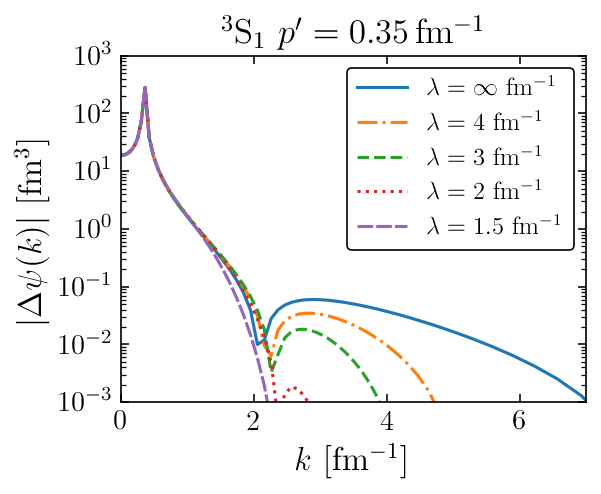

In [36]:
pp = 0.35
plot_delta_psi(kvnn, kmax, kmid, ntot, pp, x_limits=(0,7),
               y_limits=(1e-3,1e3))

### $\langle k_1 J_1 m_{J_d} L_1 S = 1 T_1 \lvert J_0^- \rvert k_2 J = 1 m_{J_d} L_2 S = 1 T = 0 \rangle$

In [37]:
q = 6

# 3S1 - 3S1 channel at m_J_d = 0
J_1, m_J_d, L_1, L_2, T_1 = 1, 0, 0, 0, 0

L_max = 2
# L_max = 3

Frobenius norm = 9.684351e-01


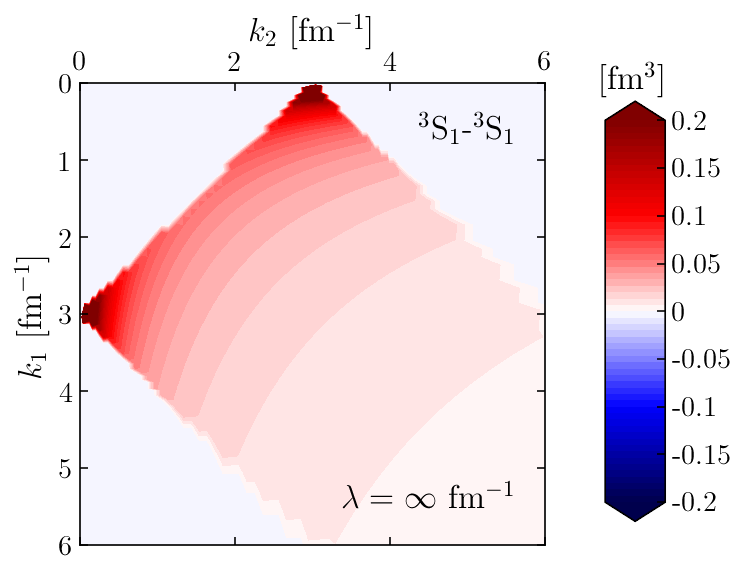

In [38]:
lamb = jnp.inf
plot_current_operator(kvnn, kmax, kmid, ntot, lamb, q, J_1, m_J_d, L_1, L_2,
                      T_1, L_max=L_max, cbar_limits=(-2e-1, 2e-1))

Frobenius norm = 9.795857e+00


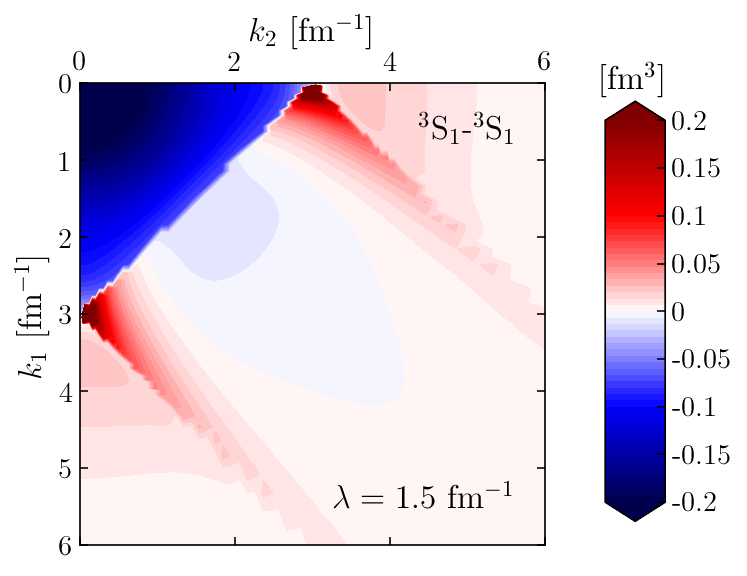

In [39]:
lamb = 1.5
plot_current_operator(kvnn, kmax, kmid, ntot, lamb, q, J_1, m_J_d, L_1, L_2,
                      T_1, L_max=L_max, cbar_limits=(-2e-1, 2e-1))

### $f_L(E',\theta',q)$

In [40]:
lamb = 1.5
# lamb = 3.0
# lamb = 15.0

# L_max = 1
L_max = 2
# L_max = 3

thetap_array = jnp.linspace(0.01, 179.9, 100)
thetap_xlim = (0, 180)

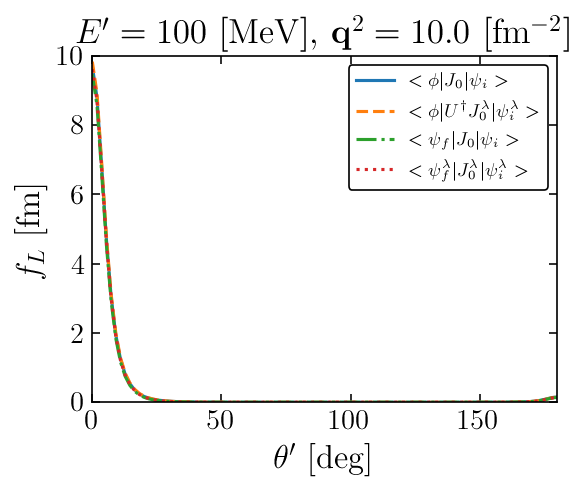

In [41]:
# ylim = (0, 8)
ylim = (0, 10)
Ep = 100
q = jnp.sqrt(10)

# # Write file?
# write_data_wrt_thetap(kvnn, kmax, kmid, ntot, lamb, Ep, thetap_array, q, L_max)

plot_fL_wrt_thetap(kvnn, lamb, Ep, q, L_max, x_limits=thetap_xlim,
                   y_limits=ylim)

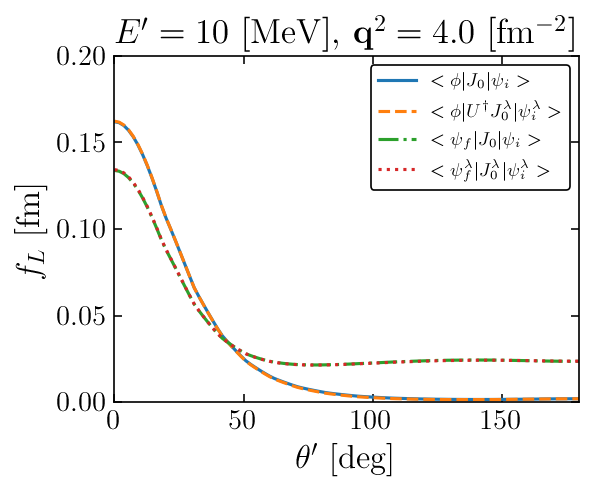

In [42]:
# ylim = (0, 0.15)
ylim = (0, 0.2)
Ep = 10
q = 2

# # Write file?
# write_data_wrt_thetap(kvnn, kmax, kmid, ntot, lamb, Ep, thetap_array, q, L_max)

plot_fL_wrt_thetap(kvnn, lamb, Ep, q, L_max, x_limits=thetap_xlim,
                   y_limits=ylim)

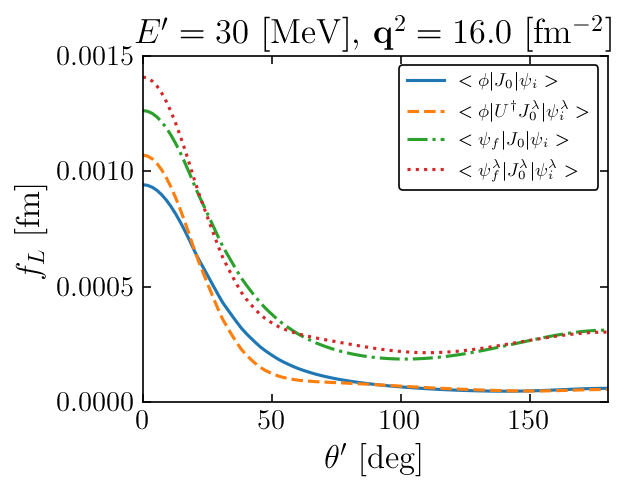

In [43]:
# ylim = (0, 0.0025)
ylim = (0, 0.0015)
Ep = 30
q = 4

# # Write file?
# write_data_wrt_thetap(kvnn, kmax, kmid, ntot, lamb, Ep, thetap_array, q, L_max)

plot_fL_wrt_thetap(kvnn, lamb, Ep, q, L_max, x_limits=thetap_xlim,
                   y_limits=ylim)

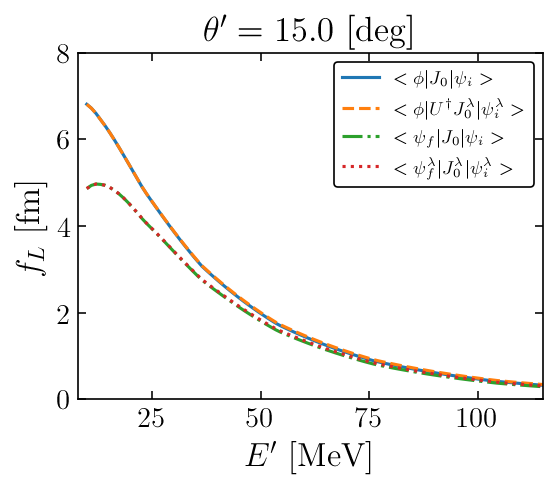

In [44]:
# Quasifree ridge where \omega = 0
Ep_array = np.linspace(10, 115, 100)
thetap = 15.0

# # Write file?
# write_data_wrt_Ep(kvnn, kmax, kmid, ntot, lamb, Ep_array, thetap, L_max)

# Ep_xlim = (10, 115)
Ep_xlim = (8, 115)
ylim = (0, 8)
plot_fL_quasifree_ridge(kvnn, lamb, thetap, L_max, x_limits=Ep_xlim,
                        y_limits=ylim)

### Showing that $\hat{U}^\dagger \hat{U} = \hat{I}$ where $U_{ij}=\delta_{ij}+\frac{2}{\pi} k_i k_j \sqrt{w_i w_j} \, \delta U(k_i, k_j)$

In [45]:
kvnn, kmax, kmid, ntot = 6, 25.0, 4.0, 120
lamb = 1.5
L_max = 2
delta_U = DeltaU(kvnn, kmax, kmid, ntot, lamb, L_max)

# Momenta and weights
k_array, k_weights = delta_U.k_array, delta_U.k_weights
k_grid, kp_grid = jnp.meshgrid(k_array, k_array, indexing='ij')
factor_array = jnp.sqrt(2 / jnp.pi * k_weights) * k_array
factor_i_grid, factor_j_grid = jnp.meshgrid(factor_array, factor_array,
                                            indexing='ij')

In [46]:
# 1S0 channel
J, L, Lp, S, T = 0, 0, 0, 0, 1

delta_U_matrix = delta_U(k_grid, kp_grid, J, L, Lp, S, T, hc=False)
delta_U_dagger_matrix = delta_U(k_grid, kp_grid, J, L, Lp, S, T, hc=True)

I_matrix = jnp.identity(ntot)

U_matrix = I_matrix + factor_i_grid * factor_j_grid * delta_U_matrix
U_dagger_matrix = (I_matrix
                   + factor_i_grid * factor_j_grid * delta_U_dagger_matrix)

print(U_dagger_matrix @ U_matrix - I_matrix)
print(jnp.amax(U_dagger_matrix @ U_matrix - I_matrix))

[[-6.66133815e-16 -1.58910525e-17  2.17745387e-17 ...  1.91363145e-18
   8.53948330e-19 -2.50220637e-19]
 [-1.58910519e-17 -1.22124533e-15  6.78322238e-16 ... -5.42281949e-17
   1.64543981e-17 -5.82899910e-17]
 [ 2.17745371e-17  6.78322241e-16  2.22044605e-15 ... -5.14336302e-17
  -1.29267102e-17 -3.69931854e-17]
 ...
 [ 1.91363145e-18 -5.42281948e-17 -5.14336302e-17 ...  1.55431223e-15
   9.27100061e-16  1.37012367e-17]
 [ 8.53948334e-19  1.64543981e-17 -1.29267101e-17 ...  9.77558304e-16
   1.55431223e-15 -5.36438472e-17]
 [-2.50220630e-19 -5.82899910e-17 -3.69931854e-17 ...  1.36654153e-19
  -4.00792646e-17  8.88178420e-16]]
2.220446049250313e-15


In [47]:
# 3S1-3D1 channel
J, S, T = 1, 1, 0

L, Lp = 0, 0
delta_U_00 = factor_i_grid * factor_j_grid * delta_U(k_grid, kp_grid, J, L, Lp,
                                                     S, T, hc=False)

L, Lp = 0, 2
delta_U_02 = factor_i_grid * factor_j_grid * delta_U(k_grid, kp_grid, J, L, Lp,
                                                     S, T, hc=False)

L, Lp = 2, 0
delta_U_20 = factor_i_grid * factor_j_grid * delta_U(k_grid, kp_grid, J, L, Lp,
                                                     S, T, hc=False)

L, Lp = 2, 2
delta_U_22 = factor_i_grid * factor_j_grid * delta_U(k_grid, kp_grid, J, L, Lp,
                                                     S, T, hc=False)

# Get full matrix
delta_U_matrix = jnp.vstack((jnp.hstack((delta_U_00, delta_U_02)),
                             jnp.hstack((delta_U_20, delta_U_22))))

I_matrix = jnp.identity(2 * ntot)

U_matrix = I_matrix + delta_U_matrix
U_dagger_matrix = U_matrix.T

print(U_dagger_matrix @ U_matrix - I_matrix)
print(jnp.amax(U_dagger_matrix @ U_matrix - I_matrix))

[[ 1.33226763e-15  7.31603367e-18  5.54378432e-18 ... -4.39941375e-18
  -2.70596111e-19  4.45042370e-18]
 [ 7.31603367e-18  2.44249065e-15 -7.76146083e-16 ... -1.20964005e-16
  -7.16193654e-19  2.38334379e-16]
 [ 5.54378432e-18 -7.76146083e-16 -4.44089210e-16 ... -4.35749482e-17
  -1.32690090e-16  1.32137193e-16]
 ...
 [-4.39941375e-18 -1.20964005e-16 -4.35749482e-17 ... -6.66133815e-16
   3.01841885e-16  9.54097912e-16]
 [-2.70596111e-19 -7.16193654e-19 -1.32690090e-16 ...  3.01841885e-16
   2.22044605e-16  8.10115863e-16]
 [ 4.45042370e-18  2.38334379e-16  1.32137193e-16 ...  9.54097912e-16
   8.10115863e-16 -2.22044605e-16]]
4.6629367034256575e-15


### Check that deuteron wave function is working correctly

In [49]:
# New momentum mesh
n = 501
gq = GaussQuadrature(n)
kmin, kmax = 0, 10
k_array, k_weights = gq(kmin, kmax)

In [50]:
# AV18
kvnn, kmax, kmid, ntot = 6, 25.0, 4.0, 120

# Initial wave function
dwf_init = DeuteronWaveFunction(kvnn, kmax, kmid, ntot, lamb=jnp.inf)
psi_0_init = dwf_init.compute_wf(k_array, 0)
psi_2_init = dwf_init.compute_wf(k_array, 2)
psi_squared_init = psi_0_init ** 2 + psi_2_init ** 2
norm_init = 2 / jnp.pi * jnp.sum(k_weights * k_array ** 2 * psi_squared_init)
print(f"Initial WF normalization = {norm_init:.5}")

# Evolved wave function
dwf_srg = DeuteronWaveFunction(kvnn, kmax, kmid, ntot, lamb=1.5)
psi_0_srg = dwf_srg.compute_wf(k_array, 0)
psi_2_srg = dwf_srg.compute_wf(k_array, 2)
psi_squared_srg = psi_0_srg ** 2 + psi_2_srg ** 2
norm_srg = 2 / jnp.pi * jnp.sum(k_weights * k_array ** 2 * psi_squared_srg)
print(f"Evolved WF normalization = {norm_srg:.5}")

Initial WF normalization = 1.009
Evolved WF normalization = 1.0093


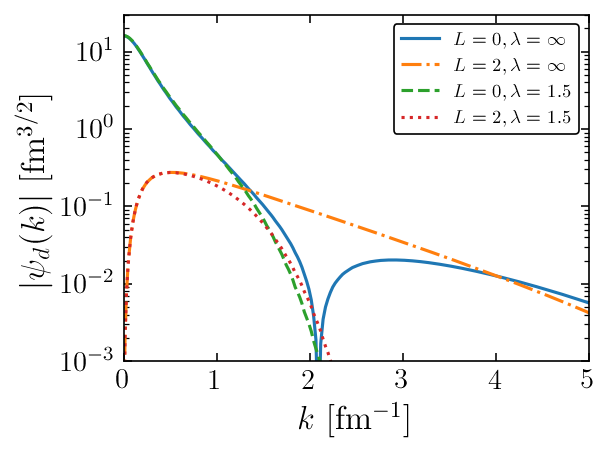

In [51]:
x_limits = (0, 5)
y_limits = (1e-3, 3e1)

plt.close('all')
f, ax = plt.subplots(figsize=(4, 3))
ax.semilogy(k_array, jnp.abs(psi_0_init), label=r"$L = 0, \lambda = \infty$",
            ls='solid')
ax.semilogy(k_array, jnp.abs(psi_2_init), label=r"$L = 2, \lambda = \infty$",
            ls='dashdot')
ax.semilogy(k_array, jnp.abs(psi_0_srg), label=r"$L = 0, \lambda = 1.5$",
            ls='dashed')
ax.semilogy(k_array, jnp.abs(psi_2_srg), label=r"$L = 2, \lambda = 1.5$",
            ls='dotted')
ax.set_xlim(x_limits)
ax.set_ylim(y_limits)
ax.legend(fontsize=9, loc='upper right')
ax.set_xlabel(r"$k$ [fm$^{-1}$]", fontsize=16)
ax.set_ylabel(r"$|\psi_d(k)|$ [fm$^{3/2}$]", fontsize=16);

### Frobenius norm of Hamiltonian

In [52]:
# Show Frobenius norm of Hamiltonian (with weights) stays the same
from scripts.potentials import Potential as PotentialPython
from numpy import linalg as la

potential = PotentialPython(6, '1S0', 25.0, 4.0, 120)
H_initial = potential.load_hamiltonian()
H_evolved = potential.load_hamiltonian('srg', 'T', 1.5)
# H_initial = potential.load_potential()
# H_evolved = potential.load_potential('srg', 'T', 1.5)

norm_initial = la.norm(H_initial)
norm_evolved = la.norm(H_evolved)
print(f"Initial Frobenius norm: {norm_initial}")
print(f"Evolved Frobenius norm: {norm_evolved}")

Initial Frobenius norm: 110824.46929097084
Evolved Frobenius norm: 110824.46928403078


### Check Frobenius norm of Hamiltonian using `DeltaU` class

In [53]:
kvnn, kmax, kmid, ntot = 6, 25.0, 4.0, 120

potential = PotentialPython(kvnn, '3S1', kmax, kmid, ntot)
H_initial = potential.load_hamiltonian()

# Compute SRG transformation 3S1-3D1 channel
delta_U = DeltaU(kvnn, kmax, kmid, ntot, 1.5, 2)

# Momenta and weights
k_array, k_weights = delta_U.k_array, delta_U.k_weights
k_grid, kp_grid = jnp.meshgrid(k_array, k_array, indexing='ij')
factor_array = jnp.sqrt(2 / jnp.pi * k_weights) * k_array
factor_i_grid, factor_j_grid = jnp.meshgrid(factor_array, factor_array,
                                            indexing='ij')

J, S, T = 1, 1, 0

L, Lp = 0, 0
delta_U_00 = factor_i_grid * factor_j_grid * delta_U(k_grid, kp_grid, J, L, Lp,
                                                     S, T, hc=False)

L, Lp = 0, 2
delta_U_02 = factor_i_grid * factor_j_grid * delta_U(k_grid, kp_grid, J, L, Lp,
                                                     S, T, hc=False)

L, Lp = 2, 0
delta_U_20 = factor_i_grid * factor_j_grid * delta_U(k_grid, kp_grid, J, L, Lp,
                                                     S, T, hc=False)

L, Lp = 2, 2
delta_U_22 = factor_i_grid * factor_j_grid * delta_U(k_grid, kp_grid, J, L, Lp,
                                                     S, T, hc=False)

# Get full matrix
delta_U_matrix = jnp.vstack((jnp.hstack((delta_U_00, delta_U_02)),
                             jnp.hstack((delta_U_20, delta_U_22))))

I_matrix = jnp.identity(2 * ntot)

U_matrix = I_matrix + delta_U_matrix
U_dagger_matrix = U_matrix.T

H_evolved = U_matrix @ H_initial @ U_dagger_matrix

norm_initial = la.norm(H_initial)
norm_evolved = la.norm(H_evolved)
print(f"Initial Frobenius norm: {norm_initial}")
print(f"Evolved Frobenius norm: {norm_evolved}")

Initial Frobenius norm: 156492.90320904073
Evolved Frobenius norm: 156492.90320904122


### Frobenius norm of current in $^{3}S_1$-$^{3}D_1$ channel using matrix multiplication

In [54]:
# Check 3S1-3S1: will need 3S1-3D1 SRG transformations and all four J_0^-

# Potential
kvnn, kmax, kmid, ntot = 6, 25.0, 4.0, 120

# Pick an arbitrary q value
q = 6

# Initialize current classes
current = Current(kvnn, kmax, kmid, ntot, jnp.inf, L_max=2)

# Compute SRG transformation 3S1-3D1 channel
delta_U = DeltaU(kvnn, kmax, kmid, ntot, 1.5, L_max)
J_1, m_J_d, T_1 = 1, 0, 0

# Momenta and weights
k_array, k_weights = delta_U.k_array, delta_U.k_weights
k_grid, kp_grid = jnp.meshgrid(k_array, k_array, indexing='ij')
factor_array = jnp.sqrt(2 / jnp.pi * k_weights) * k_array
factor_i_grid, factor_j_grid = jnp.meshgrid(factor_array, factor_array,
                                            indexing='ij')

# 3S1 - 3S1
L_1, L_2 = 0, 0
delta_U_00 = (factor_i_grid * factor_j_grid
              * delta_U(k_grid, kp_grid, J_1, L_1, L_2, 1, T_1, hc=False))

# 3S1 - 3D1
L_1, L_2 = 0, 2
delta_U_02 = (factor_i_grid * factor_j_grid
              * delta_U(k_grid, kp_grid, J_1, L_1, L_2, 1, T_1, hc=False))

# 3D1 - 3S1
L_1, L_2 = 2, 0
delta_U_20 = (factor_i_grid * factor_j_grid
              * delta_U(k_grid, kp_grid, J_1, L_1, L_2, 1, T_1, hc=False))

# 3D1 - 3D1
L_1, L_2 = 2, 2
delta_U_22 = (factor_i_grid * factor_j_grid
              * delta_U(k_grid, kp_grid, J_1, L_1, L_2, 1, T_1, hc=False))

# Full coupled-channel SRG transformation
delta_U_matrix = jnp.vstack((jnp.hstack((delta_U_00, delta_U_02)),
                             jnp.hstack((delta_U_20, delta_U_22))))

I_matrix = jnp.identity(2 * ntot)

U_matrix = I_matrix + delta_U_matrix
U_dagger_matrix = U_matrix.T

# Compute current [fm^3] for each sub-block
j0_00 = (factor_i_grid * factor_j_grid
         * current(k_array, k_array, q, J_1, m_J_d, 0, 0, T_1))
j0_02 = (factor_i_grid * factor_j_grid
         * current(k_array, k_array, q, J_1, m_J_d, 0, 2, T_1))
j0_20 = (factor_i_grid * factor_j_grid
         * current(k_array, k_array, q, J_1, m_J_d, 2, 0, T_1))
j0_22 = (factor_i_grid * factor_j_grid
         * current(k_array, k_array, q, J_1, m_J_d, 2, 2, T_1))
j0_initial = jnp.vstack((jnp.hstack((j0_00, j0_02)),
                             jnp.hstack((j0_20, j0_22))))

j0_evolved = U_matrix @ j0_initial @ U_dagger_matrix

# Print the norm of each
norm_initial = norm(j0_initial)
norm_evolved = norm(j0_evolved)
print(f"Initial Frobenius norm: {norm_initial}")
print(f"Evolved Frobenius norm: {norm_evolved}")

Initial Frobenius norm: 1.603469695984997
Evolved Frobenius norm: 1.6034696959849974


### Frobenius norm of current in $^{3}S_1$-$^{3}D_1$ channel using `Current` class

In [55]:
# Potential
kvnn, kmax, kmid, ntot = 6, 25.0, 4.0, 120

# Pick an arbitrary q value
q = 6

# Get momentum mesh
potential = Potential(kvnn, kmax, kmid, ntot)
k_array = potential.k_array
factor_array = jnp.sqrt(2 / jnp.pi * potential.k_weights) * k_array
factor_i_grid, factor_j_grid = jnp.meshgrid(factor_array, factor_array,
                                            indexing='ij')

J_1, m_J_d, T_1 = 1, 0, 0

for lamb in [jnp.inf, 1.5]:

    # Initialize current class
    current = Current(kvnn, kmax, kmid, ntot, lamb, L_max=L_max)
    
    # Compute current [fm^3]
    L_1, L_2 = 0, 0
    j0_00 = (factor_i_grid * factor_j_grid
             * current(k_array, k_array, q, J_1, m_J_d, L_1, L_2, T_1))
    L_1, L_2 = 0, 2
    j0_02 = (factor_i_grid * factor_j_grid
             * current(k_array, k_array, q, J_1, m_J_d, L_1, L_2, T_1))
    L_1, L_2 = 2, 0
    j0_20 = (factor_i_grid * factor_j_grid
             * current(k_array, k_array, q, J_1, m_J_d, L_1, L_2, T_1))
    L_1, L_2 = 2, 2
    j0_22 = (factor_i_grid * factor_j_grid
             * current(k_array, k_array, q, J_1, m_J_d, L_1, L_2, T_1))

    if lamb == jnp.inf:
        
        j0_3S1_initial = jnp.vstack((jnp.hstack((j0_00, j0_02)),
                                     jnp.hstack((j0_20, j0_22))))

        fnorm = jnp.linalg.norm(j0_3S1_initial)
        print(f"Initial Frobenius norm: {fnorm}")
        
    else:
        
        j0_3S1_evolved = jnp.vstack((jnp.hstack((j0_00, j0_02)),
                                     jnp.hstack((j0_20, j0_22))))
        fnorm = jnp.linalg.norm(j0_3S1_evolved)
        print(f"Evolved Frobenius norm: {fnorm}")

Initial Frobenius norm: 1.603469695984997
Evolved Frobenius norm: 12.913721205618728


Results for different $\lambda$ values:

| $\lambda$ (fm$^{-1}$) | Norm |
| --------------- | --------------- |
| $\infty$        | 1.603           |
| 6               | 1.592           |
| 3               | 1.934           |
| 2               | 4.867           |
| 1.5             | 12.914          |

In [56]:
# Current evolution with matrix multiplication (has integration weights here)
j0_diff_mm = j0_evolved - j0_initial
# j0_diff_mm = j0_evolved

print("Double-checking norm of evolved current using matrix multiplication:")
print(norm(j0_diff_mm + j0_initial), "\n")

# Current evolution with Current class (has integration weights here)
j0_diff_cc = j0_3S1_evolved - j0_3S1_initial
# j0_diff_cc = j0_3S1_evolved

print("Double-checking norm of evolved current using J_1+J_2+J_3+J_4:")
print(norm(j0_3S1_evolved), "\n")

print("Norm of U J_4 U^\dagger - J_4:")
print(norm(j0_diff_mm), "\n")

print("Norm of J_1+J_2+J_3:")
print(norm(j0_diff_cc))

Double-checking norm of evolved current using matrix multiplication:
1.6034696959849974 

Double-checking norm of evolved current using J_1+J_2+J_3+J_4:
12.913721205618728 

Norm of U J_4 U^\dagger - J_4:
0.5166761280151099 

Norm of J_1+J_2+J_3:
12.851274552164972


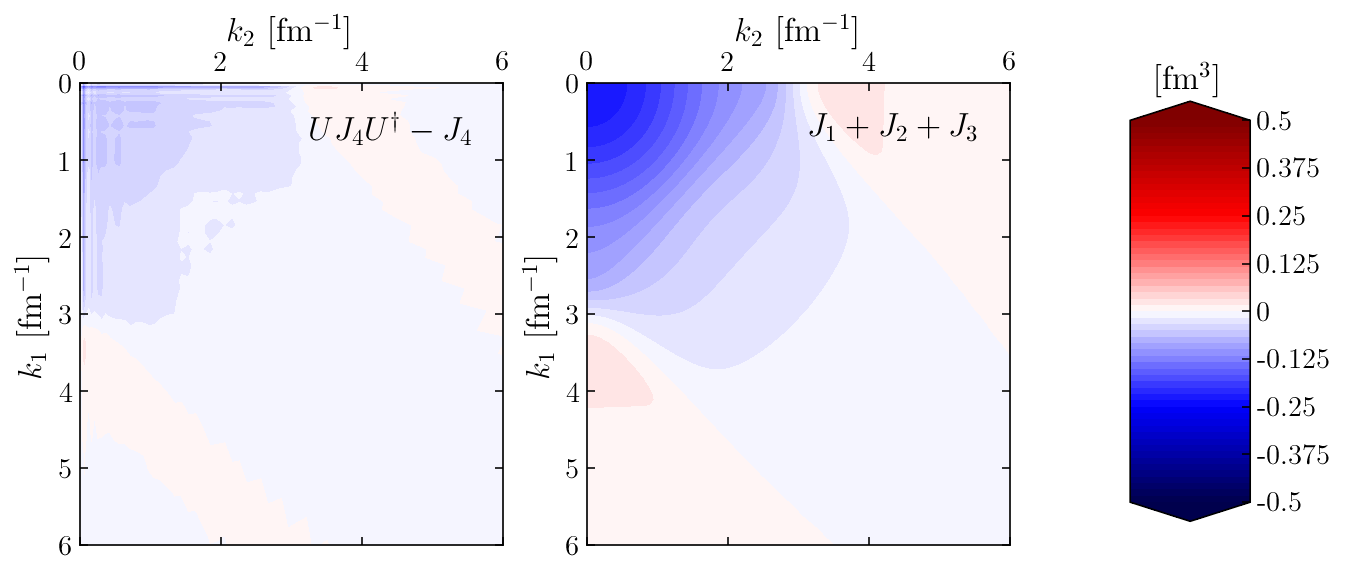

In [57]:
axes_limits = (0, 6)
cbar_limits = (-5e-1, 5e-1)
cbar_map = 'seismic'
levels_number = 61

plt.close('all')
f, axs = plt.subplots(figsize=(8,4), nrows=1, ncols=2)
    
levels = np.linspace(cbar_limits[0], cbar_limits[1], levels_number)

# 3S1-3S1
axs[0].contourf(
    k_array, k_array,
    j0_diff_mm[:ntot, :ntot] / (factor_i_grid * factor_j_grid), levels,
    cmap=cbar_map, extend='both'
)
c = axs[1].contourf(
    k_array, k_array,
    j0_diff_cc[:ntot, :ntot] / (factor_i_grid * factor_j_grid), levels,
    cmap=cbar_map, extend='both'
)
# # Other sub-block
# axs[0].contourf(
#     k_array, k_array,
#     j0_diff_mm[:ntot, :ntot] / (factor_i_grid * factor_j_grid), levels,
#     cmap=cbar_map, extend='both'
# )
# c = axs[1].contourf(
#     k_array, k_array,
#     j0_diff_cc[:ntot, :ntot] / (factor_i_grid * factor_j_grid), levels,
#     cmap=cbar_map, extend='both'
# )
    
axs[0].set_xlim(axes_limits)
axs[0].set_ylim(axes_limits)
axs[0].set_xlabel("$k_2$ [fm" + r"$^{-1}$" + "]", fontsize=16)
axs[0].set_ylabel("$k_1$ [fm" + r"$^{-1}$" + "]", fontsize=16)
axs[1].set_xlim(axes_limits)
axs[1].set_ylim(axes_limits)
axs[1].set_xlabel("$k_2$ [fm" + r"$^{-1}$" + "]", fontsize=16)
axs[1].set_ylabel("$k_1$ [fm" + r"$^{-1}$" + "]", fontsize=16)
    
axs[0].xaxis.set_label_position('top')
axs[0].tick_params(labeltop=True, labelbottom=False)
axs[0].invert_yaxis()
axs[1].xaxis.set_label_position('top')
axs[1].tick_params(labeltop=True, labelbottom=False)
axs[1].invert_yaxis()
    
# Colorbar location (left, bottom, width, height)
cbar_ax = f.add_axes((1.0, 0.15, 0.1, 0.7))
# Set colorbar ticks and tick labels
levels_ticks = np.linspace(cbar_limits[0], cbar_limits[1], 9)
levels_ticks_strings = label_ticks(levels_ticks)  # Make these strings
# Set colorbar
cbar = f.colorbar(c, cax=cbar_ax, ticks=levels_ticks)
cbar.ax.set_yticklabels(levels_ticks_strings)
cbar.ax.set_title(r"[fm$^3$]", fontsize=16, pad=15)
    
axs[0].add_artist(
    AnchoredText(r"$U J_4 U^\dagger - J_4$", loc='upper right',
                 prop=dict(size=16), frameon=False)
)
axs[1].add_artist(
    AnchoredText(r"$J_1+J_2+J_3$", loc='upper right',
                 prop=dict(size=16), frameon=False)
);

### Comparing $J_2(\lambda)$ and $J_3(\lambda)$

In [58]:
kvnn, kmax, kmid, ntot = 6, 25.0, 4.0, 120
lamb = 1.5
q = 6
J_1, m_J_d, L_1, L_2, T_1 = 1, 0, 0, 0, 0
current = Current(kvnn=kvnn, kmax=kmax, kmid=kmid, ntot=ntot, lamb=lamb)

j2 = current.vmap_testing_J2_J3(k_array, k_array, q, J_1, m_J_d, L_1, L_2, T_1,
                                arg=2)
j3 = current.vmap_testing_J2_J3(k_array, k_array, q, J_1, m_J_d, L_1, L_2, T_1,
                                arg=3)

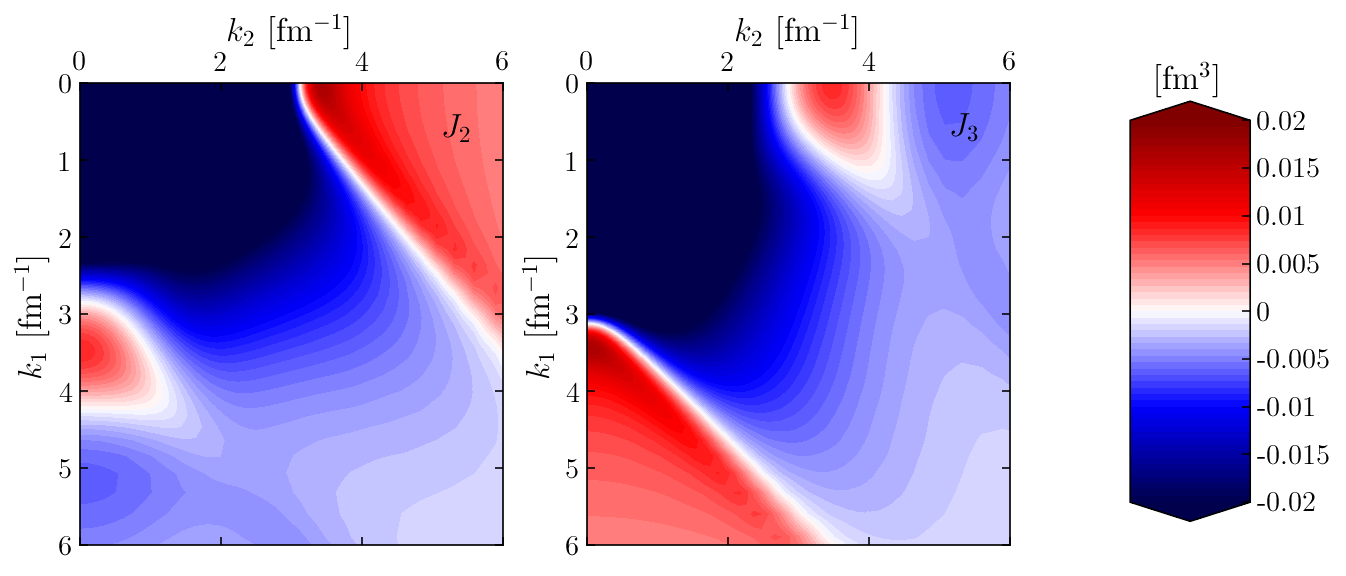

In [59]:
axes_limits = (0, 6)
cbar_limits = (-2e-2, 2e-2)
cbar_map = 'seismic'
levels_number = 61

plt.close('all')
f, axs = plt.subplots(figsize=(8,4), nrows=1, ncols=2)
    
levels = np.linspace(cbar_limits[0], cbar_limits[1], levels_number)

axs[0].contourf(k_array, k_array, j2, levels, cmap=cbar_map, extend='both')
c = axs[1].contourf(k_array, k_array, j3, levels, cmap=cbar_map, extend='both')
# c = axs[1].contourf(k_array, k_array, j3 + j2, levels, cmap=cbar_map, extend='both')
    
axs[0].set_xlim(axes_limits)
axs[0].set_ylim(axes_limits)
axs[0].set_xlabel("$k_2$ [fm" + r"$^{-1}$" + "]", fontsize=16)
axs[0].set_ylabel("$k_1$ [fm" + r"$^{-1}$" + "]", fontsize=16)
axs[1].set_xlim(axes_limits)
axs[1].set_ylim(axes_limits)
axs[1].set_xlabel("$k_2$ [fm" + r"$^{-1}$" + "]", fontsize=16)
axs[1].set_ylabel("$k_1$ [fm" + r"$^{-1}$" + "]", fontsize=16)
    
axs[0].xaxis.set_label_position('top')
axs[0].tick_params(labeltop=True, labelbottom=False)
axs[0].invert_yaxis()
axs[1].xaxis.set_label_position('top')
axs[1].tick_params(labeltop=True, labelbottom=False)
axs[1].invert_yaxis()
    
# Colorbar location (left, bottom, width, height)
cbar_ax = f.add_axes((1.0, 0.15, 0.1, 0.7))
# Set colorbar ticks and tick labels
levels_ticks = np.linspace(cbar_limits[0], cbar_limits[1], 9)
levels_ticks_strings = label_ticks(levels_ticks)  # Make these strings
# Set colorbar
cbar = f.colorbar(c, cax=cbar_ax, ticks=levels_ticks)
cbar.ax.set_yticklabels(levels_ticks_strings)
cbar.ax.set_title(r"[fm$^3$]", fontsize=16, pad=15)
    
axs[0].add_artist(
    AnchoredText(r"$J_2$", loc='upper right', prop=dict(size=16), frameon=False)
)
axs[1].add_artist(
    AnchoredText(r"$J_3$", loc='upper right', prop=dict(size=16), frameon=False)
);

### Frobenius norm of current in $^{3}P_1$ channel using matrix multiplication

In [60]:
# # Potential
# kvnn, kmax, kmid, ntot = 6, 25.0, 4.0, 120

# # Channel is 3P1
# J_1, m_J_d, L_1, L_2, T_1 = 1, 0, 1, 1, 1

# # Pick an arbitrary q value
# q = 6

# # Initialize current classes
# current = Current(kvnn, kmax, kmid, ntot, jnp.inf, L_max=2)

# # Compute SRG transformation in 1S0 channel
# delta_U = DeltaU(kvnn, kmax, kmid, ntot, 1.5, L_max)

# # Momenta and weights
# k_array, k_weights = delta_U.k_array, delta_U.k_weights
# k_grid, kp_grid = jnp.meshgrid(k_array, k_array, indexing='ij')
# factor_array = jnp.sqrt(2 / jnp.pi * k_weights) * k_array
# factor_i_grid, factor_j_grid = jnp.meshgrid(factor_array, factor_array,
#                                             indexing='ij')

# delta_U_matrix = delta_U(k_grid, kp_grid, J_1, L_1, L_2, 1, T_1, hc=False)
# delta_U_dagger_matrix = delta_U(k_grid, kp_grid, J_1, L_1, L_2, 1, T_1, hc=True)

# I_matrix = jnp.identity(ntot)

# # Unitless SRG transformations (weights attached)
# U_matrix = I_matrix + factor_i_grid * factor_j_grid * delta_U_matrix
# U_dagger_matrix = (I_matrix
#                    + factor_i_grid * factor_j_grid * delta_U_dagger_matrix)

# # Compute current [fm^3]
# j0_array = current(k_array, k_array, q, J_1, m_J_d, L_1, L_2, T_1)

# # Attach weights
# j0_initial = factor_i_grid * factor_j_grid * j0_array

# # Get initial and evolved current
# j0_evolved = U_matrix @ j0_initial @ U_dagger_matrix

# # Print the norm of each
# norm_initial = norm(j0_initial)
# norm_evolved = norm(j0_evolved)
# print(f"Initial Frobenius norm: {norm_initial}")
# print(f"Evolved Frobenius norm: {norm_evolved}")

### Frobenius norm of current in $^{3}P_1$ channel using `Current` class

In [61]:
# Try current plotting function again but with 3P1-3P1
q = 6

# 3P1 - 3P1 channel at m_J_d = 0
J_1, m_J_d, L_1, L_2, T_1 = 1, 0, 1, 1, 1

L_max = 2

kvnn, kmax, kmid, ntot = 6, 25.0, 4.0, 120

Frobenius norm = 1.023239e+00


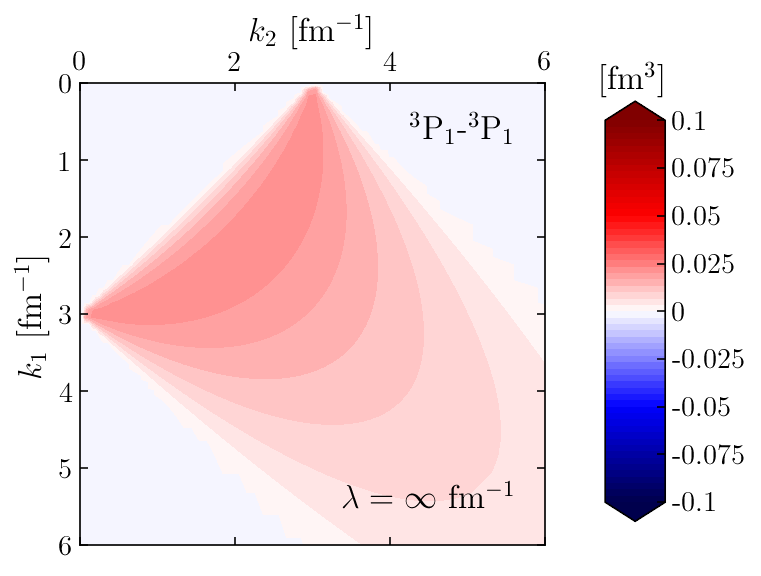

In [62]:
lamb = jnp.inf
k_array, j0_3P1_initial = plot_current_operator(
    kvnn, kmax, kmid, ntot, lamb, q, J_1, m_J_d, L_1, L_2, T_1, L_max=L_max,
    cbar_limits=(-1e-1, 1e-1), return_current=True
)

Frobenius norm = 1.482522e+01


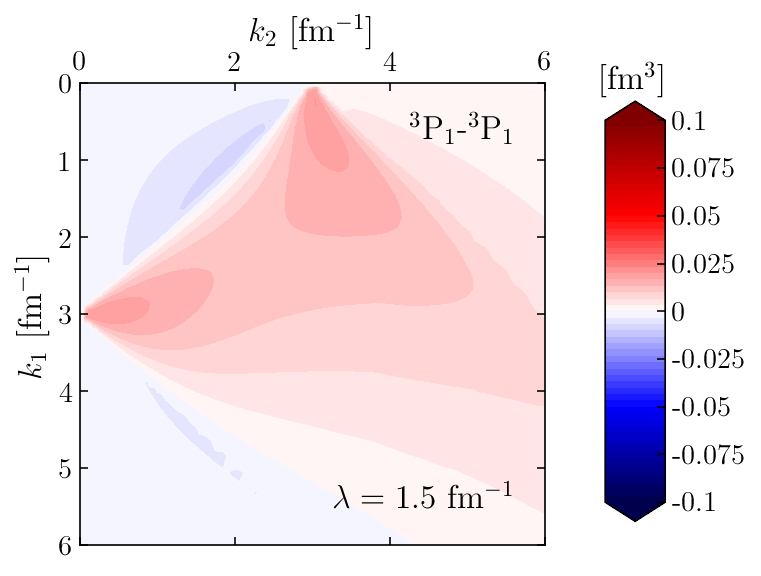

In [63]:
lamb = 1.5
_, j0_3P1_evolved = plot_current_operator(
    kvnn, kmax, kmid, ntot, lamb, q, J_1, m_J_d, L_1, L_2, T_1, L_max=L_max,
    cbar_limits=(-1e-1, 1e-1), return_current=True
)

### Plots of current evolution in $^{3}P_1$ channel

In [64]:
# # Current evolution with matrix multiplication
# j0_diff_mm = (j0_evolved - j0_initial) / (factor_i_grid * factor_j_grid)
# # j0_diff_mm = j0_evolved / (factor_i_grid * factor_j_grid)

# print("Double-checking norm of evolved current using matrix multiplication:")
# print(norm(j0_diff_mm * factor_i_grid * factor_j_grid + j0_initial))

# # Current evolution with Current class
# j0_diff_cc = j0_3P1_evolved - j0_3P1_initial

# print("Double-checking norm of evolved current using J_1+J_2+J_3+J_4:")
# print(norm(j0_3P1_evolved * factor_i_grid * factor_j_grid))

# print("Norm of J_1+J_2+J_3:")
# print(norm(j0_diff_cc * factor_i_grid * factor_j_grid))

# axes_limits = (0, 6)
# cbar_limits = (-2e-2, 2e-2)
# cbar_map = 'seismic'
# levels_number = 61

# plt.close('all')
# f, axs = plt.subplots(figsize=(8,4), nrows=1, ncols=2)
    
# levels = np.linspace(cbar_limits[0], cbar_limits[1], levels_number)

# axs[0].contourf(k_array, k_array, j0_diff_mm, levels, cmap=cbar_map,
#                 extend='both')
# c = axs[1].contourf(k_array, k_array, j0_diff_cc, levels, cmap=cbar_map,
#                     extend='both')
    
# axs[0].set_xlim(axes_limits)
# axs[0].set_ylim(axes_limits)
# axs[0].set_xlabel("$k_2$ [fm" + r"$^{-1}$" + "]", fontsize=16)
# axs[0].set_ylabel("$k_1$ [fm" + r"$^{-1}$" + "]", fontsize=16)
# axs[1].set_xlim(axes_limits)
# axs[1].set_ylim(axes_limits)
# axs[1].set_xlabel("$k_2$ [fm" + r"$^{-1}$" + "]", fontsize=16)
# axs[1].set_ylabel("$k_1$ [fm" + r"$^{-1}$" + "]", fontsize=16)
    
# axs[0].xaxis.set_label_position('top')
# axs[0].tick_params(labeltop=True, labelbottom=False)
# axs[0].invert_yaxis()
# axs[1].xaxis.set_label_position('top')
# axs[1].tick_params(labeltop=True, labelbottom=False)
# axs[1].invert_yaxis()
    
# # Colorbar location (left, bottom, width, height)
# cbar_ax = f.add_axes((1.0, 0.15, 0.1, 0.7))
# # Set colorbar ticks and tick labels
# levels_ticks = np.linspace(cbar_limits[0], cbar_limits[1], 9)
# levels_ticks_strings = label_ticks(levels_ticks)  # Make these strings
# # Set colorbar
# cbar = f.colorbar(c, cax=cbar_ax, ticks=levels_ticks)
# cbar.ax.set_yticklabels(levels_ticks_strings)
# cbar.ax.set_title(r"[fm$^3$]", fontsize=16, pad=15)
    
# axs[0].add_artist(
#     AnchoredText(r"$U J_4 U^\dagger - J_4$", loc='upper right',
#                  prop=dict(size=16), frameon=False)
# )
# axs[1].add_artist(
#     AnchoredText(r"$J_1+J_2+J_3$", loc='upper right',
#                  prop=dict(size=16), frameon=False)
# );

### Frobenius norm comparison in $^{3}S_{1}$-$^{3}D_{1}$ with coupling turned off

In [65]:
kvnn, kmax, kmid, ntot = 999, 25.0, 4.0, 120
# kvnn, kmax, kmid, ntot = 6, 25.0, 4.0, 120

# Pick an arbitrary q value
q = 6

In [66]:
# Initialize current classes
current = Current(kvnn, kmax, kmid, ntot, jnp.inf, L_max=2)

# Compute SRG transformation 3S1-3D1 channel
delta_U = DeltaU(kvnn, kmax, kmid, ntot, 1.5, L_max)
J_1, m_J_d, T_1 = 1, 0, 0

# Momenta and weights
k_array, k_weights = delta_U.k_array, delta_U.k_weights
k_grid, kp_grid = jnp.meshgrid(k_array, k_array, indexing='ij')
factor_array = jnp.sqrt(2 / jnp.pi * k_weights) * k_array
factor_i_grid, factor_j_grid = jnp.meshgrid(factor_array, factor_array,
                                            indexing='ij')

# 3S1 - 3S1
L_1, L_2 = 0, 0
delta_U_00 = (factor_i_grid * factor_j_grid
              * delta_U(k_grid, kp_grid, J_1, L_1, L_2, 1, T_1, hc=False))

# 3S1 - 3D1
L_1, L_2 = 0, 2
delta_U_02 = (factor_i_grid * factor_j_grid
              * delta_U(k_grid, kp_grid, J_1, L_1, L_2, 1, T_1, hc=False))

# 3D1 - 3S1
L_1, L_2 = 2, 0
delta_U_20 = (factor_i_grid * factor_j_grid
              * delta_U(k_grid, kp_grid, J_1, L_1, L_2, 1, T_1, hc=False))

# 3D1 - 3D1
L_1, L_2 = 2, 2
delta_U_22 = (factor_i_grid * factor_j_grid
              * delta_U(k_grid, kp_grid, J_1, L_1, L_2, 1, T_1, hc=False))

# Full coupled-channel SRG transformation
delta_U_matrix = jnp.vstack((jnp.hstack((delta_U_00, delta_U_02)),
                             jnp.hstack((delta_U_20, delta_U_22))))

I_matrix = jnp.identity(2 * ntot)

U_matrix = I_matrix + delta_U_matrix
U_dagger_matrix = U_matrix.T

# Compute current [fm^3] for each sub-block
j0_00 = (factor_i_grid * factor_j_grid
         * current(k_array, k_array, q, J_1, m_J_d, 0, 0, T_1))
j0_02 = (factor_i_grid * factor_j_grid
         * current(k_array, k_array, q, J_1, m_J_d, 0, 2, T_1))
j0_20 = (factor_i_grid * factor_j_grid
         * current(k_array, k_array, q, J_1, m_J_d, 2, 0, T_1))
j0_22 = (factor_i_grid * factor_j_grid
         * current(k_array, k_array, q, J_1, m_J_d, 2, 2, T_1))

# Current in coupled-channel matrix form with integration weights
j0_initial = jnp.vstack((jnp.hstack((j0_00, j0_02)),
                        jnp.hstack((j0_20, j0_22))))

j0_evolved = U_matrix @ j0_initial @ U_dagger_matrix

# Print the norm of each
norm_initial = norm(j0_initial)
norm_evolved = norm(j0_evolved)
print(f"Initial Frobenius norm: {norm_initial}")
print(f"Evolved Frobenius norm: {norm_evolved}")

Initial Frobenius norm: 1.603469695984997
Evolved Frobenius norm: 1.6034696959849974


In [67]:
# Get momentum mesh
potential = Potential(kvnn, kmax, kmid, ntot)
k_array, k_weights = potential.k_array, potential.k_weights
factor_array = jnp.sqrt(2 / jnp.pi * potential.k_weights) * k_array
factor_i_grid, factor_j_grid = jnp.meshgrid(factor_array, factor_array,
                                            indexing='ij')

J_1, m_J_d, T_1 = 1, 0, 0

for lamb in [jnp.inf, 1.5]:

    # Initialize current class
    current = Current(kvnn, kmax, kmid, ntot, lamb, L_max=L_max)
    
    # Compute current [fm^3]
    L_1, L_2 = 0, 0
    j0_00 = (factor_i_grid * factor_j_grid
             * current(k_array, k_array, q, J_1, m_J_d, L_1, L_2, T_1))
    L_1, L_2 = 0, 2
    j0_02 = (factor_i_grid * factor_j_grid
             * current(k_array, k_array, q, J_1, m_J_d, L_1, L_2, T_1))
    L_1, L_2 = 2, 0
    j0_20 = (factor_i_grid * factor_j_grid
             * current(k_array, k_array, q, J_1, m_J_d, L_1, L_2, T_1))
    L_1, L_2 = 2, 2
    j0_22 = (factor_i_grid * factor_j_grid
             * current(k_array, k_array, q, J_1, m_J_d, L_1, L_2, T_1))
    
    # Current in coupled-channel matrix form with integration weights
    if lamb == jnp.inf:

        j0_3S1_initial = jnp.vstack((jnp.hstack((j0_00, j0_02)),
                                     jnp.hstack((j0_20, j0_22))))
        fnorm = jnp.linalg.norm(j0_3S1_initial)
        print(f"Initial Frobenius norm: {fnorm}")
        
    else:
        
        j0_3S1_evolved = jnp.vstack((jnp.hstack((j0_00, j0_02)),
                                     jnp.hstack((j0_20, j0_22))))
        fnorm = jnp.linalg.norm(j0_3S1_evolved)
        print(f"Evolved Frobenius norm: {fnorm}")

Initial Frobenius norm: 1.603469695984997
Evolved Frobenius norm: 1.7353959309334348


In [68]:
# Current evolution with matrix multiplication (has integration weights here)
j0_diff_mm = j0_evolved - j0_initial
# j0_diff_mm = j0_evolved

print("Double-checking norm of evolved current using matrix multiplication:")
print(norm(j0_diff_mm + j0_initial), "\n")

# Current evolution with Current class (has integration weights here)
j0_diff_cc = j0_3S1_evolved - j0_3S1_initial
# j0_diff_cc = j0_3S1_evolved

print("Double-checking norm of evolved current using J_1+J_2+J_3+J_4:")
print(norm(j0_3S1_evolved), "\n")

print("Norm of U J_4 U^\dagger - J_4:")
print(norm(j0_diff_mm), "\n")

print("Norm of J_1+J_2+J_3:")
print(norm(j0_diff_cc))

Double-checking norm of evolved current using matrix multiplication:
1.6034696959849974 

Double-checking norm of evolved current using J_1+J_2+J_3+J_4:
1.7353959309334348 

Norm of U J_4 U^\dagger - J_4:
1.000156612681297 

Norm of J_1+J_2+J_3:
1.1884359850498618


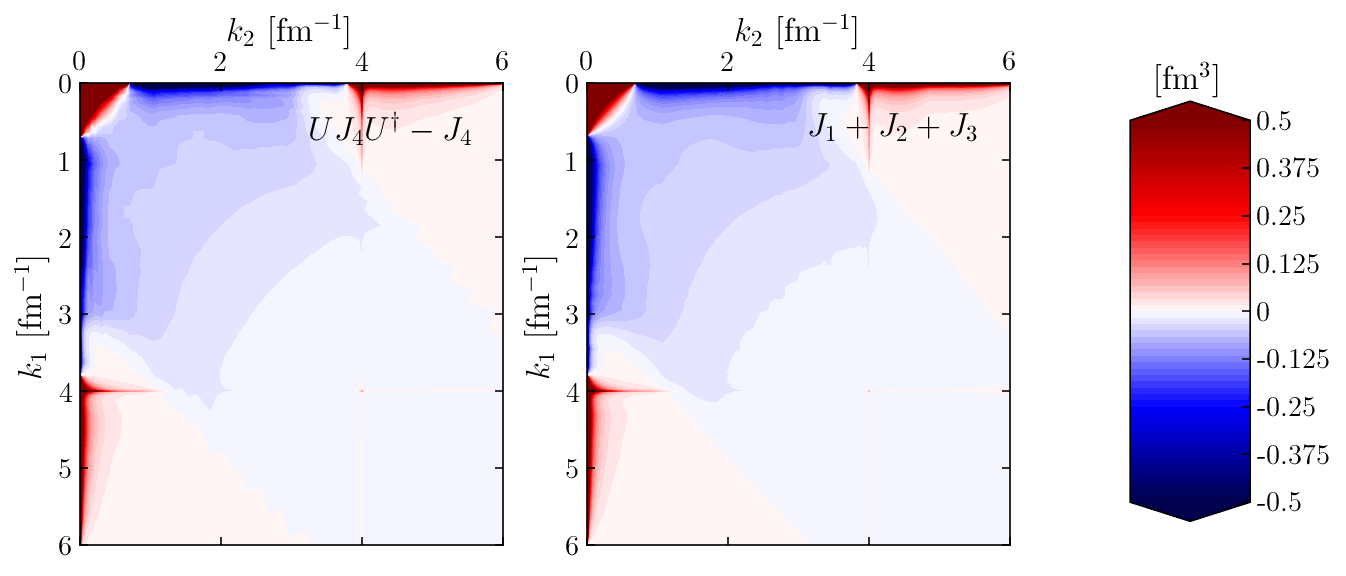

In [69]:
axes_limits = (0, 6)
cbar_limits = (-5e-1, 5e-1)
cbar_map = 'seismic'
levels_number = 61

plt.close('all')
f, axs = plt.subplots(figsize=(8,4), nrows=1, ncols=2)
    
levels = np.linspace(cbar_limits[0], cbar_limits[1], levels_number)

# 3S1-3S1
axs[0].contourf(
    k_array, k_array,
    j0_diff_mm[:ntot, :ntot] / (factor_i_grid * factor_j_grid), levels,
    cmap=cbar_map, extend='both'
)
c = axs[1].contourf(
    k_array, k_array,
    j0_diff_cc[:ntot, :ntot] / (factor_i_grid * factor_j_grid), levels,
    cmap=cbar_map, extend='both'
)
# # Other sub-block
# axs[0].contourf(
#     k_array, k_array,
#     j0_diff_mm[:ntot, :ntot] / (factor_i_grid * factor_j_grid), levels,
#     cmap=cbar_map, extend='both'
# )
# c = axs[1].contourf(
#     k_array, k_array,
#     j0_diff_cc[:ntot, :ntot] / (factor_i_grid * factor_j_grid), levels,
#     cmap=cbar_map, extend='both'
# )
    
axs[0].set_xlim(axes_limits)
axs[0].set_ylim(axes_limits)
axs[0].set_xlabel("$k_2$ [fm" + r"$^{-1}$" + "]", fontsize=16)
axs[0].set_ylabel("$k_1$ [fm" + r"$^{-1}$" + "]", fontsize=16)
axs[1].set_xlim(axes_limits)
axs[1].set_ylim(axes_limits)
axs[1].set_xlabel("$k_2$ [fm" + r"$^{-1}$" + "]", fontsize=16)
axs[1].set_ylabel("$k_1$ [fm" + r"$^{-1}$" + "]", fontsize=16)
    
axs[0].xaxis.set_label_position('top')
axs[0].tick_params(labeltop=True, labelbottom=False)
axs[0].invert_yaxis()
axs[1].xaxis.set_label_position('top')
axs[1].tick_params(labeltop=True, labelbottom=False)
axs[1].invert_yaxis()
    
# Colorbar location (left, bottom, width, height)
cbar_ax = f.add_axes((1.0, 0.15, 0.1, 0.7))
# Set colorbar ticks and tick labels
levels_ticks = np.linspace(cbar_limits[0], cbar_limits[1], 9)
levels_ticks_strings = label_ticks(levels_ticks)  # Make these strings
# Set colorbar
cbar = f.colorbar(c, cax=cbar_ax, ticks=levels_ticks)
cbar.ax.set_yticklabels(levels_ticks_strings)
cbar.ax.set_title(r"[fm$^3$]", fontsize=16, pad=15)
    
axs[0].add_artist(
    AnchoredText(r"$U J_4 U^\dagger - J_4$", loc='upper right',
                 prop=dict(size=16), frameon=False)
)
axs[1].add_artist(
    AnchoredText(r"$J_1+J_2+J_3$", loc='upper right',
                 prop=dict(size=16), frameon=False)
);

## Try matrix norm with different momentum mesh to test `interp2d` within `DeltaU` class

### Interpolate onto new mesh with `interp2d`

In [70]:
# New momentum mesh
# n = 501
# gq = GaussQuadrature(n)
# kmax_2 = 10
# k_array, k_weights = gq(0, kmax_2)

# A different mesh
from scripts.potentials import Potential as PotentialPython
kmax_2, n = 15.0, 120
pot_python = PotentialPython(6, '3S1', kmax_2, 3.0, n)
k_array, k_weights = pot_python.load_mesh()

In [71]:
# Check 3S1-3S1: will need 3S1-3D1 SRG transformations and all four J_0^-

# Potential
kvnn, kmax, kmid, ntot = 6, 25.0, 4.0, 120

# Pick an arbitrary q value
q = 6

# Initialize current classes
current = Current(kvnn, kmax, kmid, ntot, jnp.inf, L_max=2)

# Compute SRG transformation 3S1-3D1 channel
delta_U = DeltaU(kvnn, kmax, kmid, ntot, 1.5, L_max)
J_1, m_J_d, T_1 = 1, 0, 0

# Momenta and weights
k_grid, kp_grid = jnp.meshgrid(k_array, k_array, indexing='ij')
factor_array = jnp.sqrt(2 / jnp.pi * k_weights) * k_array
factor_i_grid, factor_j_grid = jnp.meshgrid(factor_array, factor_array,
                                            indexing='ij')

# 3S1 - 3S1
L_1, L_2 = 0, 0
delta_U_00 = (factor_i_grid * factor_j_grid
              * delta_U(k_grid, kp_grid, J_1, L_1, L_2, 1, T_1, hc=False))

# 3S1 - 3D1
L_1, L_2 = 0, 2
delta_U_02 = (factor_i_grid * factor_j_grid
              * delta_U(k_grid, kp_grid, J_1, L_1, L_2, 1, T_1, hc=False))

# 3D1 - 3S1
L_1, L_2 = 2, 0
delta_U_20 = (factor_i_grid * factor_j_grid
              * delta_U(k_grid, kp_grid, J_1, L_1, L_2, 1, T_1, hc=False))

# 3D1 - 3D1
L_1, L_2 = 2, 2
delta_U_22 = (factor_i_grid * factor_j_grid
              * delta_U(k_grid, kp_grid, J_1, L_1, L_2, 1, T_1, hc=False))

# Full coupled-channel SRG transformation
delta_U_matrix = jnp.vstack((jnp.hstack((delta_U_00, delta_U_02)),
                             jnp.hstack((delta_U_20, delta_U_22))))

I_matrix = jnp.identity(2 * n)

U_matrix = I_matrix + delta_U_matrix
U_dagger_matrix = U_matrix.T

# Compute current [fm^3] for each sub-block
j0_00 = (factor_i_grid * factor_j_grid
         * current(k_array, k_array, q, J_1, m_J_d, 0, 0, T_1))
j0_02 = (factor_i_grid * factor_j_grid
         * current(k_array, k_array, q, J_1, m_J_d, 0, 2, T_1))
j0_20 = (factor_i_grid * factor_j_grid
         * current(k_array, k_array, q, J_1, m_J_d, 2, 0, T_1))
j0_22 = (factor_i_grid * factor_j_grid
         * current(k_array, k_array, q, J_1, m_J_d, 2, 2, T_1))
j0_initial = jnp.vstack((jnp.hstack((j0_00, j0_02)),
                         jnp.hstack((j0_20, j0_22))))

j0_evolved = U_matrix @ j0_initial @ U_dagger_matrix

# Print the norm of each
norm_initial = norm(j0_initial)
norm_evolved = norm(j0_evolved)
print(f"Initial Frobenius norm: {norm_initial}")
print(f"Evolved Frobenius norm: {norm_evolved}")

Initial Frobenius norm: 1.1953937446893654
Evolved Frobenius norm: 1.1766071492528674


In [72]:
print(U_matrix @ U_dagger_matrix - I_matrix)

[[ 3.23614469e-11  6.98270473e-11 -2.55190929e-11 ...  2.76271522e-10
   2.18604421e-10  1.42619708e-10]
 [ 6.98270473e-11  1.16404442e-10 -2.03709016e-10 ...  2.21852232e-09
   1.75544115e-09  1.14526682e-09]
 [-2.55190929e-11 -2.03709016e-10 -6.24755359e-10 ...  6.82001613e-09
   5.39644177e-09  3.52068917e-09]
 ...
 [ 2.76271522e-10  2.21852232e-09  6.82001613e-09 ... -2.08826079e-03
  -1.64018950e-03 -1.06557057e-03]
 [ 2.18604421e-10  1.75544115e-09  5.39644177e-09 ... -1.64018950e-03
  -1.29554788e-03 -8.44385369e-04]
 [ 1.42619708e-10  1.14526682e-09  3.52068917e-09 ... -1.06557057e-03
  -8.44385369e-04 -5.51342222e-04]]


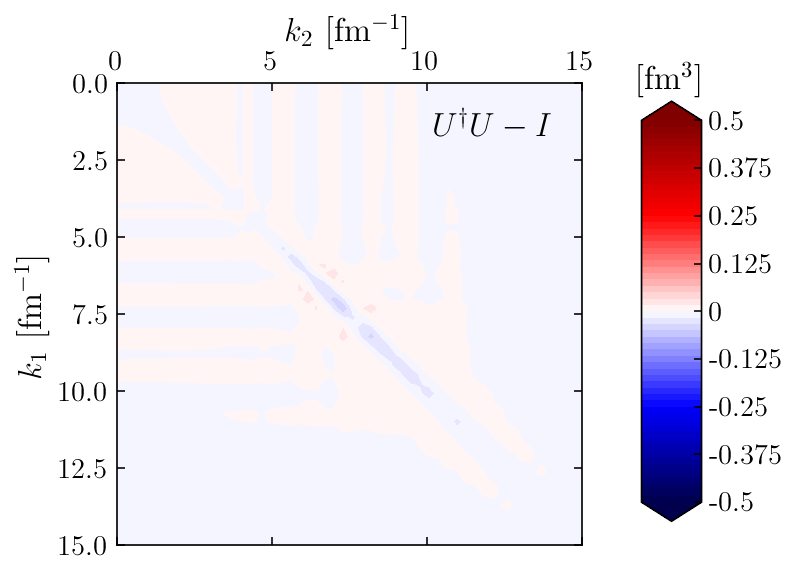

In [73]:
zero_matrix = U_dagger_matrix @ U_matrix - I_matrix

axes_limits = (0, kmax_2)
cbar_limits = (-5e-1, 5e-1)
cbar_map = 'seismic'
levels_number = 61

plt.close('all')
f, axs = plt.subplots(figsize=(4,4), nrows=1, ncols=1)
    
levels = np.linspace(cbar_limits[0], cbar_limits[1], levels_number)

# 3S1-3S1
c = axs.contourf(
    k_array, k_array, zero_matrix[:n, :n], levels, cmap=cbar_map,
    extend='both'
)
# c = axs.contourf(
#     k_array, k_array, zero_matrix[n:, n:], levels, cmap=cbar_map,
#     extend='both'
# )
# c = axs.contourf(
#     k_array, k_array, zero_matrix[:n, n:], levels, cmap=cbar_map,
#     extend='both'
# )
    
axs.set_xlim(axes_limits)
axs.set_ylim(axes_limits)
axs.set_xlabel("$k_2$ [fm" + r"$^{-1}$" + "]", fontsize=16)
axs.set_ylabel("$k_1$ [fm" + r"$^{-1}$" + "]", fontsize=16)
    
axs.xaxis.set_label_position('top')
axs.tick_params(labeltop=True, labelbottom=False)
axs.invert_yaxis()
    
# Colorbar location (left, bottom, width, height)
cbar_ax = f.add_axes((1.0, 0.15, 0.1, 0.7))
# Set colorbar ticks and tick labels
levels_ticks = np.linspace(cbar_limits[0], cbar_limits[1], 9)
levels_ticks_strings = label_ticks(levels_ticks)  # Make these strings
# Set colorbar
cbar = f.colorbar(c, cax=cbar_ax, ticks=levels_ticks)
cbar.ax.set_yticklabels(levels_ticks_strings)
cbar.ax.set_title(r"[fm$^3$]", fontsize=16, pad=15)
    
axs.add_artist(
    AnchoredText(r"$U^\dagger U - I$", loc='upper right',
                 prop=dict(size=16), frameon=False)
);

### Interpolate onto new mesh with `RectBivariateSpline`

In [74]:
# New mesh
# n = 501
# gq = GaussQuadrature(n)
# kmax_2 = 10
# k_array_2, k_weights_2 = gq(0, kmax_2)

# A different mesh
kmax_2, n = 15.0, 120
pot_python = PotentialPython(6, '3S1', kmax_2, 3.0, n)
k_array_2, k_weights_2 = pot_python.load_mesh()

In [75]:
from scipy.interpolate import RectBivariateSpline

kvnn, kmax, kmid, ntot = 6, 25.0, 4.0, 120

# Initialize current classes
current = Current(kvnn, kmax, kmid, ntot, jnp.inf, L_max=2)

# Compute SRG transformation 3S1-3D1 channel
delta_U = DeltaU(kvnn, kmax, kmid, ntot, 1.5, L_max)
J_1, m_J_d, T_1 = 1, 0, 0

# Momenta and weights
k_array, k_weights = delta_U.k_array, delta_U.k_weights
k_grid, kp_grid = jnp.meshgrid(k_array, k_array, indexing='ij')

factor_array = jnp.concatenate((jnp.sqrt(2 / jnp.pi * k_weights_2) * k_array_2,
                                jnp.sqrt(2 / jnp.pi * k_weights_2) * k_array_2))
factor_i_grid, factor_j_grid = jnp.meshgrid(factor_array, factor_array,
                                            indexing='ij')

# 3S1 - 3S1
L_1, L_2 = 0, 0
delta_U_00 = delta_U(k_grid, kp_grid, J_1, L_1, L_2, 1, T_1, hc=False)
delta_U_00_int = RectBivariateSpline(k_array, k_array, delta_U_00)(k_array_2,
                                                                   k_array_2)

# 3S1 - 3D1
L_1, L_2 = 0, 2
delta_U_02 = delta_U(k_grid, kp_grid, J_1, L_1, L_2, 1, T_1, hc=False)
delta_U_02_int = RectBivariateSpline(k_array, k_array, delta_U_02)(k_array_2,
                                                                   k_array_2)

# 3D1 - 3S1
L_1, L_2 = 2, 0
delta_U_20 = delta_U(k_grid, kp_grid, J_1, L_1, L_2, 1, T_1, hc=False)
delta_U_20_int = RectBivariateSpline(k_array, k_array, delta_U_20)(k_array_2,
                                                                   k_array_2)

# 3D1 - 3D1
L_1, L_2 = 2, 2
delta_U_22 = delta_U(k_grid, kp_grid, J_1, L_1, L_2, 1, T_1, hc=False)
delta_U_22_int = RectBivariateSpline(k_array, k_array, delta_U_22)(k_array_2,
                                                                   k_array_2)

# Full coupled-channel SRG transformation
delta_U_matrix = factor_i_grid * factor_j_grid * jnp.vstack(
    (jnp.hstack((delta_U_00_int, delta_U_02_int)),
     jnp.hstack((delta_U_20_int, delta_U_22_int)))
)

I_matrix = jnp.identity(2 * n)

U_matrix = I_matrix + delta_U_matrix
U_dagger_matrix = U_matrix.T

# Compute current [fm^3] for each sub-block
j0_00 = current(k_array, k_array, q, J_1, m_J_d, 0, 0, T_1)
j0_02 = current(k_array, k_array, q, J_1, m_J_d, 0, 2, T_1)
j0_20 = current(k_array, k_array, q, J_1, m_J_d, 2, 0, T_1)
j0_22 = current(k_array, k_array, q, J_1, m_J_d, 2, 2, T_1)

j0_00_int = RectBivariateSpline(k_array, k_array, j0_00)(k_array_2, k_array_2)
j0_02_int = RectBivariateSpline(k_array, k_array, j0_02)(k_array_2, k_array_2)
j0_20_int = RectBivariateSpline(k_array, k_array, j0_20)(k_array_2, k_array_2)
j0_22_int = RectBivariateSpline(k_array, k_array, j0_22)(k_array_2, k_array_2)

j0_initial = factor_i_grid * factor_j_grid * jnp.vstack(
    (jnp.hstack((j0_00_int, j0_02_int)), jnp.hstack((j0_20_int, j0_22_int)))
)

j0_evolved = U_matrix @ j0_initial @ U_dagger_matrix

# Print the norm of each
norm_initial = norm(j0_initial)
norm_evolved = norm(j0_evolved)
print(f"Initial Frobenius norm: {norm_initial}")
print(f"Evolved Frobenius norm: {norm_evolved}")

Initial Frobenius norm: 1.1675942859555108
Evolved Frobenius norm: 1.1567033624487175


In [76]:
print(U_dagger_matrix @ U_matrix - I_matrix)

[[ 1.78003390e-10  2.67922744e-10 -5.42044653e-10 ...  2.43012391e-09
   1.90800652e-09  1.23743401e-09]
 [ 2.67922744e-10  4.03021394e-10 -8.16902859e-10 ...  1.95137072e-08
   1.53211459e-08  9.93650046e-09]
 [-5.42044653e-10 -8.16902859e-10  1.64617431e-09 ...  5.99928999e-08
   4.71032819e-08  3.05487388e-08]
 ...
 [ 2.43012391e-09  1.95137072e-08  5.99928999e-08 ... -1.75103558e-03
  -1.38728161e-03 -9.03885889e-04]
 [ 1.90800652e-09  1.53211459e-08  4.71032819e-08 ... -1.38728161e-03
  -1.10682879e-03 -7.24104345e-04]
 [ 1.23743401e-09  9.93650046e-09  3.05487388e-08 ... -9.03885889e-04
  -7.24104345e-04 -4.74837085e-04]]


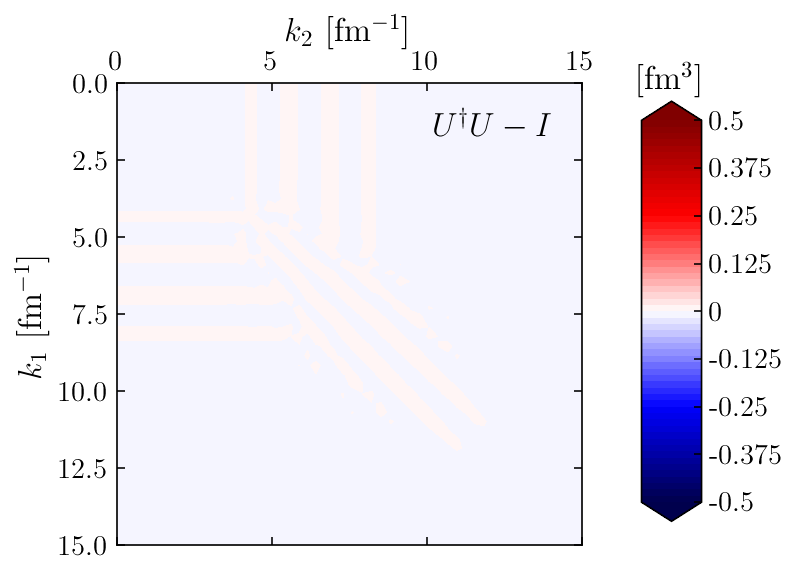

In [77]:
zero_matrix = U_dagger_matrix @ U_matrix - I_matrix

axes_limits = (0, kmax_2)
cbar_limits = (-5e-1, 5e-1)
cbar_map = 'seismic'
levels_number = 61

plt.close('all')
f, axs = plt.subplots(figsize=(4,4), nrows=1, ncols=1)
    
levels = np.linspace(cbar_limits[0], cbar_limits[1], levels_number)

# 3S1-3S1
c = axs.contourf(
    k_array_2, k_array_2, zero_matrix[:n, :n], levels, cmap=cbar_map,
    extend='both'
)
# c = axs.contourf(
#     k_array_2, k_array_2, zero_matrix[n:, n:], levels, cmap=cbar_map,
#     extend='both'
# )
# c = axs.contourf(
#     k_array_2, k_array_2, zero_matrix[:n, n:], levels, cmap=cbar_map,
#     extend='both'
# )
    
axs.set_xlim(axes_limits)
axs.set_ylim(axes_limits)
axs.set_xlabel("$k_2$ [fm" + r"$^{-1}$" + "]", fontsize=16)
axs.set_ylabel("$k_1$ [fm" + r"$^{-1}$" + "]", fontsize=16)
    
axs.xaxis.set_label_position('top')
axs.tick_params(labeltop=True, labelbottom=False)
axs.invert_yaxis()
    
# Colorbar location (left, bottom, width, height)
cbar_ax = f.add_axes((1.0, 0.15, 0.1, 0.7))
# Set colorbar ticks and tick labels
levels_ticks = np.linspace(cbar_limits[0], cbar_limits[1], 9)
levels_ticks_strings = label_ticks(levels_ticks)  # Make these strings
# Set colorbar
cbar = f.colorbar(c, cax=cbar_ax, ticks=levels_ticks)
cbar.ax.set_yticklabels(levels_ticks_strings)
cbar.ax.set_title(r"[fm$^3$]", fontsize=16, pad=15)
    
axs.add_artist(
    AnchoredText(r"$U^\dagger U - I$", loc='upper right', prop=dict(size=16),
                 frameon=False)
);